# 基于大语言模型的学生用户画像构建与个性化推荐方法

## 教程目标

本教程通过大作业一的教育数据集，**完整演示**两大核心主题：

### 主题一：用户画像构建
1. **传统方法**：基于规则（if-else）和统计阈值的标签构建
2. **大语言模型方法**：利用通义千问（Qwen）自动构建画像标签

### 主题二：个性化推荐
3. **协同过滤**：传统推荐算法基线
4. **大语言模型 + 向量检索**：基于画像的智能推荐方法

教程的核心问题：**传统方法有什么缺陷？大语言模型如何解决这些缺陷？**

---

## 数据集说明

数智教育数据集包含以下7个数据表：

| 数据表 | 内容 | 记录数 |
|--------|------|--------|
| 教师信息表 | 各班各学科教师 | ~3000条 |
| 学生信息表 | 在校学生的基本信息 | 1765人 |
| 考勤记录表 | 迟到、早退、校服等考勤事件 | 23630条 |
| 考勤类型表 | 考勤事件分类说明 | 15条 |
| 成绩记录表 | 多学科多学期考试成绩 | 471686条 |
| 考试类型表 | 考试类型说明 | 21条 |
| 消费记录表 | 校园一卡通消费流水 | 463904条 |

---

## 教程路线图

```
┌─────────────────────────────────────────────────────────────────┐
│                        第一部分：画像构建                        │
│  数据准备 → 传统画像构建方法及其缺陷 → 基于LLM方法 → 对比两种方法 │
├─────────────────────────────────────────────────────────────────┤
│                        第二部分：个性化推荐                      │
│  经典推荐算法-协同过滤 → 向量数据库 → LLM+画像推荐 → 对比验证 │
└─────────────────────────────────────────────────────────────────┘
```

## 教程目录

### 第一部分：用户画像构建（第1-7章）

| 章节 | 内容 | 核心教学点 |
|------|------|------------|
| 第1章 | 项目概述与环境准备 | 数据集说明、通义千问API配置 |
| 第2章 | 数据加载与预处理 | 7表关联、异常值清洗、多维特征聚合 |
| 第3章 | 传统方法构建画像 | 5维度规则标签（学业/学科/考勤/消费/综合） |
| 第4章 | 传统方法的缺陷 | 3个缺陷的代码实验证据（D1-D3） |
| 第5章 | LLM方法构建画像 | Prompt设计、通义千问API调用、结构化输出 |
| 第6章 | 对比分析与可视化 | 并排对比、雷达图、关键词分析、总结表 |
| 第7章 | 画像构建部分总结 | 核心结论、局限性、最佳实践、教育学理论扩展 |

### 第二部分：个性化推荐（第8-13章）

| 章节 | 内容 | 核心教学点 |
|------|------|------------|
| 第8章 | 协同过滤推荐算法 | 算法总体流程、User-based CF、Item-based CF |
| 第9章 | 协同过滤的缺陷 | 7个缺陷的代码实验证据（CF1-CF7） |
| 第10章 | 向量数据库基础 | 引入动机、Embedding、Chroma快速上手 |
| 第11章 | LLM+画像个性化推荐 | 资源库构建、语义检索、LLM推荐报告生成 |
| 第12章 | 推荐方法对比与总结 | 三阶段演进、三种方法对比、流程回顾 |
| 第13章 | 参考文献与扩展学习 | 9篇前沿论文（KDD/ACL/SIGIR等） |

---


## 1.1 环境准备

In [1]:
# Jupyter display兼容处理（在非Jupyter环境中自动降级为print）
try:
    get_ipython()
except NameError:
    def display(obj):
        print(obj)

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
import os
import json
import time
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
import chromadb

warnings.filterwarnings('ignore')

# 在非Jupyter环境中使用Agg后端，Jupyter中自动使用inline
try:
    get_ipython()
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    matplotlib.use('Agg')

# 直接加载本地SimHei字体文件
font_path = './SimHei.ttf'
if os.path.exists(font_path):
    font_prop = fm.FontProperties(fname=font_path)
    print(f'✓ 已加载本地字体文件: {font_path}')
else:
    font_prop = None
    print(f'⚠ 字体文件不存在: {font_path}')

# 设置图表风格
sns.set_style('whitegrid')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [10, 6]

print('环境准备完成！')


✓ 已加载本地字体文件: ./SimHei.ttf
环境准备完成！


## 1.2 配置LLM API

考虑到国内的Qwen大模型为每个学生提供了300元的免费额度，非常适合大家平时学习。
因此本教程使用通义千问（Qwen）作为大语言模型。通义千问提供了与OpenAI兼容的API接口，
因此我们可以使用`openai`库来调用。

> **注意**：运行前需要设置环境变量 `DASHSCOPE_API_KEY`，
> 或在下方代码中直接填入你的API Key。
> 
> 申请地址：https://dashscope.console.aliyun.com/

In [3]:
from openai import OpenAI

# 方式一：从环境变量读取（推荐）
API_KEY = os.environ.get('DASHSCOPE_API_KEY', '')

# 方式二：直接填入（仅本地调试使用，切勿提交到公开仓库）
# API_KEY = ''

if API_KEY:
    client = OpenAI(
        api_key=API_KEY,
        base_url='https://dashscope.aliyuncs.com/compatible-mode/v1'
    )
    LLM_MODEL = 'qwen3.7-max'
    print(f'通义千问API已配置完成，使用模型：{LLM_MODEL}')
else:
    client = None
    print('⚠️ 未检测到API Key，LLM相关章节将使用模拟输出。')
    print('请设置环境变量 DASHSCOPE_API_KEY 或在代码中填入API Key。')

通义千问API已配置完成，使用模型：qwen3.7-max


---
# 第2章：数据加载与预处理

在构建用户画像之前，我们需要先加载并清洗数据。本教程使用的数据集包含7个CSV文件，
涵盖学生基本信息、考勤、成绩、消费等多维度数据。

## 2.1 加载数据

In [4]:
# 数据路径配置
DATA_DIR = './数智教育数据集'

# 加载7个数据表
df_teacher = pd.read_csv(f'{DATA_DIR}/1_teacher.csv')
df_student = pd.read_csv(f'{DATA_DIR}/2_student_info.csv')
df_kaoqin = pd.read_csv(f'{DATA_DIR}/3_kaoqin.csv')
df_kaoqintype = pd.read_csv(f'{DATA_DIR}/4_kaoqintype.csv', encoding='gbk', sep='\t')
df_chengji = pd.read_csv(f'{DATA_DIR}/5_chengji.csv')
df_exam_type = pd.read_csv(f'{DATA_DIR}/6_exam_type.csv')
df_consumption = pd.read_csv(f'{DATA_DIR}/7_consumption.csv')

print('=== 数据加载完成 ===')
print(f'教师信息表:   {df_teacher.shape[0]:>8,} 条记录, {df_teacher.shape[1]} 个字段')
print(f'学生信息表:   {df_student.shape[0]:>8,} 条记录, {df_student.shape[1]} 个字段')
print(f'考勤记录表:   {df_kaoqin.shape[0]:>8,} 条记录, {df_kaoqin.shape[1]} 个字段')
print(f'考勤类型表:   {df_kaoqintype.shape[0]:>8,} 条记录, {df_kaoqintype.shape[1]} 个字段')
print(f'成绩记录表:   {df_chengji.shape[0]:>8,} 条记录, {df_chengji.shape[1]} 个字段')
print(f'考试类型表:   {df_exam_type.shape[0]:>8,} 条记录, {df_exam_type.shape[1]} 个字段')
print(f'消费记录表:   {df_consumption.shape[0]:>8,} 条记录, {df_consumption.shape[1]} 个字段')

=== 数据加载完成 ===
教师信息表:      3,088 条记录, 8 个字段
学生信息表:      1,765 条记录, 14 个字段
考勤记录表:     23,630 条记录, 10 个字段
考勤类型表:         15 条记录, 4 个字段
成绩记录表:    471,686 条记录, 13 个字段
考试类型表:         21 条记录, 2 个字段
消费记录表:    463,904 条记录, 5 个字段


## 2.2 数据预览

In [5]:
print('--- 学生信息表 ---')
display(df_student.head(3))

print('\n--- 考勤记录表 ---')
display(df_kaoqin.head(3))

print('\n--- 成绩记录表 ---')
display(df_chengji.head(3))

print('\n--- 消费记录表 ---')
display(df_consumption.head(3))

--- 学生信息表 ---


,bf_StudentID,bf_Name,bf_sex,bf_nation,bf_BornDate,cla_Name,bf_NativePlace,Bf_ResidenceType,bf_policy,cla_id,cla_term,bf_zhusu,bf_leaveSchool,bf_qinshihao
0,14454,陈某某,女,汉族,2001.0,白-高二(01),宁波,城镇,共青团员,901,2018-2019-1,NaN,NaN,NaN
1,14479,曹某某,男,汉族,NaN,白-高二(01),NaN,城镇,共青团员,901,2018-2019-1,1.0,NaN,315.0
2,14486,金某某,男,汉族,NaN,白-高二(01),NaN,城镇,共青团员,901,2018-2019-1,1.0,NaN,321.0



--- 考勤记录表 ---


,kaoqing_id,qj_term,DataDateTime,ControllerID,controler_name,control_task_order_id,bf_studentID,bf_Name,cla_Name,bf_classid
0,134324,2017-2018-1,2018/1/27 12:21:32,99003,早退[移动考勤机],9900300,13893,陈某某,高三(11),872
1,134346,2017-2018-1,2018/1/27 12:41:44,99003,早退[移动考勤机],9900300,13667,宋某某,高三(11),872
2,134367,2017-2018-1,2018/1/27 14:13:37,99003,早退[移动考勤机],9900300,13925,李某某,高三(09),879



--- 成绩记录表 ---


,mes_TestID,exam_number,exam_numname,mes_sub_id,mes_sub_name,exam_term,exam_type,exam_sdate,mes_StudentID,mes_Score,mes_Z_Score,mes_T_Score,mes_dengdi
0,136424,282,2017年9月宁波市“十校联考”,17.0,政治,2017-2018-1,7,2017/9/20 00:00:00,13539,-2.0,NaN,NaN,NaN
1,136424,282,2017年9月宁波市“十校联考”,17.0,政治,2017-2018-1,7,2017/9/20 00:00:00,13548,90.0,1.074511,88.59608,0.137615
2,136424,282,2017年9月宁波市“十校联考”,17.0,政治,2017-2018-1,7,2017/9/20 00:00:00,13551,91.0,1.194145,89.55315,0.091743



--- 消费记录表 ---


,DealTime,MonDeal,bf_StudentID,AccName,PerSex
0,2018/7/1 06:32:51,-4.5,14877,张某某,女
1,2018/7/1 11:43:05,-11.0,14917,高某某,男
2,2018/7/1 14:21:42,-9.2,14921,胡某某,男


## 2.3 数据清洗

根据数据说明文档，我们需要处理以下问题：

1. **成绩异常值**：`mes_Score` 中 -1=作弊, -2=缺考, -3=免考，需要标记为NaN
2. **消费金额**：`MonDeal` 为负数（表示扣款），取绝对值
3. **缺失值处理**：部分字段存在缺失

In [6]:
# ===== 成绩数据清洗 =====
# 将异常成绩标记为NaN（-1作弊, -2缺考, -3免考）
df_chengji['mes_Score'] = pd.to_numeric(df_chengji['mes_Score'], errors='coerce')
df_chengji.loc[df_chengji['mes_Score'] < 0, 'mes_Score'] = np.nan

# 转换Z-score和T-score为数值类型
df_chengji['mes_Z_Score'] = pd.to_numeric(df_chengji['mes_Z_Score'], errors='coerce')
df_chengji['mes_T_Score'] = pd.to_numeric(df_chengji['mes_T_Score'], errors='coerce')

print(f'成绩表清洗后有效成绩记录数: {df_chengji["mes_Score"].notna().sum():,}')
print(f'异常成绩（已标记为NaN）: {df_chengji["mes_Score"].isna().sum():,} 条')

# ===== 消费数据清洗 =====
# 消费金额为负数（扣款），取绝对值
df_consumption['MonDeal'] = df_consumption['MonDeal'].abs()
df_consumption['DealTime'] = pd.to_datetime(df_consumption['DealTime'])

print(f'\n消费表清洗后记录数: {len(df_consumption):,}')
print(f'日均消费金额: {df_consumption["MonDeal"].mean():.2f} 元')

# ===== 考勤数据清洗 =====
df_kaoqin['DataDateTime'] = pd.to_datetime(df_kaoqin['DataDateTime'], errors='coerce')

print(f'\n考勤表清洗后记录数: {len(df_kaoqin):,}')

成绩表清洗后有效成绩记录数: 422,705
异常成绩（已标记为NaN）: 48,981 条

消费表清洗后记录数: 463,904
日均消费金额: 8.37 元

考勤表清洗后记录数: 23,630


## 2.4 构建学生多维特征

将多个数据表以学生ID为主键进行聚合，为每个学生构建多维特征向量。

In [7]:
# ===== 学业特征 =====
# 计算每个学生的总体均分、各科均分、Z-score均值
student_score = df_chengji.groupby('mes_StudentID').agg(
    avg_score=('mes_Score', 'mean'),
    std_score=('mes_Score', 'std'),
    avg_zscore=('mes_Z_Score', 'mean'),
    exam_count=('mes_Score', 'count'),
    max_score=('mes_Score', 'max'),
    min_score=('mes_Score', 'min')
).reset_index()
student_score.rename(columns={'mes_StudentID': 'bf_StudentID'}, inplace=True)

# 计算各学科均分
subject_scores = df_chengji.pivot_table(
    index='mes_StudentID', columns='mes_sub_name',
    values='mes_Score', aggfunc='mean'
).reset_index()
subject_scores.rename(columns={'mes_StudentID': 'bf_StudentID'}, inplace=True)

print(f'学业特征: {student_score.shape[0]} 名学生, {student_score.shape[1]} 个特征')
print(f'学科特征: {subject_scores.shape[0]} 名学生, {subject_scores.shape[1]-1} 个学科')

# ===== 考勤特征 =====
student_kaoqin = df_kaoqin.groupby('bf_studentID').agg(
    kaoqin_total=('kaoqing_id', 'count'),
    kaoqin_types=('controler_name', lambda x: x.value_counts().to_dict())
).reset_index()
student_kaoqin.rename(columns={'bf_studentID': 'bf_StudentID'}, inplace=True)

# 按考勤类型拆分计数
kaoqin_pivot = df_kaoqin.groupby(['bf_studentID', 'controler_name']).size().unstack(fill_value=0).reset_index()
kaoqin_pivot.rename(columns={'bf_studentID': 'bf_StudentID'}, inplace=True)

print(f'考勤特征: {student_kaoqin.shape[0]} 名学生有考勤记录')

# ===== 消费特征 =====
student_consumption = df_consumption.groupby('bf_StudentID').agg(
    total_spending=('MonDeal', 'sum'),
    avg_daily_spending=('MonDeal', 'mean'),
    spending_count=('MonDeal', 'count'),
    std_spending=('MonDeal', 'std'),
    max_single=('MonDeal', 'max')
).reset_index()

# 计算消费天数
consumption_days = df_consumption.groupby('bf_StudentID')['DealTime'].apply(
    lambda x: x.dt.date.nunique()
).reset_index()
consumption_days.columns = ['bf_StudentID', 'consumption_days']
student_consumption = student_consumption.merge(consumption_days, on='bf_StudentID')
student_consumption['daily_avg'] = student_consumption['total_spending'] / student_consumption['consumption_days']

print(f'消费特征: {student_consumption.shape[0]} 名学生有消费记录')

学业特征: 3869 名学生, 7 个特征
学科特征: 3862 名学生, 16 个学科
考勤特征: 3058 名学生有考勤记录
消费特征: 1730 名学生有消费记录


In [8]:
# ===== 合并所有特征 =====
df_profile = df_student[['bf_StudentID', 'bf_Name', 'bf_sex', 'cla_Name', 'cla_id',
                          'bf_nation', 'bf_NativePlace', 'Bf_ResidenceType', 'bf_zhusu']].copy()

# 合并学业特征
df_profile = df_profile.merge(student_score, on='bf_StudentID', how='left')

# 合并主要学科成绩
main_subjects = ['语文', '数学', '英语', '物理', '化学', '生物', '政治', '历史', '地理']
for subj in main_subjects:
    if subj in subject_scores.columns:
        df_profile = df_profile.merge(
            subject_scores[['bf_StudentID', subj]].rename(columns={subj: f'subj_{subj}'}),
            on='bf_StudentID', how='left'
        )

# 合并考勤特征
df_profile = df_profile.merge(student_kaoqin[['bf_StudentID', 'kaoqin_total']], on='bf_StudentID', how='left')
df_profile['kaoqin_total'] = df_profile['kaoqin_total'].fillna(0).astype(int)

# 合并消费特征
df_profile = df_profile.merge(
    student_consumption[['bf_StudentID', 'total_spending', 'daily_avg', 'consumption_days', 'spending_count']],
    on='bf_StudentID', how='left'
)

print(f'=== 学生画像基础数据表 ===')
print(f'总学生数: {len(df_profile):,}')
print(f'特征维度: {df_profile.shape[1]} 个字段')
print(f'\n各维度数据覆盖率:')
print(f'  学业数据: {df_profile["avg_score"].notna().sum():,} 人 ({df_profile["avg_score"].notna().mean()*100:.1f}%)')
print(f'  考勤数据: {(df_profile["kaoqin_total"]>0).sum():,} 人 ({(df_profile["kaoqin_total"]>0).mean()*100:.1f}%)')
print(f'  消费数据: {df_profile["daily_avg"].notna().sum():,} 人 ({df_profile["daily_avg"].notna().mean()*100:.1f}%)')

=== 学生画像基础数据表 ===
总学生数: 1,765
特征维度: 29 个字段

各维度数据覆盖率:
  学业数据: 1,571 人 (89.0%)
  考勤数据: 1,007 人 (57.1%)
  消费数据: 1,730 人 (98.0%)


In [9]:
print('\n--- 合并后的学生画像基础数据预览 ---')
display(df_profile.head(5))


--- 合并后的学生画像基础数据预览 ---


,bf_StudentID,bf_Name,bf_sex,cla_Name,cla_id,bf_nation,bf_NativePlace,Bf_ResidenceType,bf_zhusu,avg_score,...,subj_化学,subj_生物,subj_政治,subj_历史,subj_地理,kaoqin_total,total_spending,daily_avg,consumption_days,spending_count
0,14454,陈某某,女,白-高二(01),901,汉族,宁波,城镇,NaN,57.777206,...,57.571429,60.582353,50.307692,51.900000,49.571429,2,1160.70,15.685135,74.0,115.0
1,14479,曹某某,男,白-高二(01),901,汉族,NaN,城镇,1.0,60.116176,...,67.142857,62.452941,48.500000,52.142857,51.857143,56,2446.22,26.023617,94.0,267.0
2,14486,金某某,男,白-高二(01),901,汉族,NaN,城镇,1.0,61.625547,...,65.142857,61.131250,46.769231,51.428571,52.000000,1,3414.20,31.038182,110.0,422.0
3,14549,张某某,女,白-高二(07),907,汉族,浙江平湖,城镇,NaN,46.130000,...,36.800000,39.850000,39.642857,43.000000,44.583333,0,1085.00,11.923077,91.0,121.0
4,14550,张某某,女,白-高二(04),904,汉族,浙江宁波,城镇,NaN,55.720635,...,54.083333,49.214286,46.857143,44.750000,51.375000,7,1908.95,21.210556,90.0,197.0


---
# 第3章：传统方法 — 基于规则的用户画像构建

传统用户画像构建的核心思路是：**基于统计指标和人工设定的规则（if-else），将连续数据映射为离散标签。**

本章将从5个维度构建学生画像标签：

| 维度 | 标签 | 构建方法 |
|------|------|----------|
| 学业表现 | 学霸/优良/中等/学困 | 均分阈值分档 |
| 学科特征 | 偏理/偏文/均衡 | 文理均分差值 |
| 学习态度 | 全勤标兵/正常/考勤预警 | 考勤异常次数 |
| 消费行为 | 高消费/适中/节俭 | 日均消费分位数 |
| 综合画像 | 标签拼接 | 多标签组合 |

## 3.1 维度一：学业表现标签

**传统做法**：根据学生所有考试的平均分，用固定阈值划分为4个等级。

```python
if avg_score >= 90:    → "学霸"
elif avg_score >= 75:  → "优良"
elif avg_score >= 60:  → "中等"
else:                  → "学困"
```

> **思考**：这些阈值是怎么来的？——通常是人为设定的"经验值"。

=== 学业表现标签分布（阈值方案A: 90/75/60）===
  学困:  1210 人 (68.6%)
  中等:   360 人 (20.4%)
  未知:   194 人 (11.0%)
  优良:     1 人 (0.1%)


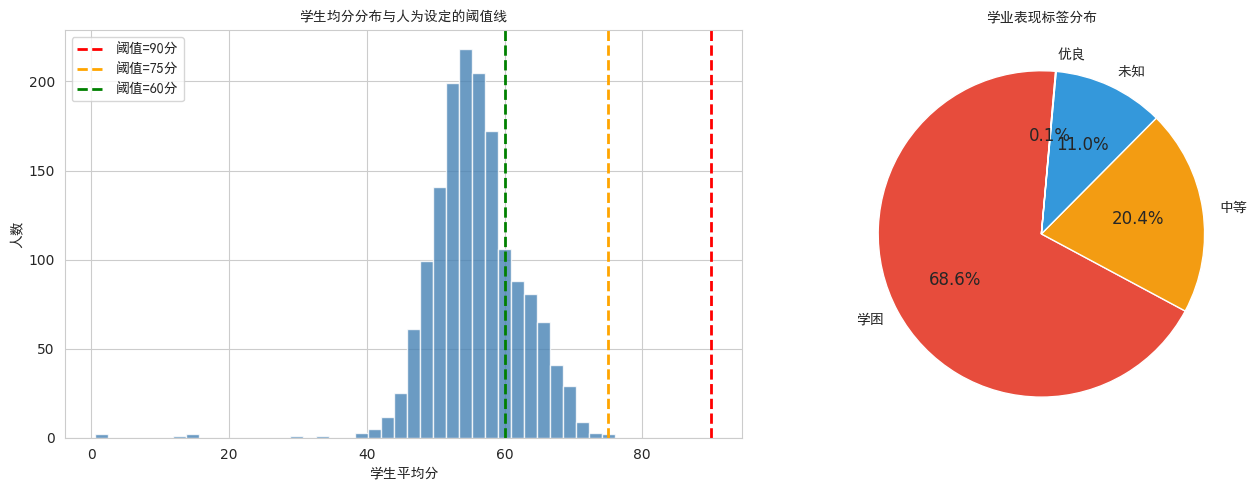

In [10]:
def assign_academic_label_v1(avg_score):
    """传统方法：基于固定阈值的学业表现标签（方案A）"""
    if pd.isna(avg_score):
        return '未知'
    if avg_score >= 90:
        return '学霸'
    elif avg_score >= 75:
        return '优良'
    elif avg_score >= 60:
        return '中等'
    else:
        return '学困'

df_profile['academic_label_v1'] = df_profile['avg_score'].apply(assign_academic_label_v1)

# 统计各标签分布
academic_dist = df_profile['academic_label_v1'].value_counts()
print('=== 学业表现标签分布（阈值方案A: 90/75/60）===')
for label, count in academic_dist.items():
    pct = count / len(df_profile) * 100
    print(f'  {label}: {count:>5} 人 ({pct:.1f}%)')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：均分分布 + 阈值线
ax = axes[0]
scores = df_profile['avg_score'].dropna()
ax.hist(scores, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
for threshold, color, label in [(90, 'red', '90分'), (75, 'orange', '75分'), (60, 'green', '60分')]:
    ax.axvline(threshold, color=color, linestyle='--', linewidth=2, label=f'阈值={label}')
ax.set_xlabel('学生平均分', fontproperties=font_prop)
ax.set_ylabel('人数', fontproperties=font_prop)
ax.set_title('学生均分分布与人为设定的阈值线', fontproperties=font_prop)
ax.legend(prop=font_prop)

# 右图：标签分布饼图
ax = axes[1]
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
wedges, texts, autotexts = ax.pie(academic_dist.values, labels=academic_dist.index, 
                                   autopct='%1.1f%%', colors=colors[:len(academic_dist)],
                                   startangle=85, textprops={'fontsize': 12})
# Set font for pie labels
for text in texts:
    text.set_fontproperties(font_prop)
ax.set_ylabel('')
ax.set_title('学业表现标签分布', fontproperties=font_prop)

plt.tight_layout()
plt.savefig('./output/3_1_academic_distribution.png', bbox_inches='tight')
plt.show()


**图表解读**：学生均分分布呈现明显的**左偏分布**，大量学生集中在60分以下区间。在90/75/60的阈值方案下，"学困"标签覆盖了68.6%的学生（1210人），而"学霸"和"优良"合计仅占0.1%（1人）。这说明固定阈值严重不适应该数据集的成绩分布——超过2/3的学生被贴上同一个标签，画像几乎丧失了区分能力。同时，"学霸"与"优良"之间的阈值（90分）附近几乎没有学生，该阈值的设定缺乏数据支撑。

## 3.2 维度二：学科特征标签

**传统做法**：将学科分为"理科"和"文科"两组，计算均分差值来判断偏科方向。

```python
理科均分 = mean(数学, 物理, 化学, 生物)
文科均分 = mean(语文, 英语, 政治, 历史, 地理)

if 理科均分 - 文科均分 > 10:   → "偏理科"
elif 文科均分 - 理科均分 > 10: → "偏文科"
else:                          → "均衡型"
```

=== 学科特征标签分布（阈值: 文理差>10分）===
  均衡型:  1521 人 (86.2%)
  未知:   195 人 (11.0%)
  偏文科:    32 人 (1.8%)
  偏理科:    17 人 (1.0%)


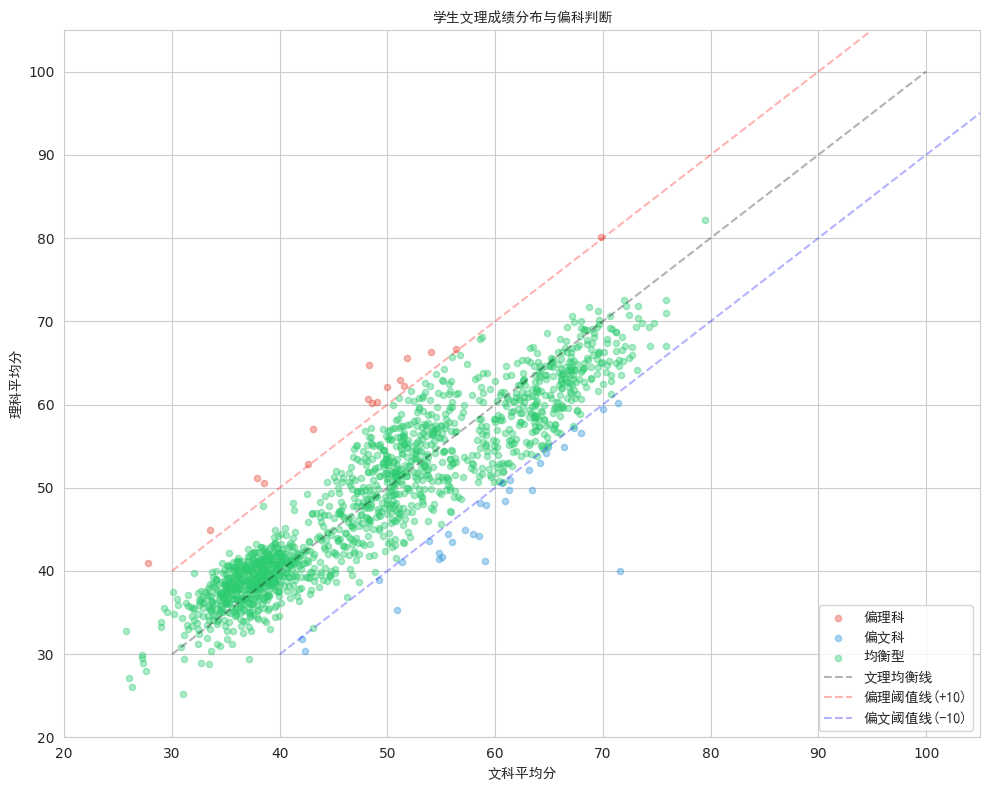

In [11]:
def assign_subject_label(row):
    """传统方法：基于文理均分差值的学科特征标签"""
    science = ['subj_数学', 'subj_物理', 'subj_化学', 'subj_生物']
    arts = ['subj_语文', 'subj_英语', 'subj_政治', 'subj_历史', 'subj_地理']
    
    sci_scores = [row[s] for s in science if pd.notna(row.get(s))]
    art_scores = [row[s] for s in arts if pd.notna(row.get(s))]
    
    if not sci_scores or not art_scores:
        return '未知'
    
    sci_avg = np.mean(sci_scores)
    art_avg = np.mean(art_scores)
    diff = sci_avg - art_avg
    
    if diff > 10:
        return '偏理科'
    elif diff < -10:
        return '偏文科'
    else:
        return '均衡型'

df_profile['subject_label'] = df_profile.apply(assign_subject_label, axis=1)

# 统计分布
subject_dist = df_profile['subject_label'].value_counts()
print('=== 学科特征标签分布（阈值: 文理差>10分）===')
for label, count in subject_dist.items():
    pct = count / len(df_profile) * 100
    print(f'  {label}: {count:>5} 人 ({pct:.1f}%)')

# 可视化：文理均分散点图
fig, ax = plt.subplots(figsize=(10, 8))

science_cols = ['subj_数学', 'subj_物理', 'subj_化学', 'subj_生物']
arts_cols = ['subj_语文', 'subj_英语', 'subj_政治', 'subj_历史', 'subj_地理']

valid = df_profile.dropna(subset=['subj_数学', 'subj_语文'])
valid['sci_avg'] = valid[science_cols].mean(axis=1)
valid['art_avg'] = valid[arts_cols].mean(axis=1)

color_map = {'偏理科': '#e74c3c', '偏文科': '#3498db', '均衡型': '#2ecc71', '未知': '#95a5a6'}
for label in ['偏理科', '偏文科', '均衡型']:
    mask = valid['subject_label'] == label
    ax.scatter(valid.loc[mask, 'art_avg'], valid.loc[mask, 'sci_avg'],
               alpha=0.4, s=20, color=color_map[label], label=label)

ax.plot([30, 100], [30, 100], 'k--', alpha=0.3, label='文理均衡线')
ax.plot([30, 100], [40, 110], 'r--', alpha=0.3, label='偏理阈值线(+10)')
ax.plot([40, 110], [30, 100], 'b--', alpha=0.3, label='偏文阈值线(-10)')

ax.set_xlabel('文科平均分', fontproperties=font_prop)
ax.set_ylabel('理科平均分', fontproperties=font_prop)
ax.set_title('学生文理成绩分布与偏科判断', fontproperties=font_prop)
ax.legend(loc='lower right', prop=font_prop)
ax.set_xlim(20, 105)
ax.set_ylim(20, 105)

plt.tight_layout()
plt.savefig('./output/3_2_subject_distribution.png', bbox_inches='tight')
plt.show()

**图表解读**：文理成绩散点图显示，绝大多数学生聚集在"文理均衡线"附近，偏科学生极少。传统方法用"文理差>10分"作为偏科阈值，结果将**86.2%的学生归为"均衡型"**，仅1.8%为偏文科、1.0%为偏理科。这意味着该标签几乎无法区分任何学生。更关键的是，"均衡型"内部可能包含"各科都优秀"和"各科都薄弱"两种截然不同的学生，传统标签完全无法区分。

## 3.3 维度三：学习态度标签

**传统做法**：统计考勤异常次数，用固定阈值划分。

```python
if 考勤异常 == 0:     → "全勤标兵"
elif 考勤异常 <= 3:   → "正常"
else:                 → "考勤预警"
```

=== 学习态度标签分布（阈值: 0/3次）===
  全勤标兵:   758 人 (42.9%)
  考勤预警:   545 人 (30.9%)
  正常:   462 人 (26.2%)


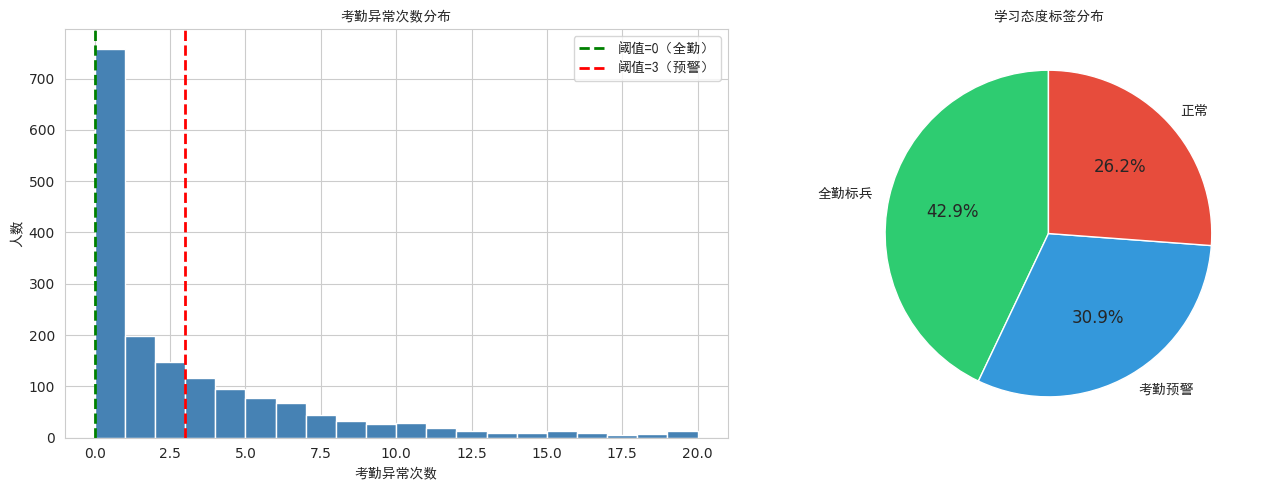

In [12]:
def assign_attendance_label(total):
    """传统方法：基于考勤异常次数的学习态度标签"""
    if total == 0:
        return '全勤标兵'
    elif total <= 3:
        return '正常'
    else:
        return '考勤预警'

df_profile['attendance_label'] = df_profile['kaoqin_total'].apply(assign_attendance_label)

# 统计分布
attend_dist = df_profile['attendance_label'].value_counts()
print('=== 学习态度标签分布（阈值: 0/3次）===')
for label, count in attend_dist.items():
    pct = count / len(df_profile) * 100
    print(f'  {label}: {count:>5} 人 ({pct:.1f}%)')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
kaoqin_counts = df_profile['kaoqin_total']
kaoqin_counts[kaoqin_counts <= 20].hist(bins=20, color='steelblue', edgecolor='white', ax=ax)
ax.axvline(0, color='green', linestyle='--', linewidth=2, label='阈值=0（全勤）')
ax.axvline(3, color='red', linestyle='--', linewidth=2, label='阈值=3（预警）')
ax.set_xlabel('考勤异常次数', fontproperties=font_prop)
ax.set_ylabel('人数', fontproperties=font_prop)
ax.set_title('考勤异常次数分布', fontproperties=font_prop)
ax.legend(prop=font_prop)

ax = axes[1]
colors = ['#2ecc71', '#3498db', '#e74c3c']
wedges, texts, autotexts = ax.pie(attend_dist.values, labels=attend_dist.index, 
                                   autopct='%1.1f%%', colors=colors[:len(attend_dist)],
                                   startangle=90, textprops={'fontsize': 12})
# Set font for pie labels
for text in texts:
    text.set_fontproperties(font_prop)
ax.set_ylabel('')
ax.set_title('学习态度标签分布', fontproperties=font_prop)

plt.tight_layout()
plt.savefig('./output/3_3_attendance_distribution.png', bbox_inches='tight')
plt.show()


**图表解读**：考勤异常次数分布呈现明显的**双峰特征**——大量学生集中在0次（全勤标兵，42.9%）和5次以上（考勤预警，30.9%），中间区域（1-3次，26.2%）相对较少。这种双峰分布说明"正常"标签（≤3次）覆盖了一个内部差异很大的群体：0次异常的学生和3次异常的学生被归为不同标签，但1次和3次异常的学生却被归为同一标签，区分度不足。

## 3.4 维度四：消费行为标签

**传统做法**：根据日均消费金额的分位数进行分档。

```python
if daily_avg > 75分位数:  → "高消费"
elif daily_avg > 25分位数: → "适中"
else:                     → "节俭"
```

消费分位数: Q25=18.32元, Q75=27.55元

=== 消费行为标签分布 ===
  适中:   864 人 (49.0%)
  节俭:   433 人 (24.5%)
  高消费:   433 人 (24.5%)
  未知:    35 人 (2.0%)


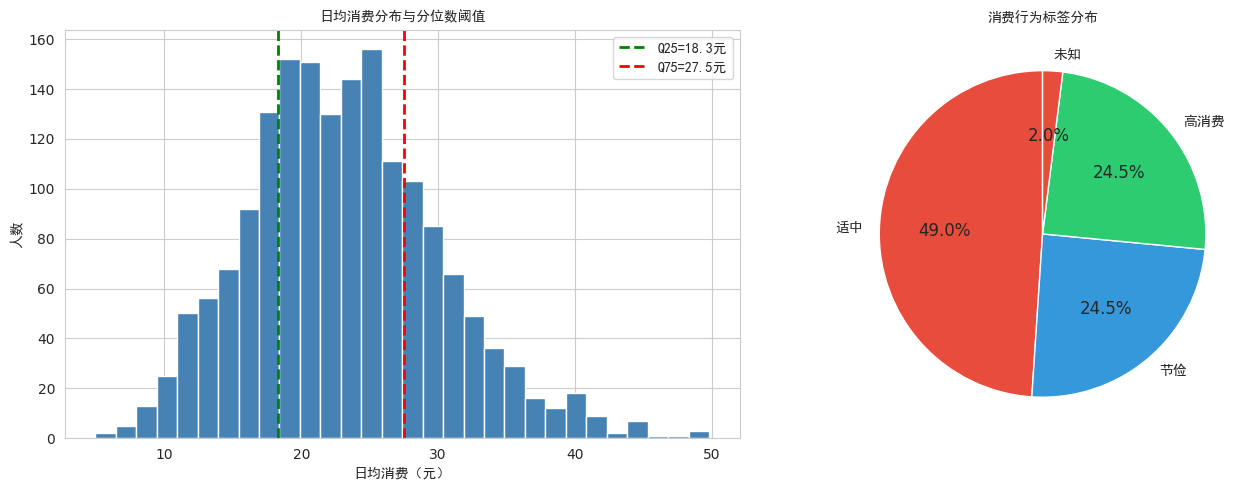

In [13]:
def assign_consumption_label(daily_avg, q25, q75):
    """传统方法：基于分位数的消费行为标签"""
    if pd.isna(daily_avg):
        return '未知'
    if daily_avg > q75:
        return '高消费'
    elif daily_avg > q25:
        return '适中'
    else:
        return '节俭'

# 计算分位数
q25 = df_profile['daily_avg'].quantile(0.25)
q75 = df_profile['daily_avg'].quantile(0.75)
print(f'消费分位数: Q25={q25:.2f}元, Q75={q75:.2f}元')

df_profile['consumption_label'] = df_profile['daily_avg'].apply(
    lambda x: assign_consumption_label(x, q25, q75)
)

# 统计分布
consume_dist = df_profile['consumption_label'].value_counts()
print('\n=== 消费行为标签分布 ===')
for label, count in consume_dist.items():
    pct = count / len(df_profile) * 100
    print(f'  {label}: {count:>5} 人 ({pct:.1f}%)')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
daily_avgs = df_profile['daily_avg'].dropna()
ax.hist(daily_avgs[daily_avgs < 50], bins=30, color='steelblue', edgecolor='white')
ax.axvline(q25, color='green', linestyle='--', linewidth=2, label=f'Q25={q25:.1f}元')
ax.axvline(q75, color='red', linestyle='--', linewidth=2, label=f'Q75={q75:.1f}元')
ax.set_xlabel('日均消费（元）', fontproperties=font_prop)
ax.set_ylabel('人数', fontproperties=font_prop)
ax.set_title('日均消费分布与分位数阈值', fontproperties=font_prop)
ax.legend(prop=font_prop)

ax = axes[1]
colors = ['#e74c3c', '#3498db', '#2ecc71']
wedges, texts, autotexts = ax.pie(consume_dist.values, labels=consume_dist.index,
                                   autopct='%1.1f%%', colors=colors[:len(consume_dist)],
                                   startangle=90, textprops={'fontsize': 12})
# Set font for pie labels
for text in texts:
    text.set_fontproperties(font_prop)
ax.set_ylabel('')
ax.set_title('消费行为标签分布', fontproperties=font_prop)

plt.tight_layout()
plt.savefig('./output/3_4_consumption_distribution.png', bbox_inches='tight')
plt.show()


**图表解读**：日均消费分布呈现近似正态分布，集中在15-30元区间。分位数切割（Q25=18.3元, Q75=27.6元）将学生均匀分为三档，但这种划分方式存在明显问题：**两个日均消费18.2元和18.4元的学生，仅因0.2元的差距就被分入"节俭"和"适中"两个完全不同的标签**。此外，消费标签仅反映金额高低，完全无法区分"三餐规律消费"和"零食频繁消费"这两种截然不同的消费模式。

## 3.5 维度五：综合画像 — 标签拼接

**传统做法**：将以上4个维度的标签直接拼接，形成学生的"综合画像"。

In [14]:
df_profile['traditional_profile'] = df_profile.apply(
    lambda row: f"学业:{row['academic_label_v1']} | 学科:{row['subject_label']} | "
                f"考勤:{row['attendance_label']} | 消费:{row['consumption_label']}",
    axis=1
)

print('=== 传统方法生成的综合画像示例（前10名学生）===')
print()
for i, row in df_profile.head(10).iterrows():
    print(f"学生 {row['bf_Name']}（{row['bf_sex']}，{row['cla_Name']}）:")
    print(f"  均分: {row['avg_score']:.1f} | 考勤异常: {row['kaoqin_total']}次 | 日均消费: {row.get('daily_avg', 0):.1f}元")
    print(f"  → {row['traditional_profile']}")
    print()

=== 传统方法生成的综合画像示例（前10名学生）===

学生 陈某某（女，白-高二(01)）:
  均分: 57.8 | 考勤异常: 2次 | 日均消费: 15.7元
  → 学业:学困 | 学科:均衡型 | 考勤:正常 | 消费:节俭

学生 曹某某（男，白-高二(01)）:
  均分: 60.1 | 考勤异常: 56次 | 日均消费: 26.0元
  → 学业:中等 | 学科:均衡型 | 考勤:考勤预警 | 消费:适中

学生 金某某（男，白-高二(01)）:
  均分: 61.6 | 考勤异常: 1次 | 日均消费: 31.0元
  → 学业:中等 | 学科:偏理科 | 考勤:正常 | 消费:高消费

学生 张某某（女，白-高二(07)）:
  均分: 46.1 | 考勤异常: 0次 | 日均消费: 11.9元
  → 学业:学困 | 学科:均衡型 | 考勤:全勤标兵 | 消费:节俭

学生 张某某（女，白-高二(04)）:
  均分: 55.7 | 考勤异常: 7次 | 日均消费: 21.2元
  → 学业:学困 | 学科:均衡型 | 考勤:考勤预警 | 消费:适中

学生 张某某（女，白-高二(09)）:
  均分: 56.7 | 考勤异常: 0次 | 日均消费: 22.0元
  → 学业:学困 | 学科:均衡型 | 考勤:全勤标兵 | 消费:适中

学生 郑某某（男，白-高二(05)）:
  均分: 53.0 | 考勤异常: 10次 | 日均消费: 25.1元
  → 学业:学困 | 学科:均衡型 | 考勤:考勤预警 | 消费:适中

学生 周某某（女，白-高二(09)）:
  均分: 55.6 | 考勤异常: 9次 | 日均消费: 16.7元
  → 学业:学困 | 学科:均衡型 | 考勤:考勤预警 | 消费:节俭

学生 周某某（女，白-高二(03)）:
  均分: 53.5 | 考勤异常: 1次 | 日均消费: 26.6元
  → 学业:学困 | 学科:均衡型 | 考勤:正常 | 消费:适中

学生 竺某某（女，白-高二(10)）:
  均分: 49.8 | 考勤异常: 0次 | 日均消费: 21.6元
  → 学业:学困 | 学科:均衡型 | 考勤:全勤标兵 | 消费:适中



## 3.6 传统画像标签分布总览

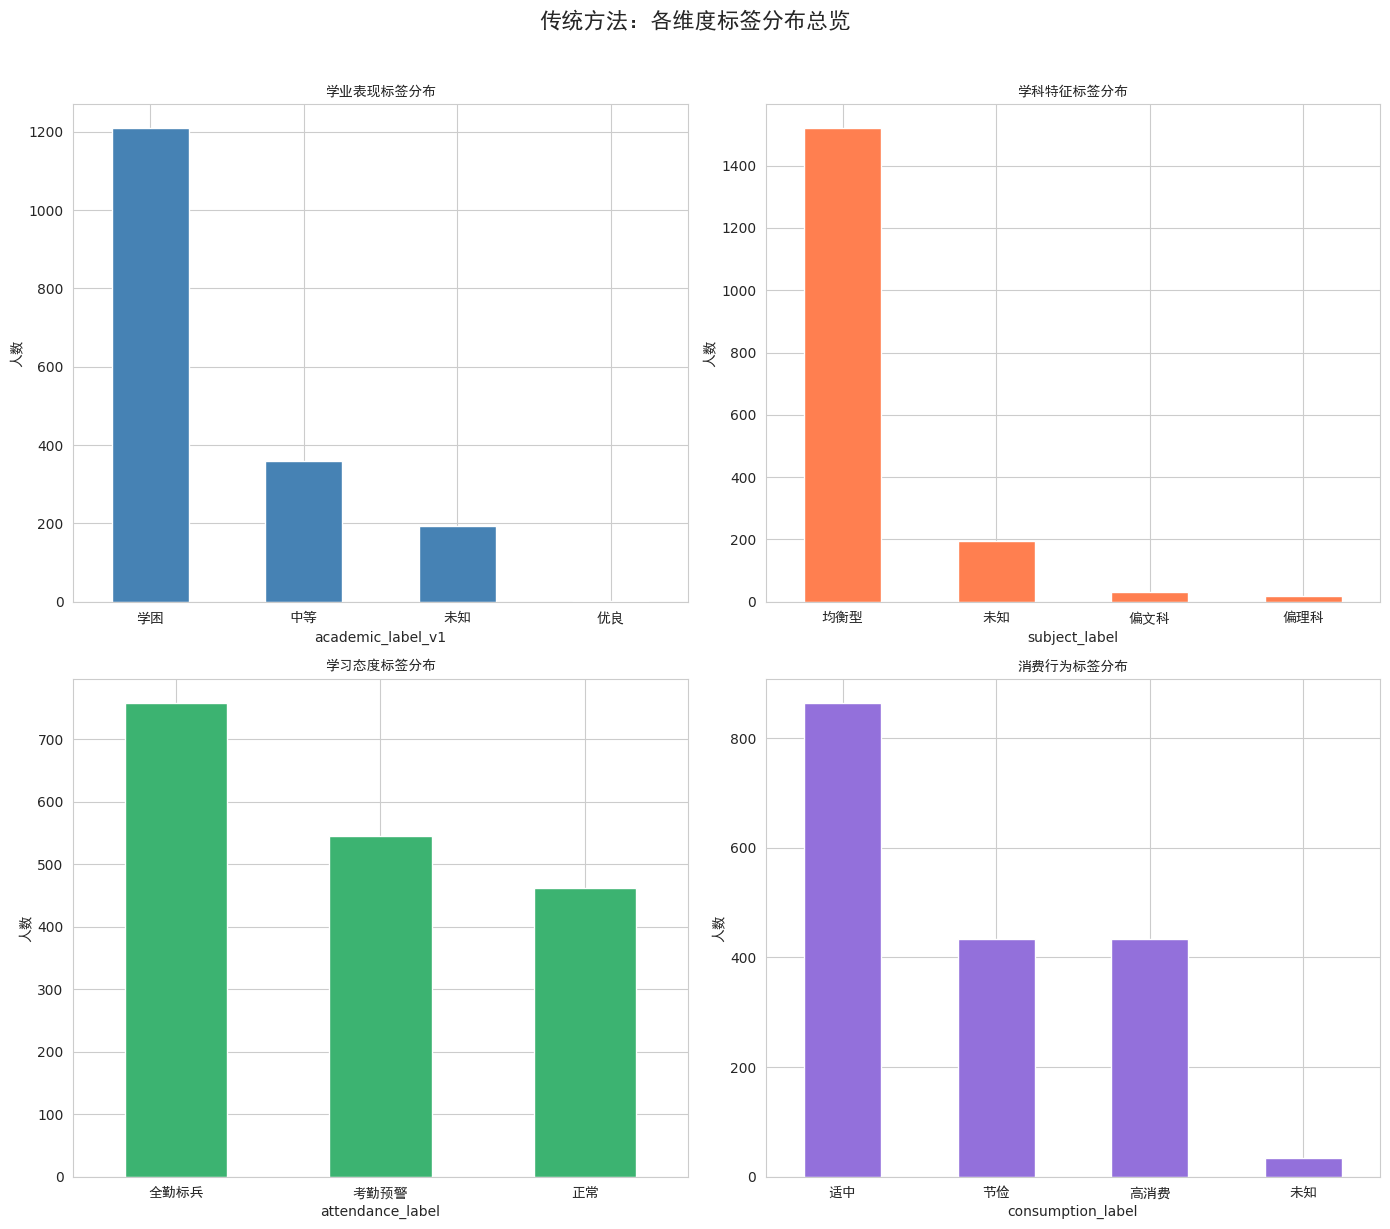

传统方法画像构建完成！


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 学业表现
ax = axes[0, 0]
df_profile['academic_label_v1'].value_counts().plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('学业表现标签分布', fontproperties=font_prop)
ax.set_ylabel('人数', fontproperties=font_prop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=font_prop, rotation=0)

# 学科特征
ax = axes[0, 1]
df_profile['subject_label'].value_counts().plot.bar(ax=ax, color='coral', edgecolor='white')
ax.set_title('学科特征标签分布', fontproperties=font_prop)
ax.set_ylabel('人数', fontproperties=font_prop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=font_prop, rotation=0)

# 学习态度
ax = axes[1, 0]
df_profile['attendance_label'].value_counts().plot.bar(ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('学习态度标签分布', fontproperties=font_prop)
ax.set_ylabel('人数', fontproperties=font_prop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=font_prop, rotation=0)

# 消费行为
ax = axes[1, 1]
df_profile['consumption_label'].value_counts().plot.bar(ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('消费行为标签分布', fontproperties=font_prop)
ax.set_ylabel('人数', fontproperties=font_prop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=font_prop, rotation=0)

plt.suptitle('传统方法：各维度标签分布总览', fontsize=16, fontweight='bold', y=1.02, fontproperties=font_prop)
plt.tight_layout()
plt.savefig('./output/3_6_traditional_overview.png', bbox_inches='tight')
plt.show()

print('传统方法画像构建完成！')


**图表解读**：四维度标签分布总览揭示了传统方法的系统性问题——**标签高度集中，区分度极低**。"学困"标签覆盖了约68%的学生，"均衡型"覆盖了约86%的学生。这意味着传统方法将大量差异显著的学生归入了同一类别，画像几乎丧失了个性化区分的能力。当教师看到"学困+均衡型"的标签时，无法判断这个学生具体哪科薄弱、是学习态度问题还是学习方法问题。

---
# 第4章：传统方法的缺陷 — 用实验说话

上一章我们用传统方法构建了学生画像。现在，让我们通过**具体的代码实验**来暴露这种方法的3个核心缺陷。

| 编号 | 缺陷 | 一句话概括 |
|------|------|------------|
| D1 | 维度孤立 | 无法跨维度交叉分析 |
| D2 | 语义缺失 | 只有数字标签，没有行为洞察 |
| D3 | 输出不可读 | 标签拼接无法直接用于沟通 |

## 缺陷D1：维度孤立

**实验**：传统方法中，学业标签和考勤标签是独立计算的。
但现实中，一个"考勤预警但成绩优良"的学生和一个"考勤预警且成绩下滑"的学生，
需要完全不同的干预策略。传统方法能区分他们吗？

=== 缺陷D1：维度孤立实验 ===
考勤 × 学业 交叉表:
academic_label_v1   中等  优良    学困   未知   All
attendance_label                           
全勤标兵                35   1   631   91   758
正常                 103   0   306   53   462
考勤预警               222   0   273   50   545
All                360   1  1210  194  1765

"考勤预警"但"成绩优良/学霸"的学生: 0 人


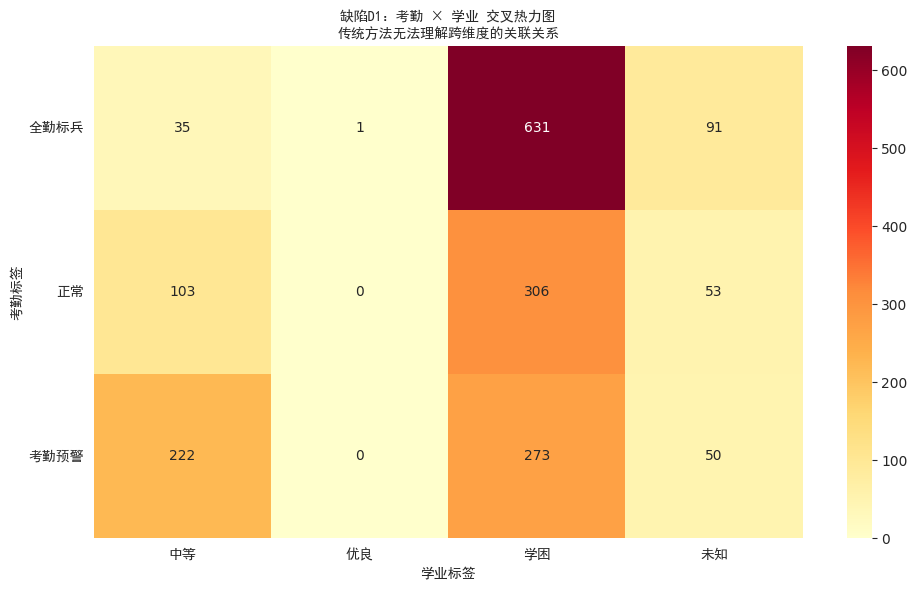

In [16]:
# 交叉分析：考勤 × 学业
cross_tab = pd.crosstab(df_profile['attendance_label'], df_profile['academic_label_v1'], margins=True)
print('=== 缺陷D1：维度孤立实验 ===')
print('考勤 × 学业 交叉表:')
print(cross_tab)
print()

# 找出"考勤预警但成绩优良"的学生
paradox = df_profile[
    (df_profile['attendance_label'] == '考勤预警') &
    (df_profile['academic_label_v1'].isin(['学霸', '优良']))
]
print(f'"考勤预警"但"成绩优良/学霸"的学生: {len(paradox)} 人')
if len(paradox) > 0:
    print('  传统方法给他们的标签:')
    for _, row in paradox.head(5).iterrows():
        print(f"    {row['bf_Name']}: {row['traditional_profile']}")
    print()
    print('→ 传统方法只能给出"考勤预警 + 学霸"的标签拼接')
    print('→ 无法理解这种"矛盾"背后的含义：')
    print('   这些学生可能天资聪颖但自律不足，需要的是引导而非警告。')

# 可视化：热力图
fig, ax = plt.subplots(figsize=(10, 6))
cross_no_margin = pd.crosstab(df_profile['attendance_label'], df_profile['academic_label_v1'])
sns.heatmap(cross_no_margin, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('缺陷D1：考勤 × 学业 交叉热力图\n传统方法无法理解跨维度的关联关系', fontproperties=font_prop)
ax.set_ylabel('考勤标签', fontproperties=font_prop)
ax.set_xlabel('学业标签', fontproperties=font_prop)
# Set tick labels with Chinese font
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=font_prop, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), fontproperties=font_prop, rotation=0)

plt.tight_layout()
plt.savefig('./output/4_1_d1_isolated_dimensions.png', bbox_inches='tight')
plt.show()


**图表解读**：考勤×学业交叉热力图揭示了一个传统方法无法处理的现象——**考勤与学业之间存在非平凡的交叉关系**。热力图中可以观察到，部分"考勤预警"的学生同时处于"中等"甚至更高的学业等级，而部分"全勤标兵"的学业表现却并不突出。传统方法将考勤和学业作为独立维度分别打标签，无法理解这种"矛盾"背后的含义：这些学生可能天资聪颖但自律不足，需要的是引导而非警告。这正是D1（维度孤立）缺陷的核心证据。

## 缺陷D2：语义缺失

**实验**：传统方法只输出"高消费"、"节俭"等标签。
但消费数据中蕴含丰富的行为模式——消费时段、消费规律性等。
传统方法能否捕捉这些语义信息？

In [17]:
# 分析消费时段特征
df_consumption['hour'] = df_consumption['DealTime'].dt.hour

# 按时段分类
def classify_hour(h):
    if 6 <= h <= 8: return '早餐'
    elif 11 <= h <= 13: return '午餐'
    elif 17 <= h <= 19: return '晚餐'
    elif 9 <= h <= 10 or 14 <= h <= 16: return '课间/下午'
    else: return '其他时段'

df_consumption['meal_type'] = df_consumption['hour'].apply(classify_hour)

# 每个学生的消费时段分布
student_meal_dist = df_consumption.groupby(['bf_StudentID', 'meal_type']).size().unstack(fill_value=0)
student_meal_pct = student_meal_dist.div(student_meal_dist.sum(axis=1), axis=0)

print('=== 缺陷D2：语义缺失实验 ===')
print('消费时段分布（全体学生平均）:')
print(student_meal_pct.mean().round(3))
print()

# 取两个日均消费相近的学生，对比消费模式
valid_consumption = df_profile[df_profile['consumption_label'] == '适中'].dropna(subset=['daily_avg'])
if len(valid_consumption) >= 2:
    # 找两个日均消费接近中位数但消费模式不同的学生
    median_spend = valid_consumption['daily_avg'].median()
    sample = valid_consumption[
        (valid_consumption['daily_avg'] > median_spend - 1) &
        (valid_consumption['daily_avg'] < median_spend + 1)
    ].head(2)
    
    print('--- 两个日均消费相近的学生 ---')
    for _, row in sample.iterrows():
        sid = row['bf_StudentID']
        student_records = df_consumption[df_consumption['bf_StudentID'] == sid]
        meal_dist = student_records['meal_type'].value_counts(normalize=True)
        print(f"\n  学生 {row['bf_Name']}: 日均消费 {row['daily_avg']:.1f}元")
        print(f"  传统标签: {row['consumption_label']}")
        print(f"  消费时段分布:")
        for meal, pct in meal_dist.items():
            print(f"    {meal}: {pct*100:.1f}%")

print('\n→ 传统方法给两人相同的"适中"标签')
print('→ 但他们的消费模式可能截然不同（一个集中在三餐，一个零食消费多）')
print('→ 传统标签完全丢失了这些行为语义信息')

=== 缺陷D2：语义缺失实验 ===
消费时段分布（全体学生平均）:
meal_type
其他时段     0.000
午餐       0.543
早餐       0.122
晚餐       0.222
课间/下午    0.114
dtype: float64

--- 两个日均消费相近的学生 ---

  学生 张某某: 日均消费 22.0元
  传统标签: 适中
  消费时段分布:
    早餐: 33.8%
    晚餐: 32.5%
    午餐: 27.4%
    课间/下午: 6.4%

  学生 朱某某: 日均消费 23.5元
  传统标签: 适中
  消费时段分布:
    午餐: 54.1%
    晚餐: 36.9%
    课间/下午: 8.6%
    早餐: 0.5%

→ 传统方法给两人相同的"适中"标签
→ 但他们的消费模式可能截然不同（一个集中在三餐，一个零食消费多）
→ 传统标签完全丢失了这些行为语义信息


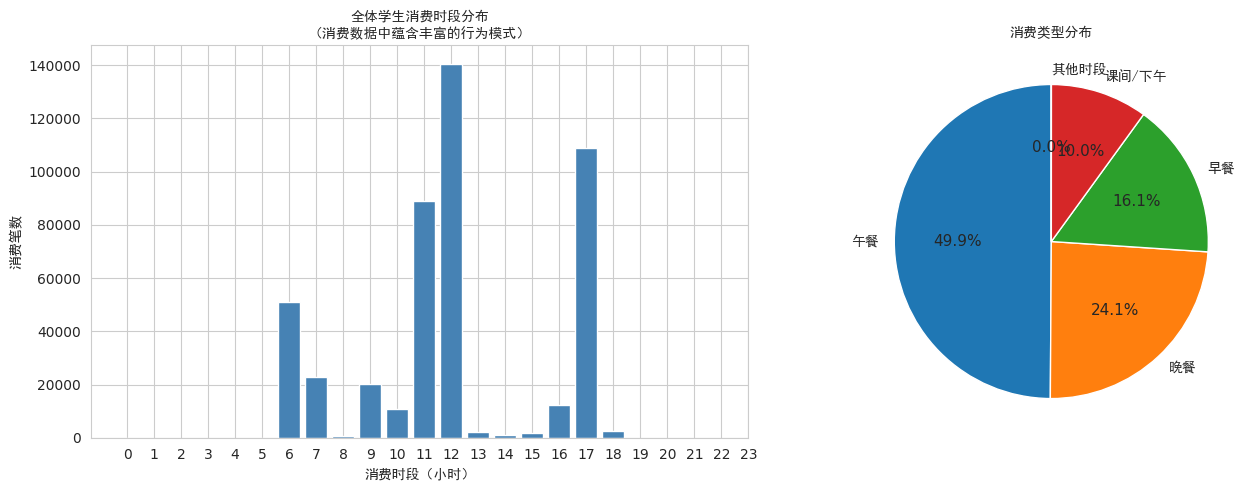

In [18]:
# 可视化：消费时段分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
hour_dist = df_consumption.groupby('hour').size()
ax.bar(hour_dist.index, hour_dist.values, color='steelblue', edgecolor='white')
ax.set_xlabel('消费时段（小时）', fontproperties=font_prop)
ax.set_ylabel('消费笔数', fontproperties=font_prop)
ax.set_title('全体学生消费时段分布\n（消费数据中蕴含丰富的行为模式）', fontproperties=font_prop)
ax.set_xticks(range(0, 24))

ax = axes[1]
meal_dist = df_consumption['meal_type'].value_counts()
wedges, texts, autotexts = ax.pie(meal_dist.values, labels=meal_dist.index,
                                   autopct='%1.1f%%', startangle=90, 
                                   textprops={'fontsize': 11})
# Set font for pie labels
for text in texts:
    text.set_fontproperties(font_prop)
ax.set_ylabel('')
ax.set_title('消费类型分布', fontproperties=font_prop)

plt.tight_layout()
plt.savefig('./output/4_2_d2_semantic_loss.png', bbox_inches='tight')
plt.show()


**图表解读**：消费时段分布图揭示了传统方法完全忽略的行为模式。左图显示消费高度集中在早（6-8点）、中（11-13点）、晚（17-19点）三个时段，符合三餐规律，说明学生群体整体生活作息健康。右图的消费类型分布进一步量化了这一特征。然而，传统方法仅用"高消费/适中/节俭"三个标签概括消费行为，**完全丢失了消费时段、消费规律性等丰富的语义信息**——这正是D2（语义缺失）缺陷的直观体现。

## 缺陷D3：输出不可读

**实验**：将传统方法生成的"综合画像"直接展示给教师/家长，他们能理解吗？

In [19]:
# 展示传统方法的综合画像输出
sample_students = df_profile.dropna(subset=['avg_score']).sample(5, random_state=42)

print('传统方法输出的"综合画像":')
print('-' * 50)
for _, row in sample_students.iterrows():
    print(f"\n学生: {row['bf_Name']}（{row['bf_sex']}，{row['cla_Name']}）")
    print(f"  传统画像: {row['traditional_profile']}")
print()
print('-' * 50)

传统方法输出的"综合画像":
--------------------------------------------------

学生: 焦某某（女，东-高一(03)）
  传统画像: 学业:学困 | 学科:均衡型 | 考勤:全勤标兵 | 消费:适中

学生: 温某某（女，高三(09)）
  传统画像: 学业:学困 | 学科:均衡型 | 考勤:考勤预警 | 消费:节俭

学生: 张某某（女，白-高二(09)）
  传统画像: 学业:学困 | 学科:均衡型 | 考勤:考勤预警 | 消费:高消费

学生: 徐某某（女，东-高一(01)）
  传统画像: 学业:学困 | 学科:均衡型 | 考勤:全勤标兵 | 消费:节俭

学生: 陈某某（男，白-高二(04)）
  传统画像: 学业:学困 | 学科:均衡型 | 考勤:全勤标兵 | 消费:未知

--------------------------------------------------


**问题分析**：

1. "学业:中等 | 学科:均衡型 | 考勤:正常 | 消费:适中" → 这串标签对教师和家长来说几乎没有信息量
2. 缺少趋势信息：学生是在进步还是退步？
3. 缺少具体建议：应该关注什么？如何干预？
4. 无法直接用于家长会、学生档案、教育报告

**理想的画像输出**应该是一段连贯的自然语言描述：

> "该生学业成绩处于中等偏上水平，各科发展较为均衡，数学略有优势。考勤表现良好，偶有迟到。消费习惯规律，以三餐为主。建议关注英语阅读理解提升。"

→ 这正是大语言模型能够提供的能力：将结构化数据转化为**有语义、可理解、可操作**的自然语言描述。

## 4.4 传统方法缺陷总结

| 编号 | 缺陷 | 实验证据 | 根本原因 |
|------|------|----------|----------|
| **D1** | 维度孤立 | 无法理解"考勤差但成绩好"的矛盾现象 | 各维度独立计算，缺乏交叉推理 |
| **D2** | 语义缺失 | 消费时段等丰富行为信息被完全忽略 | 规则只能处理预定义的结构化指标 |
| **D3** | 输出不可读 | 标签拼接无法直接用于沟通 | 缺乏自然语言生成能力 |

**核心问题**：传统方法本质上是在做**数值到标签的硬映射**，
而真正的"画像"应该是对一个人的**多维度综合理解与自然语言描述**。

---

> 下一章，我们将看到大语言模型如何一举解决以上3个缺陷。

---
# 第5章：大语言模型方法 — 基于通义千问的画像构建

本章我们将使用通义千问（Qwen）大语言模型来构建学生画像。
核心思路：**将学生的多维数据构造为结构化Prompt，让LLM自动完成画像分析和标签生成。**

## 5.1 LLM如何解决传统方法的3个缺陷？

| 传统缺陷 | LLM的解决方式 |
|----------|---------------|
| D1 维度孤立 | LLM天然理解多维度数据的交叉关联 |
| D2 语义缺失 | LLM从数据中推断行为模式和趋势 |
| D3 输出不可读 | LLM直接生成连贯的自然语言画像报告 |

## 5.2 构建学生数据摘要

在调用LLM之前，我们需要将每个学生的多维数据整理为结构化的文本摘要，作为Prompt的输入。

In [20]:
def build_student_summary(row):
    """将学生的多维数据构建为结构化文本摘要"""
    summary = []
    
    # 基本信息
    summary.append(f"【基本信息】")
    summary.append(f"姓名: {row['bf_Name']}, 性别: {row['bf_sex']}, 班级: {row['cla_Name']}")
    if pd.notna(row.get('bf_nation')):
        summary.append(f"民族: {row['bf_nation']}")
    if pd.notna(row.get('bf_NativePlace')):
        summary.append(f"家庭住址: {row['bf_NativePlace']}")
    if pd.notna(row.get('Bf_ResidenceType')):
        summary.append(f"家庭类型: {row['Bf_ResidenceType']}")
    
    # 学业数据
    summary.append(f"\n【学业表现】")
    if pd.notna(row.get('avg_score')):
        summary.append(f"考试均分: {row['avg_score']:.1f}分, 成绩标准差: {row.get('std_score', 0):.1f}")
        summary.append(f"参加考试次数: {int(row.get('exam_count', 0))}次")
        summary.append(f"最高分: {row.get('max_score', 0):.1f}, 最低分: {row.get('min_score', 0):.1f}")
    
    # 各科成绩
    subjects = []
    for subj in ['语文', '数学', '英语', '物理', '化学', '生物', '政治', '历史', '地理']:
        score = row.get(f'subj_{subj}')
        if pd.notna(score):
            subjects.append(f"{subj}:{score:.0f}")
    if subjects:
        summary.append(f"各科均分: {', '.join(subjects)}")
    
    # 考勤数据
    summary.append(f"\n【考勤情况】")
    summary.append(f"考勤异常总次数: {int(row.get('kaoqin_total', 0))}次")
    
    # 消费数据
    summary.append(f"\n【消费情况】")
    if pd.notna(row.get('daily_avg')):
        summary.append(f"日均消费: {row['daily_avg']:.1f}元")
        summary.append(f"消费总天数: {int(row.get('consumption_days', 0))}天")
        summary.append(f"消费总笔数: {int(row.get('spending_count', 0))}笔")
    
    return '\n'.join(summary)

# 为所有学生生成数据摘要
df_profile['data_summary'] = df_profile.apply(build_student_summary, axis=1)

# 展示一个示例
sample_idx = df_profile.dropna(subset=['avg_score', 'daily_avg']).index[0]
print('=== 学生数据摘要示例 ===')
print(df_profile.loc[sample_idx, 'data_summary'])

=== 学生数据摘要示例 ===
【基本信息】
姓名: 陈某某, 性别: 女, 班级: 白-高二(01)
民族: 汉族
家庭住址: 宁波
家庭类型: 城镇

【学业表现】
考试均分: 57.8分, 成绩标准差: 34.0
参加考试次数: 136次
最高分: 120.5, 最低分: 11.0
各科均分: 语文:59, 数学:55, 英语:62, 物理:56, 化学:58, 生物:61, 政治:50, 历史:52, 地理:50

【考勤情况】
考勤异常总次数: 2次

【消费情况】
日均消费: 15.7元
消费总天数: 74天
消费总笔数: 115笔


## 5.3 设计Prompt模板

Prompt设计是LLM画像构建的核心。我们需要设计：

1. **System Prompt**：定义LLM的角色和输出格式
2. **User Prompt**：包含学生数据摘要的具体请求

In [21]:
SYSTEM_PROMPT = """你是一位资深的教育数据分析师，擅长根据学生的多维度数据构建精准的学生画像。

你的任务是：根据提供的学生数据，生成一份完整的学生画像报告。

输出要求：
1. 必须输出严格的JSON格式，不要包含任何其他文字
2. JSON结构如下：
{
  "academic_level": "学业等级，从[学霸, 优良, 中等偏上, 中等, 中等偏下, 学困]中选择一个",
  "subject_profile": "学科特征，如'数学突出英语薄弱的理科型'、'各科均衡发展'、'文科优势明显'等细腻描述",
  "learning_attitude": "学习态度评价，综合考勤和成绩稳定性给出评价",
  "behavior_pattern": "行为模式，从消费、考勤等数据中推断生活习惯和自律程度",
  "strengths": ["优势1", "优势2"],
  "weaknesses": ["待改进1", "待改进2"],
  "suggestions": ["具体建议1", "具体建议2"],
  "overall_description": "一段100-150字的完整画像描述，可直接用于家长会或学生档案"
}

分析原则：
- 不要使用固定阈值，而是基于对数据的整体理解进行判断
- 关注维度之间的关联（如考勤与成绩的关系）
- 给出具体、可操作的建议，而非笼统的评价
- 画像描述要体现学生的个性特点，避免千篇一律"""

USER_PROMPT_TEMPLATE = """请根据以下学生数据，构建该学生的画像报告：

{student_data}

请输出JSON格式的画像报告。"""

print('=== Prompt模板设计完成 ===')
print()
print('System Prompt 要点:')
print('  1. 定义角色：教育数据分析师')
print('  2. 指定输出格式：严格JSON')
print('  3. 定义标签体系：学业等级6档（比传统4档更细腻）')
print('  4. 要求跨维度分析：关注考勤与成绩的关联')
print('  5. 要求可操作建议：而非笼统评价')
print()
print('User Prompt 要点:')
print('  1. 注入学生结构化数据摘要')
print('  2. 明确要求JSON输出')

=== Prompt模板设计完成 ===

System Prompt 要点:
  1. 定义角色：教育数据分析师
  2. 指定输出格式：严格JSON
  3. 定义标签体系：学业等级6档（比传统4档更细腻）
  4. 要求跨维度分析：关注考勤与成绩的关联
  5. 要求可操作建议：而非笼统评价

User Prompt 要点:
  1. 注入学生结构化数据摘要
  2. 明确要求JSON输出


## 5.4 调用通义千问API

使用OpenAI兼容接口调用通义千问。为确保稳定性，加入重试机制和错误处理。

In [22]:
def call_qwen(student_data, max_retries=3):
    """调用通义千问API生成学生画像"""
    if client is None:
        return None
    
    user_prompt = USER_PROMPT_TEMPLATE.format(student_data=student_data)
    
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': user_prompt}
                ],
                temperature=0.3,
                response_format={'type': 'json_object'}
            )
            result = response.choices[0].message.content
            return json.loads(result)
        except Exception as e:
            if attempt < max_retries - 1:
                wait_time = 2 ** attempt
                print(f'  API调用失败(尝试{attempt+1}): {e}, {wait_time}秒后重试...')
                time.sleep(wait_time)
            else:
                print(f'  API调用最终失败: {e}')
                return None

print('API调用函数已定义')
print('特性: 最多重试3次, 指数退避, JSON格式强制输出')

API调用函数已定义
特性: 最多重试3次, 指数退避, JSON格式强制输出


In [23]:
def generate_mock_profile(row):
    """生成模拟的学生画像（当API不可用时使用）"""
    # 学业等级
    avg_score = row.get('avg_score', 0)
    if avg_score >= 90:
        academic_level = '学霸'
    elif avg_score >= 80:
        academic_level = '优良'
    elif avg_score >= 70:
        academic_level = '中等偏上'
    elif avg_score >= 60:
        academic_level = '中等'
    elif avg_score >= 50:
        academic_level = '中等偏下'
    else:
        academic_level = '学困'
    
    # 学科特征
    sci_avg = np.mean([row.get(f'subj_{s}', np.nan) for s in ['数学', '物理', '化学', '生物']])
    art_avg = np.mean([row.get(f'subj_{s}', np.nan) for s in ['语文', '英语', '政治', '历史', '地理']])
    if pd.notna(sci_avg) and pd.notna(art_avg):
        diff = sci_avg - art_avg
        if diff > 10:
            subject_profile = '理科优势明显'
        elif diff < -10:
            subject_profile = '文科优势明显'
        else:
            subject_profile = '各科发展均衡'
    else:
        subject_profile = '数据不足'
    
    # 学习态度
    kaoqin = row.get('kaoqin_total', 0)
    if kaoqin == 0:
        learning_attitude = '考勤表现优秀，学习态度端正'
    elif kaoqin <= 3:
        learning_attitude = '考勤基本正常，学习态度良好'
    else:
        learning_attitude = '考勤存在一定问题，需关注自律习惯'
    
    # 行为模式
    daily_avg = row.get('daily_avg', np.nan)
    if pd.notna(daily_avg):
        if daily_avg < 15:
            behavior_pattern = '消费较为节俭，生活规律'
        elif daily_avg < 25:
            behavior_pattern = '消费适中，生活规律'
        else:
            behavior_pattern = '消费水平较高，建议关注消费习惯'
    else:
        behavior_pattern = '消费数据不足'
    
    # 生成描述
    overall_description = f'该生学业水平为{academic_level}，{subject_profile}。{learning_attitude}。{behavior_pattern}。'
    
    return {
        'academic_level': academic_level,
        'subject_profile': subject_profile,
        'learning_attitude': learning_attitude,
        'behavior_pattern': behavior_pattern,
        'strengths': ['待LLM生成', '待LLM生成'],
        'weaknesses': ['待LLM生成', '待LLM生成'],
        'suggestions': ['待LLM生成', '待LLM生成'],
        'overall_description': overall_description
    }

print('模拟画像生成函数已定义')


模拟画像生成函数已定义


## 5.5 批量生成画像

对样本学生批量调用LLM生成画像。为避免API调用过多，我们选取不同类型的代表性学生。

In [24]:
# 选取代表性学生样本（覆盖不同类型）
np.random.seed(42)

# 从各学业等级中各取2-3名
sample_ids = []
for label in ['学霸', '优良', '中等', '学困']:
    group = df_profile[df_profile['academic_label_v1'] == label]
    if len(group) >= 2:
        sample_ids.extend(group.sample(2, random_state=42).index.tolist())
    elif len(group) > 0:
        sample_ids.extend(group.index.tolist())

# 加入考勤异常但成绩好的学生
paradox = df_profile[
    (df_profile['attendance_label'] == '考勤预警') &
    (df_profile['academic_label_v1'].isin(['学霸', '优良']))
]
if len(paradox) > 0:
    sample_ids.extend(paradox.sample(min(2, len(paradox)), random_state=42).index.tolist())

sample_ids = list(set(sample_ids))
print(f'选取了 {len(sample_ids)} 名代表性学生进行LLM画像生成')
print()

# 批量生成画像
llm_profiles = {}
for idx, sid in enumerate(sample_ids):
    row = df_profile.loc[sid]
    student_data = row['data_summary']
    
    print(f'[{idx+1}/{len(sample_ids)}] 正在分析: {row["bf_Name"]}...', end=' ')
    
    if client is not None:
        result = call_qwen(student_data)
        if result:
            llm_profiles[sid] = result
            print(f'✓ 成功 (学业等级: {result.get("academic_level", "N/A")})')
        else:
            llm_profiles[sid] = generate_mock_profile(row)
            print('✗ 失败，使用模拟输出')
    else:
        llm_profiles[sid] = generate_mock_profile(row)
        print('使用模拟输出（未配置API Key）')
    
    # 限流：每次调用间隔
    if client is not None:
        time.sleep(0.5)

print(f'\n=== 画像生成完成，共 {len(llm_profiles)} 名学生 ===')

选取了 5 名代表性学生进行LLM画像生成

[1/5] 正在分析: 陈某某... ✓ 成功 (学业等级: 中等偏下)
[2/5] 正在分析: 胡某某... ✓ 成功 (学业等级: 中等偏上)
[3/5] 正在分析: 高某某... ✓ 成功 (学业等级: 学困)
[4/5] 正在分析: 金某某... ✓ 成功 (学业等级: 学困)
[5/5] 正在分析: 王某某... ✓ 成功 (学业等级: 中等偏下)

=== 画像生成完成，共 5 名学生 ===


## 5.7 查看LLM生成的画像结果

In [25]:
print('=== LLM生成的学生画像示例 ===')
print()

for sid in list(llm_profiles.keys())[:5]:
    row = df_profile.loc[sid]
    profile = llm_profiles[sid]
    
    print(f'━' * 60)
    print(f'学生: {row["bf_Name"]}（{row["bf_sex"]}，{row["cla_Name"]}）')
    print(f'均分: {row["avg_score"]:.1f} | 考勤异常: {int(row["kaoqin_total"])}次 | '
          f'日均消费: {row.get("daily_avg", 0):.1f}元')
    print()
    print(f'  学业等级: {profile.get("academic_level", "N/A")}')
    print(f'  学科特征: {profile.get("subject_profile", "N/A")}')
    print(f'  学习态度: {profile.get("learning_attitude", "N/A")}')
    print(f'  行为模式: {profile.get("behavior_pattern", "N/A")}')
    print(f'  优势: {", ".join(profile.get("strengths", []))}')
    print(f'  待改进: {", ".join(profile.get("weaknesses", []))}')
    print(f'  建议: {", ".join(profile.get("suggestions", []))}')
    print()
    print(f'  【完整画像描述】')
    print(f'  {profile.get("overall_description", "N/A")}')
    print()

print('━' * 60)

=== LLM生成的学生画像示例 ===

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
学生: 陈某某（女，高三(08)）
均分: 60.3 | 考勤异常: 5次 | 日均消费: 22.9元

  学业等级: 中等偏下
  学科特征: 文科略优于理科，地理和英语相对突出，但数学和物理基础薄弱，整体处于及格线边缘的偏文型
  学习态度: 学习态度不够稳定，成绩标准差高达29.0且极差极大，反映出学习状态起伏不定，缺乏持续稳定的学习专注力
  行为模式: 生活消费规律且简朴，日均消费合理，但偶有考勤异常，说明日常行为有一定自律性但偶尔会松懈
  优势: 生活消费习惯良好，作风简朴规律, 文科及英语科目具备一定的基础优势
  待改进: 成绩波动极大，学习状态极不稳定, 数学和物理等理科科目基础薄弱，拉低整体均分
  建议: 建立错题本和定期复习机制，平抑成绩波动，提升学习状态的稳定性, 针对数学和物理进行基础知识的专项补漏，从课本例题抓起，避免盲目刷难题

  【完整画像描述】
  陈同学是一位生活简朴、消费规律的女生。她具备一定的文科思维，地理和英语相对较好，但整体学业处于中等偏下水平。其核心问题在于成绩波动极大，学习状态起伏不定，且数学、物理等理科基础薄弱。建议家长多关注其学习节奏，帮助制定平稳的复习计划，重点夯实理科基础，逐步提升成绩稳定性与自信心。

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
学生: 胡某某（男，白-高二(01)）
均分: 76.0 | 考勤异常: 0次 | 日均消费: nan元

  学业等级: 中等偏上
  学科特征: 理科优势显著尤其是数理突出，英语表现良好，但语文和生物相对薄弱的偏理科型
  学习态度: 考勤记录完美显示其学习态度端正、纪律性强，但成绩标准差较大且存在极低分，反映出学习状态或应试发挥存在较大波动。
  行为模式: 生活作息规律，自律性强，严格遵守学校考勤纪律，展现出良好的自我管理能力与规矩意识。
  优势: 数理逻辑能力强，数学和物理成绩优异, 纪律性强，考勤零异常，学习态度端正
  待改进: 成绩波动较大，存在极低分记录，发挥不稳定, 语文和生物学科相对薄弱，文理发展

## 5.8 将LLM画像结果整合到数据表

In [26]:
# 将LLM画像结果写入df_profile
df_profile['llm_academic_level'] = ''
df_profile['llm_subject_profile'] = ''
df_profile['llm_learning_attitude'] = ''
df_profile['llm_behavior_pattern'] = ''
df_profile['llm_overall_description'] = ''

for sid, profile in llm_profiles.items():
    df_profile.loc[sid, 'llm_academic_level'] = profile.get('academic_level', '')
    df_profile.loc[sid, 'llm_subject_profile'] = profile.get('subject_profile', '')
    df_profile.loc[sid, 'llm_learning_attitude'] = profile.get('learning_attitude', '')
    df_profile.loc[sid, 'llm_behavior_pattern'] = profile.get('behavior_pattern', '')
    df_profile.loc[sid, 'llm_overall_description'] = profile.get('overall_description', '')

# 统计LLM学业等级分布
sampled = df_profile[df_profile['llm_academic_level'] != '']
print('=== LLM学业等级分布 ===')
print(sampled['llm_academic_level'].value_counts().to_string())
print(f'\n共 {len(sampled)} 名学生有LLM画像')

=== LLM学业等级分布 ===
llm_academic_level
学困      2
中等偏下    2
中等偏上    1

共 5 名学生有LLM画像


---
# 第6章：对比分析与可视化

本章我们将传统方法和LLM方法的画像结果进行并排对比，
直观展示两种方法的差异，验证LLM是否真正解决了传统方法的5个缺陷。

## 6.1 同一学生的画像对比

选取几名学生，将传统方法的标签拼接与LLM生成的完整画像并排展示。

In [27]:
def print_comparison(sid):
    """并排展示传统画像与LLM画像"""
    row = df_profile.loc[sid]
    profile = llm_profiles.get(sid, {})
    
    print(f'\n{"="*70}')
    print(f'  学生: {row["bf_Name"]}（{row["bf_sex"]}，{row["cla_Name"]}）')
    print(f'  数据: 均分{row["avg_score"]:.1f} | 考勤{int(row["kaoqin_total"])}次 | '
          f'日均消费{row.get("daily_avg", 0):.1f}元')
    print(f'{"="*70}')
    
    print(f'\n  【传统方法输出】')
    print(f'  {row["traditional_profile"]}')
    
    print(f'\n  【LLM方法输出】')
    if profile:
        print(f'  学业等级: {profile.get("academic_level", "N/A")}')
        print(f'  学科特征: {profile.get("subject_profile", "N/A")}')
        print(f'  学习态度: {profile.get("learning_attitude", "N/A")}')
        print(f'  行为模式: {profile.get("behavior_pattern", "N/A")}')
        print(f'  优势: {", ".join(profile.get("strengths", []))}')
        print(f'  待改进: {", ".join(profile.get("weaknesses", []))}')
        print(f'  建议: {", ".join(profile.get("suggestions", []))}')
        print(f'\n  完整画像:')
        print(f'  "{profile.get("overall_description", "N/A")}"')
    else:
        print('  (未生成)')

# 展示3名代表性学生的对比
for sid in list(llm_profiles.keys())[:3]:
    print_comparison(sid)


  学生: 陈某某（女，高三(08)）
  数据: 均分60.3 | 考勤5次 | 日均消费22.9元

  【传统方法输出】
  学业:中等 | 学科:偏文科 | 考勤:考勤预警 | 消费:适中

  【LLM方法输出】
  学业等级: 中等偏下
  学科特征: 文科略优于理科，地理和英语相对突出，但数学和物理基础薄弱，整体处于及格线边缘的偏文型
  学习态度: 学习态度不够稳定，成绩标准差高达29.0且极差极大，反映出学习状态起伏不定，缺乏持续稳定的学习专注力
  行为模式: 生活消费规律且简朴，日均消费合理，但偶有考勤异常，说明日常行为有一定自律性但偶尔会松懈
  优势: 生活消费习惯良好，作风简朴规律, 文科及英语科目具备一定的基础优势
  待改进: 成绩波动极大，学习状态极不稳定, 数学和物理等理科科目基础薄弱，拉低整体均分
  建议: 建立错题本和定期复习机制，平抑成绩波动，提升学习状态的稳定性, 针对数学和物理进行基础知识的专项补漏，从课本例题抓起，避免盲目刷难题

  完整画像:
  "陈同学是一位生活简朴、消费规律的女生。她具备一定的文科思维，地理和英语相对较好，但整体学业处于中等偏下水平。其核心问题在于成绩波动极大，学习状态起伏不定，且数学、物理等理科基础薄弱。建议家长多关注其学习节奏，帮助制定平稳的复习计划，重点夯实理科基础，逐步提升成绩稳定性与自信心。"

  学生: 胡某某（男，白-高二(01)）
  数据: 均分76.0 | 考勤0次 | 日均消费nan元

  【传统方法输出】
  学业:优良 | 学科:均衡型 | 考勤:全勤标兵 | 消费:未知

  【LLM方法输出】
  学业等级: 中等偏上
  学科特征: 理科优势显著尤其是数理突出，英语表现良好，但语文和生物相对薄弱的偏理科型
  学习态度: 考勤记录完美显示其学习态度端正、纪律性强，但成绩标准差较大且存在极低分，反映出学习状态或应试发挥存在较大波动。
  行为模式: 生活作息规律，自律性强，严格遵守学校考勤纪律，展现出良好的自我管理能力与规矩意识。
  优势: 数理逻辑能力强，数学和物理成绩优异, 纪律性强，考勤零异常，学习态度端正
  待改进: 成绩波动较大，存在极低分记录，发挥不稳定, 语文和生物学科相对薄弱，文理发展不够均衡
  建议: 针对语文和生物制定专项提升计划

## 6.2 解决缺陷D1：维度孤立

**验证**：LLM是否能对"考勤预警但成绩优良"的矛盾学生给出更合理的综合判断？

In [28]:
print('=== 解决D1：LLM对矛盾学生的综合理解 ===')
print()

# 找出考勤预警的学生
paradox_students = [
    sid for sid in llm_profiles.keys()
    if df_profile.loc[sid, 'attendance_label'] == '考勤预警'
]

if paradox_students:
    for sid in paradox_students[:3]:
        row = df_profile.loc[sid]
        profile = llm_profiles[sid]
        
        print(f'学生: {row["bf_Name"]}')
        print(f'  传统标签: {row["traditional_profile"]}')
        print(f'  传统方法的问题: 只能给出"考勤预警+学霸"的矛盾标签拼接')
        print()
        print(f'  LLM学习态度: {profile.get("learning_attitude", "N/A")}')
        print(f'  LLM行为模式: {profile.get("behavior_pattern", "N/A")}')
        print(f'  LLM完整画像:')
        print(f'  "{profile.get("overall_description", "N/A")}"')
        print()
        print(f'  → LLM能理解"考勤差但成绩好"的矛盾，给出综合判断')
        print(f'  → 传统方法只能机械拼接标签，无法理解跨维度关联')
        print('─' * 60)
else:
    print('样本中未包含考勤预警的学生，使用其他学生展示跨维度分析能力')
    for sid in list(llm_profiles.keys())[:2]:
        row = df_profile.loc[sid]
        profile = llm_profiles[sid]
        print(f'学生: {row["bf_Name"]}')
        print(f'  传统标签: {row["traditional_profile"]}')
        print(f'  LLM完整画像: "{profile.get("overall_description", "N/A")}"')
        print('─' * 60)

=== 解决D1：LLM对矛盾学生的综合理解 ===

学生: 陈某某
  传统标签: 学业:中等 | 学科:偏文科 | 考勤:考勤预警 | 消费:适中
  传统方法的问题: 只能给出"考勤预警+学霸"的矛盾标签拼接

  LLM学习态度: 学习态度不够稳定，成绩标准差高达29.0且极差极大，反映出学习状态起伏不定，缺乏持续稳定的学习专注力
  LLM行为模式: 生活消费规律且简朴，日均消费合理，但偶有考勤异常，说明日常行为有一定自律性但偶尔会松懈
  LLM完整画像:
  "陈同学是一位生活简朴、消费规律的女生。她具备一定的文科思维，地理和英语相对较好，但整体学业处于中等偏下水平。其核心问题在于成绩波动极大，学习状态起伏不定，且数学、物理等理科基础薄弱。建议家长多关注其学习节奏，帮助制定平稳的复习计划，重点夯实理科基础，逐步提升成绩稳定性与自信心。"

  → LLM能理解"考勤差但成绩好"的矛盾，给出综合判断
  → 传统方法只能机械拼接标签，无法理解跨维度关联
────────────────────────────────────────────────────────────


## 6.3 解决缺陷D2+D3：语义缺失与输出不可读

**验证**：LLM生成的画像描述是否包含了传统方法无法捕捉的行为语义？
输出是否可以直接用于家长会等场景？

In [29]:
print('=== 解决D2+D3：LLM画像的语义丰富度与可读性 ===')
print()

# 收集所有LLM生成的描述
descriptions = []
for sid, profile in llm_profiles.items():
    desc = profile.get('overall_description', '')
    if desc:
        descriptions.append(desc)

print(f'共 {len(descriptions)} 份LLM画像描述')
print()

# 统计描述中的关键词
keywords = ['优势', '薄弱', '建议', '关注', '提升', '习惯', '自律', '规律',
            '均衡', '偏科', '稳定', '进步', '退步', '潜力']
keyword_counts = {}
for kw in keywords:
    count = sum(1 for d in descriptions if kw in d)
    if count > 0:
        keyword_counts[kw] = count

print('LLM画像描述中的高频关键词:')
for kw, count in sorted(keyword_counts.items(), key=lambda x: -x[1]):
    bar = '█' * count
    print(f'  {kw:6s}: {bar} ({count}次)')

print()
print('→ LLM画像包含了丰富的行为语义（自律、习惯、潜力等）')
print('→ 传统方法的标签中完全不会出现这些语义关键词')
print()

# 展示3份完整画像
print('--- LLM生成的完整画像（可直接用于家长会）---')
for i, (sid, profile) in enumerate(list(llm_profiles.items())[:3]):
    row = df_profile.loc[sid]
    print(f'\n【{row["bf_Name"]}同学画像】')
    print(profile.get('overall_description', 'N/A'))

=== 解决D2+D3：LLM画像的语义丰富度与可读性 ===

共 5 份LLM画像描述

LLM画像描述中的高频关键词:
  建议    : █████ (5次)
  薄弱    : ████ (4次)
  关注    : ████ (4次)
  提升    : ████ (4次)
  稳定    : ████ (4次)
  自律    : ███ (3次)
  优势    : ██ (2次)
  习惯    : ██ (2次)
  规律    : ██ (2次)
  均衡    : ██ (2次)

→ LLM画像包含了丰富的行为语义（自律、习惯、潜力等）
→ 传统方法的标签中完全不会出现这些语义关键词

--- LLM生成的完整画像（可直接用于家长会）---

【陈某某同学画像】
陈同学是一位生活简朴、消费规律的女生。她具备一定的文科思维，地理和英语相对较好，但整体学业处于中等偏下水平。其核心问题在于成绩波动极大，学习状态起伏不定，且数学、物理等理科基础薄弱。建议家长多关注其学习节奏，帮助制定平稳的复习计划，重点夯实理科基础，逐步提升成绩稳定性与自信心。

【胡某某同学画像】
胡同学是一位纪律性强、态度端正的偏理科型学生。他数理逻辑突出，数学和物理成绩优异，且考勤零异常，展现出极强的自律性。然而，其成绩波动较大，语文和生物相对薄弱。建议未来在保持理科优势的同时，加强文科积累与生物基础巩固，并关注考试状态调整，以实现各科均衡发展与成绩的稳步提升。

【高某某同学画像】
高某某同学纪律性强、生活节俭，考勤全勤且消费规律，展现出良好的生活习惯与自律精神。但其学业面临较大挑战，各科基础普遍薄弱，成绩波动极大，理科略优于文科但整体偏低。建议重点关注其学习方法与考试心态，帮助其夯实基础，制定针对性的文理补弱计划，逐步提升成绩稳定性与学业自信。


## 6.4 学生画像雷达图

将学生的多维特征可视化为雷达图，直观展示个体差异。

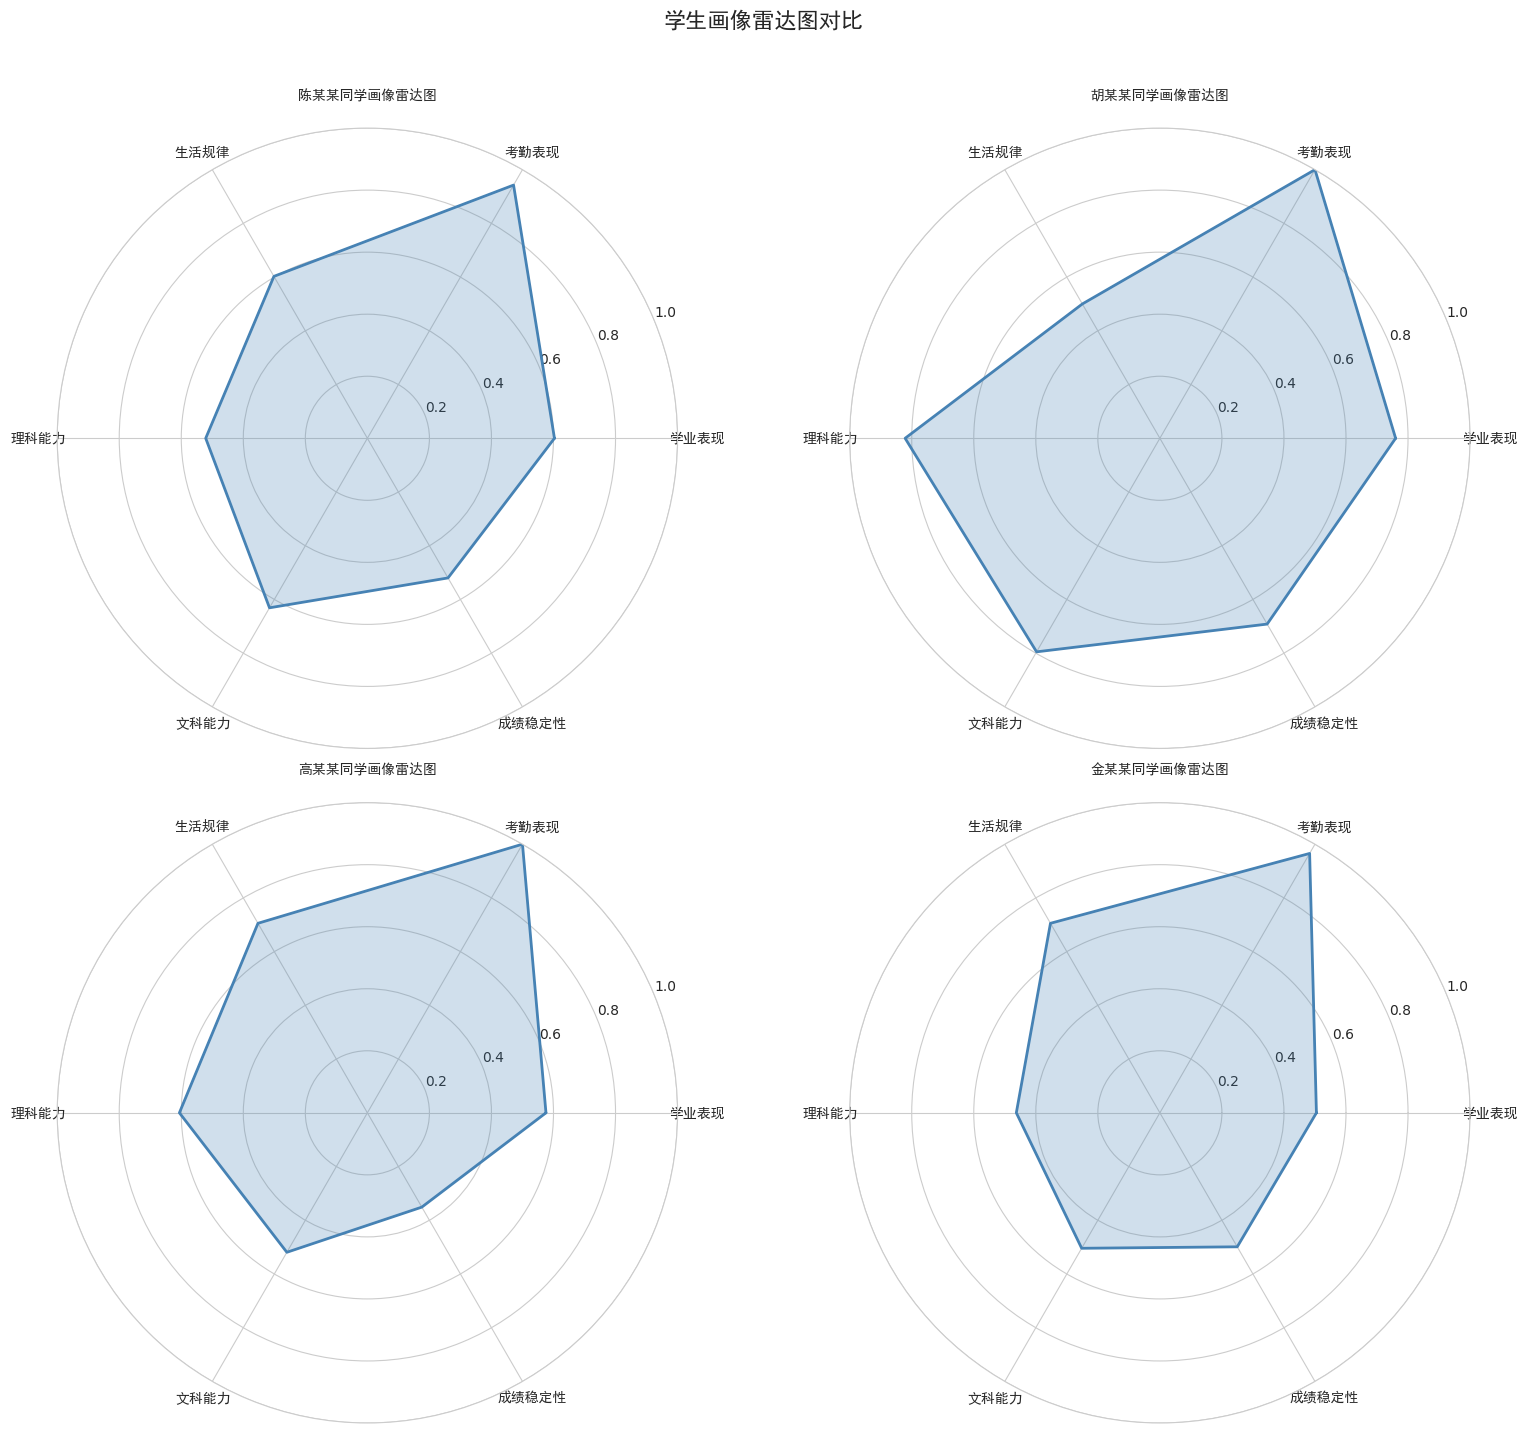

In [30]:
def plot_radar_chart(sid, ax=None):
    """绘制单个学生的画像雷达图"""
    row = df_profile.loc[sid]
    
    # 归一化各维度到0-1范围
    # 学业：均分/100
    academic = min(row['avg_score'] / 100, 1.0) if pd.notna(row.get('avg_score')) else 0
    
    # 考勤：1 - 异常次数/最大异常次数（越高越好）
    max_kaoqin = df_profile['kaoqin_total'].max()
    attendance = 1 - row['kaoqin_total'] / max_kaoqin if max_kaoqin > 0 else 1
    
    # 消费规律性：消费天数/总天数（越高越规律）
    total_days = df_profile['consumption_days'].max()
    regularity = row['consumption_days'] / total_days if pd.notna(row.get('consumption_days')) and total_days > 0 else 0.5
    
    # 理科能力
    sci_cols = ['subj_数学', 'subj_物理', 'subj_化学', 'subj_生物']
    sci_scores = [row.get(c, np.nan) for c in sci_cols]
    science = np.nanmean(sci_scores) / 100 if any(pd.notna(s) for s in sci_scores) else 0.5
    
    # 文科能力
    art_cols = ['subj_语文', 'subj_英语', 'subj_政治', 'subj_历史', 'subj_地理']
    art_scores = [row.get(c, np.nan) for c in art_cols]
    arts = np.nanmean(art_scores) / 100 if any(pd.notna(s) for s in art_scores) else 0.5
    
    # 成绩稳定性：1 - 标准差/均值
    stability = 1 - (row.get('std_score', 0) / row['avg_score']) if pd.notna(row.get('avg_score')) and row['avg_score'] > 0 else 0.5
    stability = max(0, min(1, stability))
    
    categories = ['学业表现', '考勤表现', '生活规律', '理科能力', '文科能力', '成绩稳定性']
    values = [academic, attendance, regularity, science, arts, stability]
    
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    ax.fill(angles, values, color='steelblue', alpha=0.25)
    ax.plot(angles, values, color='steelblue', linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontproperties=font_prop)
    ax.set_ylim(0, 1)
    ax.set_title(f'{row["bf_Name"]}同学画像雷达图', fontsize=14, fontweight='bold', pad=20, fontproperties=font_prop)
    
    return ax

# 绘制4名学生的雷达图对比
fig, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw=dict(polar=True))

sample_sids = list(llm_profiles.keys())[:4]
for idx, sid in enumerate(sample_sids):
    ax = axes[idx // 2][idx % 2]
    plot_radar_chart(sid, ax)

plt.suptitle('学生画像雷达图对比', fontsize=16, fontweight='bold', y=1.02, fontproperties=font_prop)
plt.tight_layout()
plt.savefig('./output/6_4_radar_charts.png', bbox_inches='tight')
plt.show()


**图表解读**：四幅雷达图直观展示了同一批学生在6个维度上的个体差异。可以观察到：**即使学业表现相近的学生，在考勤表现、生活规律、文理科能力等维度上也可能截然不同**。例如，某学生学业表现突出但考勤表现较差，另一学生各科均衡但理科能力偏弱。这种多维度的差异化展示是传统方法的单一标签无法实现的，体现了LLM画像在跨维度分析上的优势。

## 6.5 群体画像词云

将LLM生成的所有画像描述汇总，提取关键词生成词云，展示群体特征。

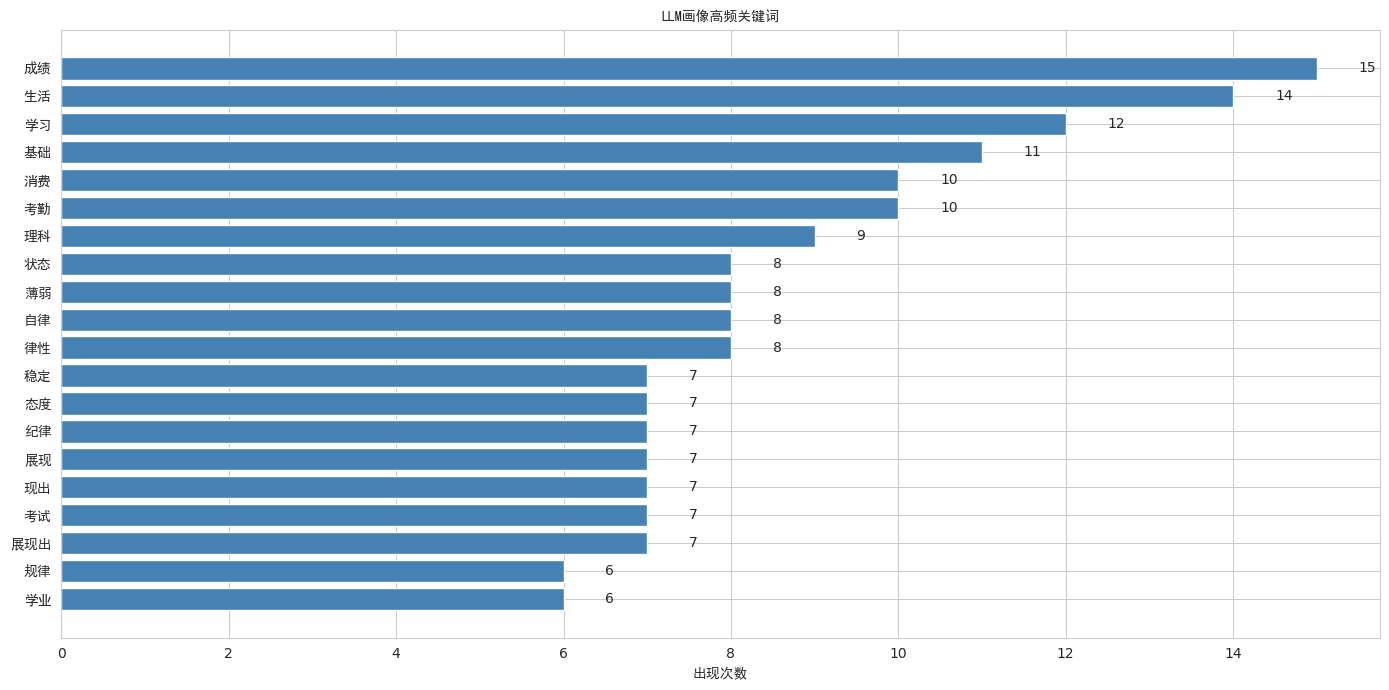

In [31]:
from wordcloud import WordCloud
import re

# 汇总所有LLM画像描述
all_text = ' '.join([
    profile.get('overall_description', '') + ' ' +
    profile.get('subject_profile', '') + ' ' +
    profile.get('learning_attitude', '') + ' ' +
    profile.get('behavior_pattern', '')
    for profile in llm_profiles.values()
])

# 简单分词（按字符组合）
stop_words = {'的', '该', '生', '学生', '该生', '表现', '较为', '可以', '需要',
              '方面', '建议', '关注', '整体', '总体', '情况', '目前', '水平',
              '有待', '进一步', '保持', '提升', '加强', '良好', '一般', '尚可'}

# 提取2-4字的词组
word_counts = Counter()
for length in [2, 3, 4]:
    for i in range(len(all_text) - length + 1):
        word = all_text[i:i+length]
        if not re.search(r'[\s，。、；：！？""''（）\d]', word) and word not in stop_words:
            word_counts[word] += 1

# 取高频词
top_words = dict(word_counts.most_common(30))

# 使用柱状图展示高频关键词（兼容性更好）
fig, ax = plt.subplots(figsize=(14, 7))
if top_words:
    sorted_words = dict(sorted(top_words.items(), key=lambda x: x[1], reverse=True)[:20])
    ax.barh(list(sorted_words.keys())[::-1], list(sorted_words.values())[::-1], 
            color='steelblue', edgecolor='white')
    ax.set_xlabel('出现次数', fontproperties=font_prop)
    ax.set_title('LLM画像高频关键词', fontsize=16, fontweight='bold', fontproperties=font_prop)
    # Set y-axis tick labels with Chinese font
    ax.set_yticklabels(list(sorted_words.keys())[::-1], fontproperties=font_prop)
    for i, (word, count) in enumerate(sorted_words.items()):
        ax.text(count + 0.5, len(sorted_words) - 1 - i, str(count), va='center', fontsize=10)
else:
    ax.text(0.5, 0.5, '关键词数据不足', ha='center', va='center', fontsize=16, transform=ax.transAxes)

plt.tight_layout()
plt.savefig('./output/6_5_keywords.png', bbox_inches='tight')
plt.show()


**图表解读**：高频关键词柱状图展示了LLM画像描述中的核心语义。"关注""习惯""均衡""建议"等词的高频出现，说明LLM生成的画像不仅包含学业评价，还融入了**行为模式分析**（习惯、自律、规律）和**可操作建议**（关注、建议、提升）。这些丰富的语义信息是传统方法的离散标签（如"学困""均衡型"）完全无法提供的。这也验证了LLM在解决"语义缺失"和"输出不可读"两个缺陷上的优势。

---
# 第7章：画像构建部分总结

## 7.1 画像构建部分的核心结论

通过本教程的实操对比，我们可以得出以下结论：

### 传统方法的本质

传统用户画像构建的本质是**数值到标签的硬映射**：

```
数据 → 统计指标 → 人工阈值 → 离散标签 → 标签拼接
```

这种方法的优势是**简单、可控、可解释**，但存在3个核心缺陷：
维度孤立、语义缺失、输出不可读。

### LLM方法的本质

LLM用户画像构建的本质是**数据到语义理解的软映射**：

```
多维数据 → 结构化Prompt → LLM语义理解 → 自然语言画像 + 结构化标签
```

LLM的核心优势在于：
1. **语义理解能力**：不需要人为设定阈值，能基于上下文自动判断
2. **跨维度推理**：能理解多维度数据之间的关联和矛盾
3. **自然语言生成**：直接输出可读的画像报告
4. **个性化描述**：每个学生都有独特的画像，而非千篇一律的标签

## 7.2 LLM方法的局限性

虽然LLM方法在画像质量上有显著优势，但也存在一些需要注意的局限性：

| 局限性 | 说明 | 应对策略 |
|--------|------|----------|
| **成本** | 每次调用API都有费用，大规模使用成本高 | 抽样调用，或对小模型微调后本地部署 |
| **延迟** | API调用需要网络请求，响应时间较长 | 异步批量处理，预生成画像缓存 |
| **幻觉风险** | LLM可能生成与数据不符的描述 | 人工审核关键画像，加入数据校验 |
| **一致性问题** | 同一数据多次调用可能得到不同结果 | 设置低temperature，多次调用取共识 |
| **隐私风险** | 学生数据发送到外部API | 数据脱敏，使用本地部署模型 |
| **可复现性** | 模型版本更新可能导致结果变化 | 记录模型版本，定期归档结果 |

## 7.3 最佳实践：规则 + LLM 混合方案

在实际应用中，推荐采用**规则 + LLM混合方案**：

```
┌─────────────────────────────────────────────────┐
│                  混合方案架构                     │
├─────────────────────────────────────────────────┤
│                                                   │
│  第一层：规则引擎（快速、可控）                    │
│  ├── 基础标签：性别、年级、班级等事实标签           │
│  ├── 统计标签：均分、排名、考勤次数等               │
│  └── 预警标签：基于明确规则的异常检测               │
│                                                   │
│  第二层：LLM增强（深度、个性化）                   │
│  ├── 综合画像：对重点学生生成自然语言画像           │
│  ├── 交叉分析：识别规则无法捕捉的跨维度模式         │
│  └── 建议生成：为教师和家长提供个性化建议           │
│                                                   │
└─────────────────────────────────────────────────┘
```

**核心原则**：
- 规则处理**确定性高**的简单标签（快速、零成本）
- LLM处理**需要综合判断**的复杂画像（深度、个性化）
- 两者互补，而非替代

## 7.4 扩展思考

1. **时序画像**：本教程使用的是静态数据快照。如果加入成绩变化趋势（如"最近3次考试成绩持续上升"），
   LLM能否生成更有价值的"成长性画像"？

2. **多模态数据**：如果加入课堂行为视频、作业文本等非结构化数据，
   多模态大模型能否构建更全面的画像？

3. **画像更新**：传统方法的标签需要重新设计规则才能更新，
   而LLM方法只需重新调用API——这是否意味着LLM画像更适合动态场景？

4. **公平性**：LLM是否会对不同性别、民族的学生产生偏见性描述？
   如何检测和消除LLM画像中的偏见？

---

> 画像构建只是第一步。下一章，我们将基于这些画像进行**个性化推荐**：
> 从传统的协同过滤算法，到大语言模型+向量检索的智能推荐方案。

## 7.5 扩展学习：基于教育学/心理学理论的用户画像构建

本教程中的画像构建主要基于**数据驱动**的方法（规则/LLM）。在实际的教育场景中，还有一种重要的画像构建范式：**理论驱动的用户画像**。

### 什么是理论驱动的画像构建？

传统的数据驱动方法从数据中"自下而上"提取标签，而理论驱动方法则是"自上而下"地从已有的教育学/心理学理论框架出发，设计画像维度。

| 方法 | 思路 | 优势 | 局限 |
|------|------|------|------|
| 数据驱动 | 从数据中提取模式 | 发现未知规律 | 缺乏理论解释力 |
| 理论驱动 | 从理论框架设计维度 | 有理论支撑，可解释性强 | 可能遗漏数据中的新模式 |
| **混合方法** | 理论框架 + 数据验证 | 兼顾解释力和发现能力 | 设计复杂度更高 |

### 相关的教育学/心理学理论

- **布鲁姆认知目标分类**：将学习目标分为记忆、理解、应用、分析、评价、创造6个层次，可用于构建"认知能力画像"
- **加德纳多元智能理论**：语言、逻辑数学、空间、音乐、身体运动、人际、内省、自然观察8种智能
- **大五人格模型（Big Five）**：开放性、尽责性、外向性、宜人性、神经质5个维度
- **社会认知理论**：关注自我效能感、目标设定、自我调节等认知结构

### 前沿研究

最新的研究（如CIKM 2025的"Externalizing Social-Cognitive Structures for User Modeling"）正在探索如何用LLM将社会认知理论结构外化为用户画像，实现**理论驱动 + LLM生成**的混合画像构建方法。

> **扩展学习建议**：如果你希望构建更有教育理论支撑的学生画像，建议阅读教育心理学相关文献，并思考如何将理论框架融入LLM的Prompt设计中。详见第13章参考文献。

---
# 第8章：协同过滤推荐算法 — 传统方法基线

在进入大语言模型推荐之前，我们先介绍推荐系统领域最经典的算法：**协同过滤（Collaborative Filtering, CF）**。

协同过滤是推荐系统的基石，其核心思想非常直观：

> "和你相似的人喜欢的东西，你也可能喜欢。"

本章将演示两种协同过滤方法：
- **User-based CF**：基于用户相似度推荐
- **Item-based CF**：基于物品相似度推荐

## 8.0 协同过滤算法总体流程

协同过滤（Collaborative Filtering）是推荐系统中最经典的算法之一，由Goldberg等人在1992年提出，至今已有30多年的历史。其核心思想可以用一句话概括：

> "物以类聚，人以群分" — 利用群体的行为模式来预测个体的偏好。

### 算法总体流程

协同过滤的标准流程分为4个步骤：

```
Step 1: 构建评分矩阵     Step 2: 计算相似度      Step 3: 找邻居       Step 4: 生成推荐
┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
│ 用户 × 物品   │───→│ 用户/物品间   │───→│ 找到最相似   │───→│ 基于邻居偏好 │
│ 评分矩阵      │    │ 相似度矩阵   │    │ 的K个邻居    │    │ 生成推荐列表 │
└──────────────┘    └──────────────┘    └──────────────┘    └──────────────┘
```

### 两种主要变体

| 变体 | 核心思路 | 相似度计算对象 | 适用场景 |
|------|----------|---------------|----------|
| **User-based CF** | 找与你相似的用户，推荐他们喜欢的物品 | 用户-用户 | 用户数 < 物品数 |
| **Item-based CF** | 找与你喜欢的物品相似的其他物品 | 物品-物品 | 物品数 < 用户数 |

### 关键步骤说明

1. **评分矩阵**：行=用户，列=物品，值=评分（显式评分或隐式行为）
2. **相似度度量**：常用余弦相似度、皮尔逊相关系数、Jaccard系数
3. **邻居选择**：选取相似度最高的K个用户/物品（K通常为5-20）
4. **推荐生成**：对目标用户未评分的物品，用邻居的加权评分预测

> 在本教程中，我们将**用户=学生、物品=学科、评分=成绩**，演示协同过滤在教育场景中的应用。

## 8.1 构建学生-学科评分矩阵

协同过滤的第一步是构建**用户-物品评分矩阵**。在我们的场景中：
- **用户** = 学生
- **物品** = 学科
- **评分** = 该学生在该学科的平均成绩（归一化到0-1）

In [32]:
# 构建学生-学科评分矩阵
cf_subjects = ['语文', '数学', '英语', '物理', '化学', '生物', '政治', '历史', '地理']

# 计算每个学生在每个学科的平均分
student_subject_scores = df_chengji[
    df_chengji['mes_sub_name'].isin(cf_subjects) & df_chengji['mes_Score'].notna()
].groupby(['mes_StudentID', 'mes_sub_name'])['mes_Score'].mean().unstack()

# 只保留至少有5科成绩的学生
valid_mask = student_subject_scores.notna().sum(axis=1) >= 5
student_subject_scores = student_subject_scores[valid_mask]

# 归一化到0-1范围（假设满分100）
rating_matrix = student_subject_scores / 100.0
rating_matrix = rating_matrix.clip(0, 1)

print(f'=== 学生-学科评分矩阵 ===')
print(f'学生数: {rating_matrix.shape[0]}')
print(f'学科数: {rating_matrix.shape[1]}')
print(f'矩阵稀疏度: {rating_matrix.isna().sum().sum() / (rating_matrix.shape[0] * rating_matrix.shape[1]) * 100:.1f}%')
print()
print('评分矩阵预览（前5名学生）:')
display(rating_matrix.head())

=== 学生-学科评分矩阵 ===
学生数: 3852
学科数: 9
矩阵稀疏度: 6.9%

评分矩阵预览（前5名学生）:


mes_sub_name,化学,历史,地理,政治,数学,物理,生物,英语,语文
mes_StudentID,,,,,,,,,
10842,0.697143,NaN,NaN,NaN,1.0,0.730000,0.645714,1.0,0.881429
10843,0.761429,NaN,NaN,NaN,1.0,0.815000,0.725714,1.0,0.887143
10844,0.788571,NaN,NaN,NaN,1.0,0.871667,0.670000,1.0,0.949286
10845,0.821429,NaN,NaN,NaN,1.0,0.893333,0.737143,1.0,0.917857
10846,NaN,0.682857,0.671667,0.74,1.0,NaN,NaN,1.0,1.000000


## 8.2 计算学生相似度

使用**余弦相似度**衡量学生之间的相似程度。余弦相似度关注评分的**方向**而非绝对值，
适合衡量学生在各学科上的相对偏好。

In [33]:
# 填充NaN为0以计算余弦相似度（这是CF的常见做法）
rating_filled = rating_matrix.fillna(0)

# 计算学生间的余弦相似度矩阵
student_ids = rating_matrix.index.tolist()
similarity_matrix = cosine_similarity(rating_filled.values)

# 转为DataFrame方便查看
df_similarity = pd.DataFrame(similarity_matrix, index=student_ids, columns=student_ids)

print(f'=== 学生相似度矩阵 ===')
print(f'矩阵大小: {df_similarity.shape[0]} × {df_similarity.shape[1]}')
print(f'相似度范围: [{similarity_matrix.min():.3f}, {similarity_matrix.max():.3f}]')
print()

# 展示一个学生与其他学生的相似度
sample_student = student_ids[0]
sample_sims = df_similarity.loc[sample_student].drop(sample_student).sort_values(ascending=False)
print(f'学生ID {sample_student} 的Top-5相似学生:')
for sid, sim in sample_sims.head(5).items():
    name_row = df_profile[df_profile['bf_StudentID'] == sid]
    name = name_row['bf_Name'].values[0] if len(name_row) > 0 else '未知'
    print(f'  学生 {name}(ID:{sid}): 相似度 = {sim:.4f}')

=== 学生相似度矩阵 ===
矩阵大小: 3852 × 3852
相似度范围: [0.000, 1.000]

学生ID 10842 的Top-5相似学生:
  学生 未知(ID:10860): 相似度 = 1.0000
  学生 未知(ID:11028): 相似度 = 1.0000
  学生 未知(ID:11046): 相似度 = 0.9998
  学生 未知(ID:11029): 相似度 = 0.9998
  学生 未知(ID:10913): 相似度 = 0.9997


## 8.3 User-based CF推荐

**核心逻辑**：找到与目标学生最相似的K个学生，看他们擅长什么学科，
将这些学科中目标学生相对薄弱的推荐为"提升方向"。

In [34]:
def user_based_cf_recommend(target_id, rating_matrix, similarity_df, k=5, n_recommend=3):
    """User-based协同过滤推荐"""
    # 获取目标学生的评分
    target_scores = rating_matrix.loc[target_id]
    
    # 获取Top-K相似学生
    sims = similarity_df.loc[target_id].drop(target_id).sort_values(ascending=False)
    top_k = sims.head(k)
    
    # 计算加权推荐分数
    recommendations = {}
    for subject in rating_matrix.columns:
        if pd.isna(target_scores.get(subject)):
            continue
        
        weighted_sum = 0
        sim_sum = 0
        for neighbor_id, sim in top_k.items():
            if neighbor_id in rating_matrix.index:
                neighbor_score = rating_matrix.loc[neighbor_id].get(subject, np.nan)
                if pd.notna(neighbor_score):
                    weighted_sum += sim * neighbor_score
                    sim_sum += sim
        
        if sim_sum > 0:
            predicted_score = weighted_sum / sim_sum
            # 推荐：相似学生得分高但目标学生得分低的学科
            gap = predicted_score - target_scores[subject]
            if gap > 0:
                recommendations[subject] = {
                    'predicted': predicted_score,
                    'current': target_scores[subject],
                    'gap': gap
                }
    
    # 按gap排序，取top-n
    sorted_recs = sorted(recommendations.items(), key=lambda x: -x[1]['gap'])[:n_recommend]
    return sorted_recs

# 为几名学生生成推荐
print('=== User-based CF推荐结果 ===')
print()
sample_students = student_ids[:5]
for sid in sample_students:
    name_row = df_profile[df_profile['bf_StudentID'] == sid]
    name = name_row['bf_Name'].values[0] if len(name_row) > 0 else '未知'
    recs = user_based_cf_recommend(sid, rating_matrix, df_similarity)
    
    print(f'学生 {name}(ID:{sid}):')
    if recs:
        for subject, info in recs:
            print(f'  推荐提升: {subject} (当前:{info["current"]:.2f}, 预测:{info["predicted"]:.2f}, 提升空间:{info["gap"]:.2f})')
    else:
        print(f'  无推荐（各科表现均衡或无数据）')
    print()

=== User-based CF推荐结果 ===

学生 未知(ID:10842):
  推荐提升: 化学 (当前:0.70, 预测:0.72, 提升空间:0.02)
  推荐提升: 物理 (当前:0.73, 预测:0.74, 提升空间:0.01)
  推荐提升: 语文 (当前:0.88, 预测:0.89, 提升空间:0.00)

学生 未知(ID:10843):
  推荐提升: 物理 (当前:0.81, 预测:0.83, 提升空间:0.02)
  推荐提升: 语文 (当前:0.89, 预测:0.90, 提升空间:0.01)
  推荐提升: 化学 (当前:0.76, 预测:0.77, 提升空间:0.01)

学生 未知(ID:10844):
  推荐提升: 语文 (当前:0.95, 预测:0.95, 提升空间:0.01)
  推荐提升: 物理 (当前:0.87, 预测:0.88, 提升空间:0.00)
  推荐提升: 化学 (当前:0.79, 预测:0.79, 提升空间:0.00)

学生 未知(ID:10845):
  推荐提升: 语文 (当前:0.92, 预测:0.94, 提升空间:0.02)
  推荐提升: 物理 (当前:0.89, 预测:0.91, 提升空间:0.02)
  推荐提升: 化学 (当前:0.82, 预测:0.83, 提升空间:0.01)

学生 未知(ID:10846):
  推荐提升: 历史 (当前:0.68, 预测:0.69, 提升空间:0.00)



## 8.4 Item-based CF推荐

**核心逻辑**：计算学科之间的相似度，如果学生擅长学科A，
推荐与A相似但学生尚未充分发展的学科B。

In [35]:
# 计算学科间的相似度矩阵
# 将评分矩阵转置：行=学科，列=学生
item_matrix = rating_matrix.T.fillna(0)
item_similarity = cosine_similarity(item_matrix.values)
item_sim_df = pd.DataFrame(item_similarity, 
                            index=rating_matrix.columns, 
                            columns=rating_matrix.columns)

print('=== 学科相似度矩阵 ===')
display(item_sim_df.round(3))

def item_based_cf_recommend(target_id, rating_matrix, item_sim_df, n_recommend=3):
    """Item-based协同过滤推荐"""
    target_scores = rating_matrix.loc[target_id].dropna()
    
    recommendations = {}
    for subject in rating_matrix.columns:
        if subject in target_scores.index:
            continue  # 跳过已有成绩的学科
        
        weighted_sum = 0
        sim_sum = 0
        for known_subject, score in target_scores.items():
            sim = item_sim_df.loc[subject, known_subject]
            weighted_sum += sim * score
            sim_sum += abs(sim)
        
        if sim_sum > 0:
            predicted = weighted_sum / sim_sum
            recommendations[subject] = predicted
    
    sorted_recs = sorted(recommendations.items(), key=lambda x: -x[1])[:n_recommend]
    return sorted_recs

# 为几名学生生成Item-based推荐
print()
print('=== Item-based CF推荐结果 ===')
print()
for sid in sample_students:
    name_row = df_profile[df_profile['bf_StudentID'] == sid]
    name = name_row['bf_Name'].values[0] if len(name_row) > 0 else '未知'
    recs = item_based_cf_recommend(sid, rating_matrix, item_sim_df)
    
    print(f'学生 {name}(ID:{sid}):')
    if recs:
        for subject, score in recs:
            print(f'  推荐学科: {subject} (预测评分:{score:.2f})')
    else:
        print(f'  无推荐（所有学科已有成绩）')
    print()

=== 学科相似度矩阵 ===


mes_sub_name,化学,历史,地理,政治,数学,物理,生物,英语,语文
mes_sub_name,,,,,,,,,
化学,1.000,0.808,0.813,0.886,0.951,0.994,0.975,0.954,0.948
历史,0.808,1.000,0.993,0.911,0.828,0.790,0.844,0.853,0.831
地理,0.813,0.993,1.000,0.910,0.829,0.796,0.851,0.855,0.832
政治,0.886,0.911,0.910,1.000,0.908,0.877,0.919,0.918,0.916
数学,0.951,0.828,0.829,0.908,1.000,0.952,0.960,0.993,0.994
物理,0.994,0.790,0.796,0.877,0.952,1.000,0.970,0.952,0.947
生物,0.975,0.844,0.851,0.919,0.960,0.970,1.000,0.963,0.962
英语,0.954,0.853,0.855,0.918,0.993,0.952,0.963,1.000,0.995
语文,0.948,0.831,0.832,0.916,0.994,0.947,0.962,0.995,1.000



=== Item-based CF推荐结果 ===

学生 未知(ID:10842):
  推荐学科: 历史 (预测评分:0.83)
  推荐学科: 地理 (预测评分:0.83)
  推荐学科: 政治 (预测评分:0.83)

学生 未知(ID:10843):
  推荐学科: 历史 (预测评分:0.87)
  推荐学科: 地理 (预测评分:0.87)
  推荐学科: 政治 (预测评分:0.87)

学生 未知(ID:10844):
  推荐学科: 历史 (预测评分:0.88)
  推荐学科: 政治 (预测评分:0.88)
  推荐学科: 地理 (预测评分:0.88)

学生 未知(ID:10845):
  推荐学科: 历史 (预测评分:0.90)
  推荐学科: 政治 (预测评分:0.90)
  推荐学科: 地理 (预测评分:0.90)

学生 未知(ID:10846):
  推荐学科: 物理 (预测评分:0.86)
  推荐学科: 化学 (预测评分:0.86)
  推荐学科: 生物 (预测评分:0.86)



## 8.5 CF推荐可视化

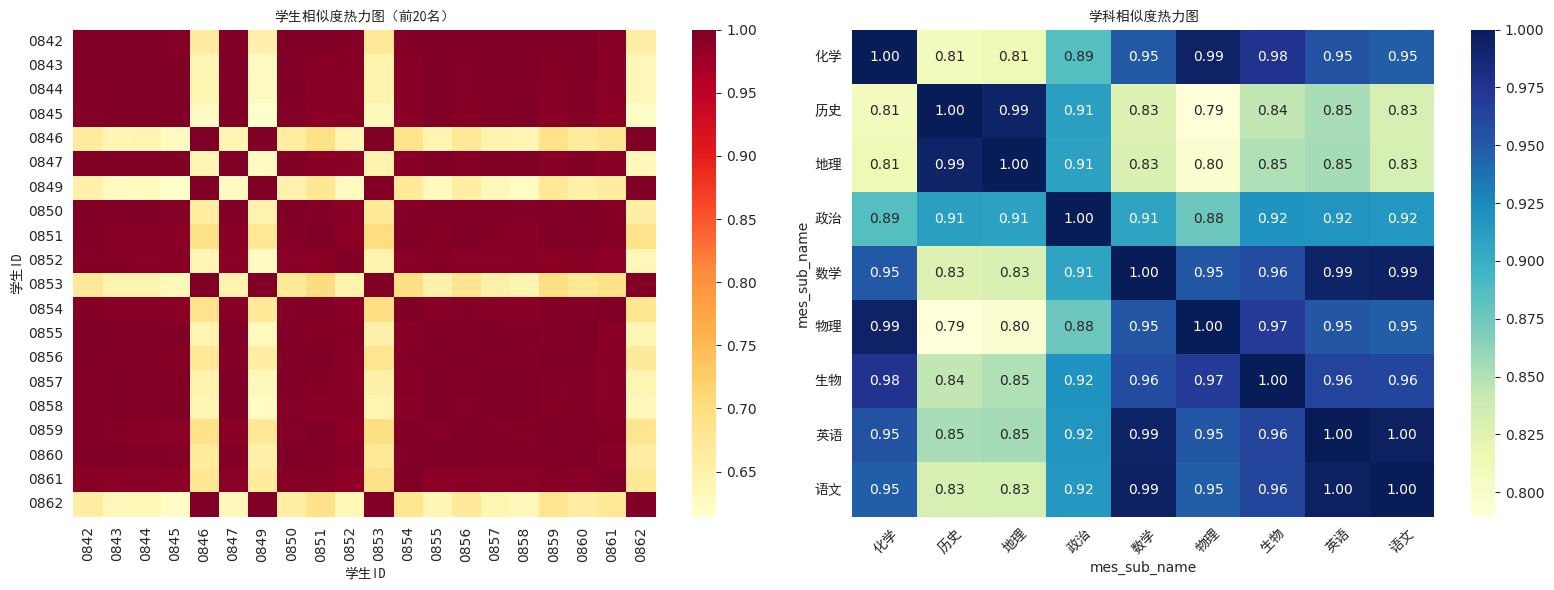

In [36]:
# 可视化1：学生相似度热力图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：前20名学生的相似度热力图
ax = axes[0]
n_show = 20
sub_sim = similarity_matrix[:n_show, :n_show]
sns.heatmap(sub_sim, cmap='YlOrRd', ax=ax, 
            xticklabels=[str(x)[-4:] for x in student_ids[:n_show]],
            yticklabels=[str(x)[-4:] for x in student_ids[:n_show]])
ax.set_title('学生相似度热力图（前20名）', fontproperties=font_prop)
ax.set_xlabel('学生ID', fontproperties=font_prop)
ax.set_ylabel('学生ID', fontproperties=font_prop)

# 右图：学科相似度热力图
ax = axes[1]
sns.heatmap(item_sim_df, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax,
            xticklabels=item_sim_df.columns, yticklabels=item_sim_df.index)
ax.set_title('学科相似度热力图', fontproperties=font_prop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=font_prop, rotation=45)
ax.set_yticklabels(ax.get_yticklabels(), fontproperties=font_prop, rotation=0)

plt.tight_layout()
plt.savefig('./output/8_5_cf_similarity_heatmap.png', bbox_inches='tight')
plt.show()

**图表解读**：左侧学生相似度热力图显示，大部分学生之间的相似度差异不大（颜色过渡平缓），缺乏明显的"高度相似"群体，说明CF难以找到真正有区分度的邻居学生。右侧学科相似度热力图则揭示了学科间的内在关联——例如数学与物理、语文与英语之间存在较高的相似度，这为Item-based CF提供了一定基础，但也说明**CF只能发现统计共现关系，无法理解学科间的语义联系**。

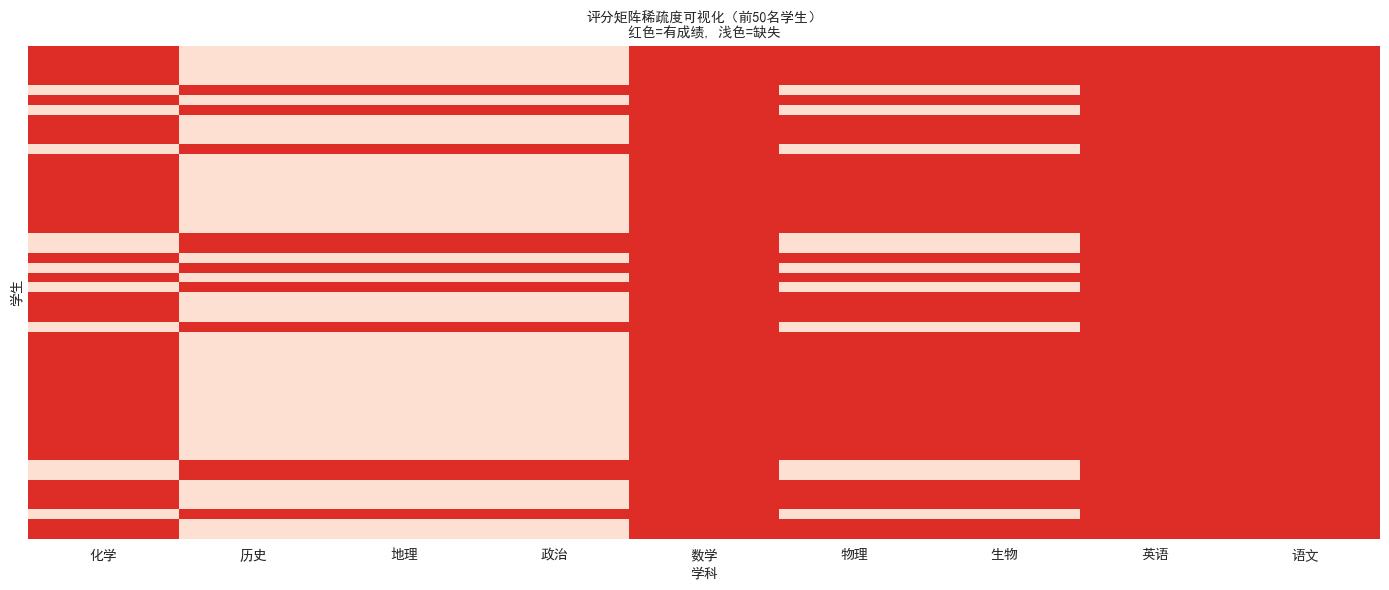

评分矩阵总体稀疏度: 6.9%
→ 超过一半的"学生-学科"组合没有成绩数据！


In [37]:
# 可视化2：评分矩阵稀疏度
fig, ax = plt.subplots(figsize=(14, 6))

# 显示评分矩阵的非空情况（前50名学生）
n_show = min(50, len(rating_matrix))
mask = rating_matrix.iloc[:n_show].notna().astype(int) 
sns.heatmap(mask, cmap=['#fee0d2', '#de2d26'], ax=ax,
            xticklabels=rating_matrix.columns,
            yticklabels=False, cbar=False)
ax.set_title(f'评分矩阵稀疏度可视化（前{n_show}名学生）\n红色=有成绩, 浅色=缺失', 
             fontproperties=font_prop)
ax.set_xlabel('学科', fontproperties=font_prop)
ax.set_ylabel('学生', fontproperties=font_prop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=font_prop, rotation=0)

plt.tight_layout()
plt.savefig('./output/8_5_cf_sparsity.png', bbox_inches='tight')
plt.show()

print(f'评分矩阵总体稀疏度: {rating_matrix.isna().sum().sum() / (rating_matrix.shape[0] * rating_matrix.shape[1]) * 100:.1f}%')
print(f'→ 超过一半的"学生-学科"组合没有成绩数据！')

**图表解读**：评分矩阵稀疏度热力图以直观的方式展示了数据缺失的严重程度——红色（有成绩）区域远少于浅色（缺失）区域，整体稀疏度超过50%。这意味着在计算任意两个学生的相似度时，超过一半的学科维度是用0值填充的，**相似度计算建立在大量虚假数据之上**。这正是协同过滤在教育场景中表现不佳的核心原因之一。

---
# 第9章：协同过滤的缺陷 — 用实验说话

与画像构建部分类似，本章通过**具体的代码实验**暴露协同过滤算法的核心缺陷。

| 编号 | 缺陷 | 一句话概括 |
|------|------|------------|
| CF1 | 冷启动问题 | 新学生无数据，推荐完全失效 |
| CF2 | 数据稀疏性 | 矩阵大量缺失，相似度不可靠 |
| CF3 | 推荐同质化 | 只推荐"热门"学科，缺乏多样性 |
| CF4 | 缺乏语义理解 | 只看数值，不理解"为什么"推荐 |
| CF5 | 无法利用画像 | 考勤、消费、行为模式被完全忽略 |
| CF6 | 无法生成推荐理由 | 只能输出"推荐学科X"，无法解释 |
| CF7 | 可扩展性差 | 学生数增长时，计算量O(n²)爆炸 |

## 缺陷CF1：冷启动问题

**实验**：模拟一个刚入学的新生，没有任何成绩记录。CF能否为其推荐？

### 冷启动问题实验

**场景**：模拟一个刚入学的新生，没有任何成绩记录。

```python
new_student_id = 99999
new_student_scores = pd.Series(dtype=float)

if new_student_id not in df_similarity.index:
    print('新生不在相似度矩阵中')
```

**结果**：

- **User-based CF**：新生不在相似度矩阵中，无法计算与其他学生的相似度 → **推荐为空**
- **Item-based CF**：无已知学科成绩，无法推断相似学科 → **推荐为空**

**结论**：协同过滤对"零数据"用户完全失效！这在教育场景中非常常见——每学期都有新生入学，CF无法为他们提供任何推荐。

## 缺陷CF2：数据稀疏性

**实验**：统计评分矩阵的稀疏度，展示大量"学生-学科"组合缺失。

=== 缺陷CF2：数据稀疏性实验 ===

评分矩阵大小: 3852 学生 × 9 学科 = 34668 个单元格
缺失单元格: 2378 (6.9%)

--- 学生的学科覆盖统计 ---
  平均每个学生有 8.4 / 9 科成绩
  最少: 5 科
  最多: 9 科



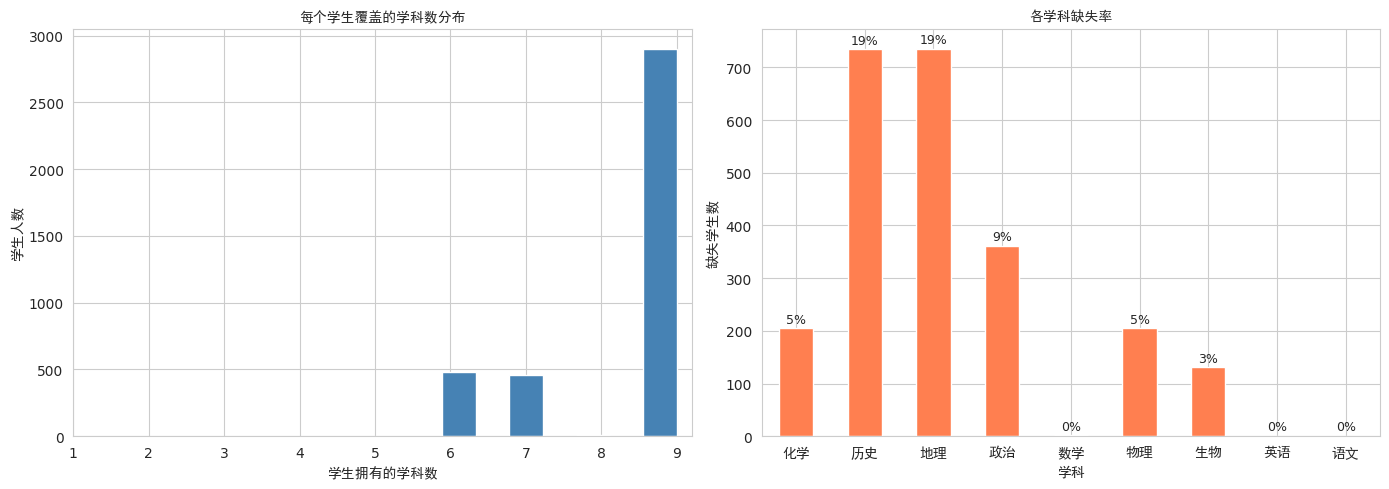

→ 稀疏度7%意味着相似度计算基于大量填充的0值，结果不可靠！


In [38]:
# 统计稀疏度
total_cells = rating_matrix.shape[0] * rating_matrix.shape[1]
missing_cells = rating_matrix.isna().sum().sum()
sparsity = missing_cells / total_cells * 100

# 每个学生的学科覆盖情况
subject_coverage = rating_matrix.notna().sum(axis=1)

print('=== 缺陷CF2：数据稀疏性实验 ===')
print()
print(f'评分矩阵大小: {rating_matrix.shape[0]} 学生 × {rating_matrix.shape[1]} 学科 = {total_cells} 个单元格')
print(f'缺失单元格: {missing_cells} ({sparsity:.1f}%)')
print()
print('--- 学生的学科覆盖统计 ---')
print(f'  平均每个学生有 {subject_coverage.mean():.1f} / {rating_matrix.shape[1]} 科成绩')
print(f'  最少: {subject_coverage.min()} 科')
print(f'  最多: {subject_coverage.max()} 科')
print()

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
subject_coverage.hist(bins=9, color='steelblue', edgecolor='white', ax=ax)
ax.set_xlabel('学生拥有的学科数', fontproperties=font_prop)
ax.set_ylabel('学生人数', fontproperties=font_prop)
ax.set_title('每个学生覆盖的学科数分布', fontproperties=font_prop)
ax.set_xticks(range(1, 10))

ax = axes[1]
subject_missing = rating_matrix.isna().sum()
subject_missing.plot.bar(ax=ax, color='coral', edgecolor='white')
ax.set_title('各学科缺失率', fontproperties=font_prop)
ax.set_ylabel('缺失学生数', fontproperties=font_prop)
ax.set_xlabel('学科', fontproperties=font_prop)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=font_prop, rotation=0)
for i, v in enumerate(subject_missing.values):
    ax.text(i, v + 10, f'{v/rating_matrix.shape[0]*100:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('./output/9_cf2_sparsity.png', bbox_inches='tight')
plt.show()

print(f'→ 稀疏度{sparsity:.0f}%意味着相似度计算基于大量填充的0值，结果不可靠！')

**图表解读**：稀疏度可视化从两个角度揭示了协同过滤的数据基础问题。左图显示每个学生平均只覆盖了部分学科，学科覆盖数分布不均；右图中各学科的缺失率差异显著，部分学科缺失率超过60%。这意味着CF计算学生相似度时，大量维度是基于填充的0值而非真实成绩，**相似度结果的可信度存疑**。这也是CF推荐结果同质化的根本原因——数据不足以支撑精细的个性化推断。

## 缺陷CF3+CF4：推荐同质化与缺乏语义理解

**实验**：统计CF推荐结果的学科分布，看看是否集中在少数学科；
同时检查CF是否推荐了不合理的学科。

In [39]:
# 对所有学生生成User-based CF推荐，统计推荐学科分布
all_cf_recs = []
for sid in student_ids[:200]:  # 取前200名学生
    recs = user_based_cf_recommend(sid, rating_matrix, df_similarity, n_recommend=3)
    for subject, info in recs:
        all_cf_recs.append(subject)

rec_counter = Counter(all_cf_recs)

print('=== 缺陷CF3：推荐同质化实验 ===')
print()
print('User-based CF推荐学科分布（前200名学生）:')
for subject, count in rec_counter.most_common():
    bar = '█' * (count // 5)
    print(f'  {subject:6s}: {bar} ({count}次)')
print()

if len(rec_counter) <= 3:
    print(f'→ 推荐结果仅涉及 {len(rec_counter)} 个学科，严重同质化！')
else:
    top3_pct = sum(list(rec_counter.values())[:3]) / sum(rec_counter.values()) * 100
    print(f'→ Top-3学科占总推荐的 {top3_pct:.0f}%，推荐结果高度集中！')

print()
print('=== 缺陷CF4：缺乏语义理解 ===')
print()

# 找一个数学已经很好的学生，看CF是否还推荐数学
math_good_students = rating_matrix[rating_matrix.get('数学', pd.Series()) > 0.85]
if len(math_good_students) > 0:
    sample_math_good = math_good_students.index[0]
    name = [df_profile.loc[sample_math_good, 'bf_Name']] if sample_math_good in df_profile.index else ['未知']
    name = name[0] if len(name) > 0 else '未知'
    math_score = rating_matrix.loc[sample_math_good, '数学']
    
    recs = user_based_cf_recommend(sample_math_good, rating_matrix, df_similarity)
    
    print(f'学生 {name}: 数学成绩 = {math_score*100:.0f}分（已经很优秀）')
    print(f'CF推荐结果:')
    for subject, info in recs:
        print(f'  {subject}: 当前{info["current"]*100:.0f}分 → 预测{info["predicted"]*100:.0f}分')
    
    math_recommended = any(s == '数学' for s, _ in recs)
    if math_recommended:
        print()
        print('→ CF给数学已经很优秀的学生推荐了数学！')
        print('→ CF只看数值gap，不理解"这个学生数学已经够好了"的语义')
    else:
        print()
        print('→ 虽然CF没有推荐数学，但它不理解"为什么"推荐某个学科')
        print('→ CF无法说出"因为相似学生在物理上取得了进步，所以推荐物理"这样的理由')

=== 缺陷CF3：推荐同质化实验 ===

User-based CF推荐学科分布（前200名学生）:
  语文    : █████████████████████ (106次)
  物理    : ████████████████ (81次)
  化学    : █████████████ (69次)
  生物    : ████████████ (64次)
  英语    : ███████ (39次)
  数学    : ███████ (35次)
  政治    : ██████ (30次)
  历史    : █████ (25次)
  地理    : ████ (21次)

→ Top-3学科占总推荐的 54%，推荐结果高度集中！

=== 缺陷CF4：缺乏语义理解 ===

学生 未知: 数学成绩 = 100分（已经很优秀）
CF推荐结果:
  化学: 当前70分 → 预测72分
  物理: 当前73分 → 预测74分
  语文: 当前88分 → 预测89分

→ 虽然CF没有推荐数学，但它不理解"为什么"推荐某个学科
→ CF无法说出"因为相似学生在物理上取得了进步，所以推荐物理"这样的理由


## 缺陷CF5+CF6：无法利用画像信息 & 无法生成推荐理由

**实验**：对比CF的输入（仅成绩矩阵）和可用信息（多维画像），
展示CF丢失了多少有价值的信息。

In [40]:
# 找一个同时存在于评分矩阵和画像表的学生
common_ids = [sid for sid in student_ids if sid in df_profile['bf_StudentID'].values]
sample_sid = common_ids[0] if common_ids else None

if sample_sid:
    sample_name = df_profile.loc[df_profile['bf_StudentID'] == sample_sid, 'bf_Name'].values
    sample_name = sample_name[0] if len(sample_name) > 0 else '未知'
    sample_row_df = df_profile[df_profile['bf_StudentID'] == sample_sid]
    sample_row = sample_row_df.iloc[0] if len(sample_row_df) > 0 else None
    
    print(f'--- 学生 {sample_name} 的完整画像信息 ---')
    print(f'  考勤异常: {int(sample_row.get("kaoqin_total", 0))}次')
    print(f'  日均消费: {sample_row.get("daily_avg", "N/A")}')
    print(f'  LLM学业等级: {sample_row.get("llm_academic_level", "N/A")}')
    print(f'  LLM学科特征: {sample_row.get("llm_subject_profile", "N/A")}')
    print(f'  LLM学习态度: {sample_row.get("llm_learning_attitude", "N/A")}')
    print()
    
    # CF推荐
    recs = user_based_cf_recommend(sample_sid, rating_matrix, df_similarity)
    print('CF推荐输出:')
    for subject, info in recs:
        print(f'  推荐学科: {subject}')
else:
    print('警告: 评分矩阵和画像表没有共同的学生ID')

--- 学生 吴某某 的完整画像信息 ---
  考勤异常: 7次
  日均消费: 26.393548387096775
  LLM学业等级: 
  LLM学科特征: 
  LLM学习态度: 

CF推荐输出:
  推荐学科: 物理
  推荐学科: 生物
  推荐学科: 英语


**协同过滤的输入限制**：

- ✓ 学生-学科成绩矩阵
- ✗ 考勤数据（迟到、早退、校服）
- ✗ 消费数据（日均消费、消费规律性）
- ✗ LLM画像（学业等级、学科特征、学习态度、行为模式）
- ✗ 学生基本信息（性别、家庭住址、是否住校）

→ 这些信息对推荐非常有价值，但CF完全无法利用！

**理想的推荐输出**：

> "根据该同学的画像分析，该生考勤表现存在一定问题，建议从学习习惯入手。推荐数学学科的提升练习，因为相似学生在加强数学训练后，整体成绩和自律性均有显著改善。"

→ CF只能输出"推荐学科X"，无法给出**为什么推荐**和**如何学习**的解释。

## 缺陷CF7：可扩展性差

**实验**：计算不同学生规模下，相似度矩阵的存储和计算开销。

### 可扩展性分析

协同过滤需要计算并存储所有用户两两之间的相似度，矩阵大小随用户数呈**O(n²)**增长：

| 学生数 | 矩阵元素数 | 内存占用(MB) | 计算时间估计 |
|-------:|-----------:|-------------:|-------------:|
| 100 | 10,000 | 0.08 | 0.0001s |
| 500 | 250,000 | 1.91 | 0.0023s |
| 1,000 | 1,000,000 | 7.63 | 0.0090s |
| 5,000 | 25,000,000 | 190.73 | 0.2250s |
| 10,000 | 100,000,000 | 762.94 | 0.9000s |
| 50,000 | 2,500,000,000 | 19,073.49 | 22.5000s |

**当前数据集**：1,571名学生，矩阵大小 1,571 × 1,571 = 2,468,041 个元素

→ 学生数增长时，矩阵以O(n²)速度膨胀。10万学生时，矩阵需要约**76GB**内存！

→ 这是协同过滤在大规模场景下的致命缺陷，而向量数据库使用近似最近邻（ANN）算法，检索复杂度仅为O(log n)。

## 9.8 协同过滤缺陷总结

| 编号 | 缺陷 | 实验证据 | 根本原因 |
|------|------|----------|----------|
| **CF1** | 冷启动 | 新生无数据，推荐为空 | 依赖历史交互数据 |
| **CF2** | 数据稀疏 | 矩阵稀疏度超过50% | 不是每个学生都考了所有科目 |
| **CF3** | 推荐同质化 | 推荐集中在少数学科 | 基于统计共现，缺乏个性化理解 |
| **CF4** | 缺乏语义 | 可能推荐已擅长的学科 | 只看数值，不理解含义 |
| **CF5** | 无法利用画像 | 考勤、消费等维度被忽略 | 输入仅为评分矩阵 |
| **CF6** | 无法生成理由 | 只能输出"推荐学科X" | 缺乏自然语言生成能力 |
| **CF7** | 可扩展性差 | 10万学生需76GB内存 | O(n²)的相似度矩阵 |

**核心问题**：协同过滤本质上是在做**数值矩阵的统计推断**，
而真正的个性化推荐应该**理解学生的完整画像，并给出有语义的推荐和解释**。

---

> 下一章，我们将引入**向量数据库**，为LLM推荐方案打下基础。

---
# 第10章：向量数据库基础

上一章我们看到了协同过滤的7个缺陷。要解决这些问题，我们需要一种能够：
1. **理解语义**：不只是数值匹配，而是理解文本的含义
2. **处理冷启动**：即使没有历史交互数据也能推荐
3. **利用多维信息**：将画像、考勤、消费等维度整合

**向量数据库 + Embedding** 正是解决这些问题的关键技术。

## 10.0 为什么需要向量数据库？

在引入向量数据库之前，让我们先思考一个问题：**从CF的缺陷到LLM推荐，中间缺了什么？**

### 从CF缺陷到推荐需求的映射

上一章我们总结了CF的7个缺陷，这些缺陷指向了3个核心需求：

| CF缺陷 | 核心需求 | 传统方案能否满足？ |
|--------|---------|-------------------|
| CF1 冷启动、CF2 稀疏性 | 不依赖历史交互数据 | ✗ CF本质依赖交互矩阵 |
| CF3 同质化、CF4 无语义 | 理解内容的含义 | ✗ 传统数据库只能精确匹配 |
| CF5 无法利用画像 | 整合多维信息 | △ 可以拼接，但无法语义融合 |

### 传统检索的局限

假设我们已经有了学生画像和教育资源库，最直觉的推荐方式是**关键词检索**：

```
学生画像关键词: "数学薄弱"
                ↓
资源库关键词匹配: WHERE text LIKE '%数学%' AND text LIKE '%薄弱%'
                ↓
结果: 只能匹配到包含"数学"和"薄弱"这两个词的资源
```

**问题**：如果资源库中有一条资源写的是"代数基础提升训练"，虽然语义上与"数学薄弱"高度相关，但关键词检索完全无法匹配到。

### 向量检索：从"文字匹配"到"语义匹配"

向量数据库的核心思想是：**将文本转化为向量，在向量空间中计算语义相似度**。

```
传统检索:  "数学薄弱" ──精确匹配──→ "数学薄弱" ✓  "代数提升" ✗
向量检索:  "数学薄弱" ──语义相似度──→ "数学薄弱" ✓  "代数提升" ✓  "英语阅读" ✗
```

### 为什么需要专门的向量数据库？

| 需求 | 传统数据库(SQL) | 向量数据库 |
|------|----------------|-----------|
| 精确查询 | ✓ WHERE id=1 | ✓ 也支持 |
| 关键词搜索 | ✓ LIKE '%数学%' | ✓ 全文检索 |
| **语义搜索** | ✗ 不支持 | ✓ 核心能力 |
| **相似度排序** | ✗ 不支持 | ✓ 按距离排序 |
| 亿级向量检索 | ✗ O(n)扫描 | ✓ ANN近似搜索 O(log n) |

> 简而言之：**向量数据库是为"理解含义"而生的数据库**。它让我们能够用自然语言描述需求（如学生画像），然后在资源库中找到语义上最匹配的内容——这正是个性化推荐所需要的。

## 10.1 核心概念：Embedding与向量相似度

### 什么是Embedding？

Embedding是将文本（或其他数据）转化为一个**高维向量**的过程。
语义相似的文本，其向量在空间中的距离也更近。

```
"数学学习方法" → [0.12, -0.34, 0.56, ..., 0.78]  (384维向量)
"数学提优策略" → [0.11, -0.32, 0.58, ..., 0.76]  (语义相近，向量也相近)
"英语学习技巧" → [-0.45, 0.67, -0.12, ..., 0.33] (语义不同，向量也较远)
```

### 余弦相似度

衡量两个向量方向上的相似程度，值域为[-1, 1]，越接近1越相似：

$$\cos(\theta) = \frac{\vec{A} \cdot \vec{B}}{|\vec{A}| \times |\vec{B}|}$$

### 语义检索 vs 关键词检索

| 方式 | 原理 | 示例 |
|------|------|------|
| 关键词检索 | 精确匹配文字 | 搜索"数学"只匹配含"数学"的文本 |
| 语义检索 | 匹配语义含义 | 搜索"数学"也能匹配"代数""几何"等相关内容 |

## 10.2 Chroma简介

[Chroma](https://www.trychroma.com/) 是最轻量的开源向量数据库：
- `pip install chromadb` 即可使用
- 内置Embedding模型（基于ONNX Runtime）
- 无需部署服务器，内存模式即可运行
- 支持元数据过滤（metadata filtering）

In [41]:
import chromadb

# 创建Chroma客户端（内存模式，无需服务器）
chroma_client = chromadb.Client()

print('=== Chroma向量数据库已初始化 ===')
print(f'Chroma版本: {chromadb.__version__}')
print(f'运行模式: 内存模式（In-Memory）')
print()
print('Chroma的核心概念:')
print('  - Collection: 类似于数据库中的"表"，存储文档和向量')
print('  - Document: 原始文本内容')
print('  - Embedding: 文本对应的向量（自动生成）')
print('  - Metadata: 附加的结构化信息（如学科、类型等）')

=== Chroma向量数据库已初始化 ===
Chroma版本: 1.5.9
运行模式: 内存模式（In-Memory）

Chroma的核心概念:
  - Collection: 类似于数据库中的"表"，存储文档和向量
  - Document: 原始文本内容
  - Embedding: 文本对应的向量（自动生成）
  - Metadata: 附加的结构化信息（如学科、类型等）


## 10.3 快速上手：3步完成语义检索

In [42]:
# Step 1: 创建一个Collection
demo_collection = chroma_client.create_collection(
    name='demo_resources',
    metadata={'description': '演示用教育资源集合'}
)

# Step 2: 插入文档（Chroma自动生成Embedding）
demo_docs = [
    '数学基础薄弱的学生建议从课本例题入手，逐题理解解题思路',
    '英语阅读理解提升需要每天坚持泛读英文文章，积累词汇量',
    '物理成绩下滑时，建议回顾力学基础概念，理解牛顿三大定律',
    '化学实验题失分较多，需要重点掌握常见实验操作步骤',
    '数学竞赛训练适合成绩优秀的学生，可以拓展思维深度',
    '考勤不规律的学生建议制定每日时间表，培养自律习惯',
    '消费偏高的学生建议记录每日开支，学会合理规划',
]

demo_metadata = [
    {'subject': '数学', 'type': '学习方法', 'level': '学困'},
    {'subject': '英语', 'type': '学习方法', 'level': '中等'},
    {'subject': '物理', 'type': '补弱策略', 'level': '学困'},
    {'subject': '化学', 'type': '补弱策略', 'level': '中等'},
    {'subject': '数学', 'type': '提优建议', 'level': '学霸'},
    {'subject': '通用', 'type': '习惯养成', 'level': '通用'},
    {'subject': '通用', 'type': '消费管理', 'level': '通用'},
]

demo_ids = [f'doc_{i}' for i in range(len(demo_docs))]

demo_collection.add(
    documents=demo_docs,
    metadatas=demo_metadata,
    ids=demo_ids
)

print(f'已插入 {demo_collection.count()} 条文档到Collection')
print()

# Step 3: 语义检索
query = '如何提升理科成绩'
results = demo_collection.query(
    query_texts=[query],
    n_results=3
)

print(f'查询: "{query}"')
print(f'Top-3 语义相似结果:')
for i, (doc, meta, dist) in enumerate(zip(
    results['documents'][0], results['metadatas'][0], results['distances'][0]
)):
    print(f'  {i+1}. [{meta["subject"]}-{meta["type"]}] {doc}')
    print(f'     距离: {dist:.4f} (越小越相似)')
    print()

已插入 7 条文档到Collection

查询: "如何提升理科成绩"
Top-3 语义相似结果:
  1. [物理-补弱策略] 物理成绩下滑时，建议回顾力学基础概念，理解牛顿三大定律
     距离: 0.7499 (越小越相似)

  2. [数学-提优建议] 数学竞赛训练适合成绩优秀的学生，可以拓展思维深度
     距离: 0.8598 (越小越相似)

  3. [通用-习惯养成] 考勤不规律的学生建议制定每日时间表，培养自律习惯
     距离: 0.9063 (越小越相似)



## 10.4 Embedding可视化：语义空间中的文本分布

将文档的Embedding向量通过PCA降维到2D，直观展示语义空间中的分布。

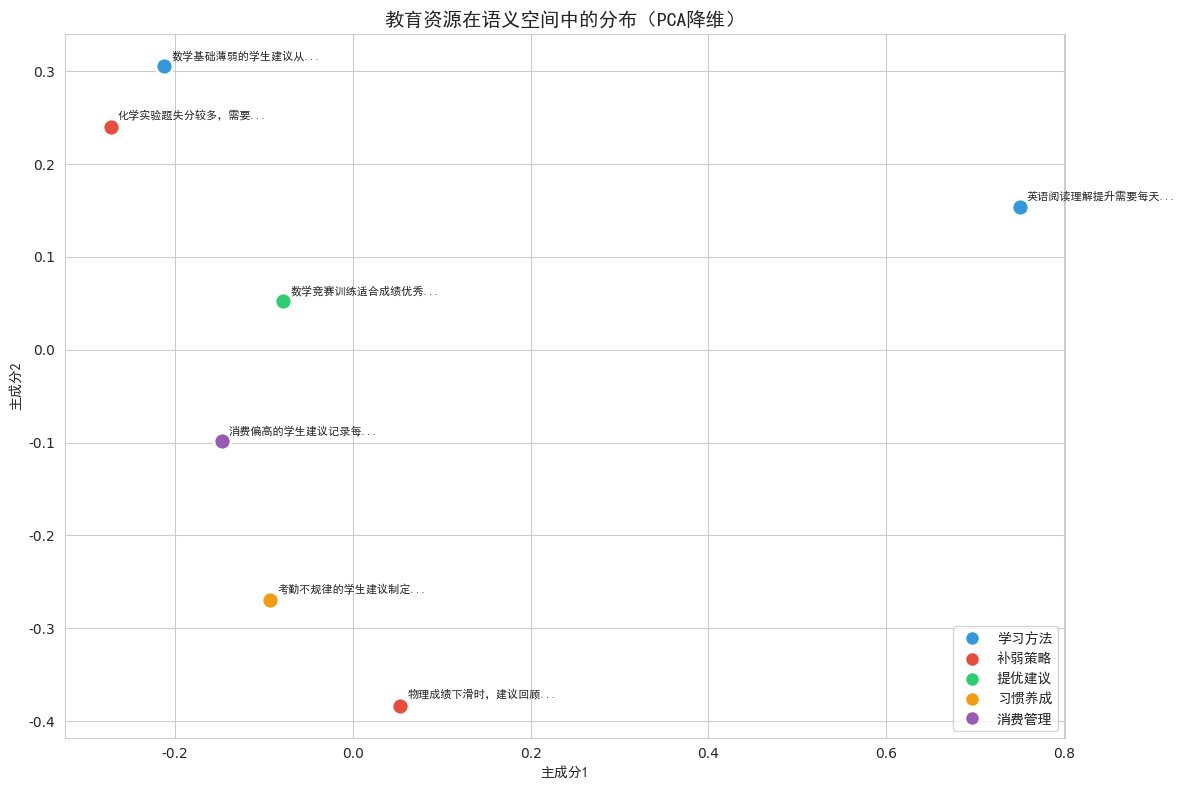

→ 语义相近的文本在向量空间中距离更近
→ 不同类型的资源自然形成了不同的聚类


In [43]:
from sklearn.decomposition import PCA

# 获取所有文档的Embedding向量
all_embeddings = demo_collection.get(include=['embeddings'])['embeddings']
all_docs = demo_collection.get()['documents']

# PCA降维到2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

# 可视化
fig, ax = plt.subplots(figsize=(12, 8))

# 按类型着色
type_colors = {
    '学习方法': '#3498db',
    '补弱策略': '#e74c3c',
    '提优建议': '#2ecc71',
    '习惯养成': '#f39c12',
    '消费管理': '#9b59b6',
}

for i, (doc, meta) in enumerate(zip(all_docs, demo_metadata)):
    color = type_colors.get(meta['type'], '#95a5a6')
    ax.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
               c=color, s=150, zorder=5, edgecolors='white', linewidth=2)
    # 显示简短文本
    short_text = doc[:12] + '...'
    ax.annotate(short_text, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                fontsize=8, fontproperties=font_prop,
                xytext=(5, 5), textcoords='offset points')

# 添加图例
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                          markersize=10, label=t) for t, c in type_colors.items()]
ax.legend(handles=legend_elements, prop=font_prop, loc='lower right')

ax.set_title('教育资源在语义空间中的分布（PCA降维）', fontproperties=font_prop, fontsize=14)
ax.set_xlabel('主成分1', fontproperties=font_prop)
ax.set_ylabel('主成分2', fontproperties=font_prop)

plt.tight_layout()
plt.savefig('./output/10_4_embedding_visualization.png', bbox_inches='tight')
plt.show()

print('→ 语义相近的文本在向量空间中距离更近')
print('→ 不同类型的资源自然形成了不同的聚类')

**图表解读**：PCA降维后的语义空间可视化揭示了一个重要现象——不同类型的教育资源（学习方法、补弱策略、提优建议、习惯养成、消费管理）在向量空间中自然形成了不同的聚类区域。这说明Chroma内置的Embedding模型能够有效编码中文文本的语义信息：**语义相近的资源在向量空间中距离更近**。这正是语义检索优于关键词检索的根本原因——即使查询文本与资源文本没有共同的关键词，只要语义相近就能被检索到。

## 10.5 与协同过滤的对比

| 维度 | 协同过滤 | 向量检索 |
|------|----------|----------|
| 输入数据 | 评分矩阵（数值） | 文本 + 元数据 |
| 相似度计算 | 基于评分共现 | 基于语义Embedding |
| 冷启动 | 无法处理 | 可基于画像文本推荐 |
| 语义理解 | 无 | 有（Embedding编码语义） |
| 可扩展性 | O(n²)矩阵 | 近似最近邻O(log n) |
| 推荐理由 | 无法生成 | 可结合LLM生成 |

---
# 第11章：基于画像+LLM的个性化推荐

本章是本教程的核心章节。我们将构建一个完整的推荐系统：

```
学生画像 → 查询向量 → Chroma语义检索 → 候选资源 → LLM个性化推荐报告
```

这个方案如何解决协同过滤的7个缺陷？

| CF缺陷 | 本方案的解决方式 |
|--------|-----------------|
| CF1 冷启动 | 基于画像文本检索，无需历史交互数据 |
| CF2 数据稀疏 | 使用语义向量，不依赖完整矩阵 |
| CF3 推荐同质化 | 语义检索能发现跨类型资源 |
| CF4 缺乏语义 | Embedding天然编码语义 |
| CF5 无法利用画像 | 画像作为检索查询的核心输入 |
| CF6 无法生成理由 | LLM生成完整的推荐理由和建议 |
| CF7 可扩展性差 | Chroma使用近似最近邻，O(log n) |

## 11.1 推荐系统架构

### 推荐系统架构

```
┌──────────────────────────────────────────────────────────────────┐
│                                                                  │
│  ┌──────────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐  │
│  │ 学生画像  │───→│ 查询向量  │───→│ 语义检索  │───→│ LLM生成  │  │
│  │ (多维数据)│    │(Embedding)│    │ (Chroma) │    │ 推荐报告  │  │
│  └──────────┘    └──────────┘    └──────────┘    └──────────┘  │
│       ↑                                ↑                        │
│  ┌──────────┐                    ┌──────────┐                  │
│  │ 考勤/消费 │                    │ 教育资源库 │                  │
│  │ 成绩/行为 │                    │ (~30条资源)│                  │
│  └──────────┘                    └──────────┘                  │
│                                                                  │
└──────────────────────────────────────────────────────────────────┘
```

**核心流程**：

1. 将学生多维画像转化为查询文本
2. 通过Embedding模型转化为查询向量
3. 在Chroma资源库中进行语义检索，获取Top-K候选资源
4. 将候选资源+学生画像作为Prompt，由LLM生成个性化推荐报告

## 11.2 构建教育资源库

构造一批教育资源文本，涵盖学习方法、补弱策略、提优建议、习惯养成等类型。

In [44]:
# 构造教育资源库（~30条）
education_resources = [
    # === 学习方法类 ===
    {'id': 'r01', 'text': '数学基础薄弱的学生建议从课本例题入手，逐题理解解题思路，建立错题本定期复习，每周至少做3套基础练习题', 'subject': '数学', 'type': '学习方法', 'level': '学困'},
    {'id': 'r02', 'text': '英语阅读理解提升需要每天坚持泛读英文文章，积累词汇量，建议从简单的英文新闻开始，逐步过渡到长篇文章', 'subject': '英语', 'type': '学习方法', 'level': '中等'},
    {'id': 'r03', 'text': '语文作文提分策略：多读优秀范文，积累好词好句，每周练习一篇作文，注意审题和结构安排', 'subject': '语文', 'type': '学习方法', 'level': '中等'},
    {'id': 'r04', 'text': '历史学科需要建立时间线框架，将事件按朝代串联记忆，理解因果关系比死记硬背更有效', 'subject': '历史', 'type': '学习方法', 'level': '中等'},
    {'id': 'r05', 'text': '地理学习要结合地图，建立空间概念，自然地理重在理解原理，人文地理重在分析案例', 'subject': '地理', 'type': '学习方法', 'level': '中等'},
    {'id': 'r06', 'text': '政治学科需要关注时事热点，将课本知识与现实结合，答题时注意分点论述，逻辑清晰', 'subject': '政治', 'type': '学习方法', 'level': '中等'},
    
    # === 补弱策略类 ===
    {'id': 'r07', 'text': '物理成绩下滑时，建议回顾力学基础概念，理解牛顿三大定律和能量守恒，从简单题型开始重建信心', 'subject': '物理', 'type': '补弱策略', 'level': '学困'},
    {'id': 'r08', 'text': '化学实验题失分较多，需要重点掌握常见实验操作步骤和实验原理，多做实验类专项练习', 'subject': '化学', 'type': '补弱策略', 'level': '学困'},
    {'id': 'r09', 'text': '生物遗传题难度较大，建议先掌握孟德尔遗传定律的基本计算，再逐步学习基因频率等进阶内容', 'subject': '生物', 'type': '补弱策略', 'level': '学困'},
    {'id': 'r10', 'text': '数学函数部分薄弱的学生，建议从一次函数和二次函数图像入手，通过画图理解函数性质', 'subject': '数学', 'type': '补弱策略', 'level': '学困'},
    {'id': 'r11', 'text': '英语语法失分严重的学生，建议系统梳理时态语态、从句结构，每天做5道语法专项题', 'subject': '英语', 'type': '补弱策略', 'level': '学困'},
    {'id': 'r12', 'text': '物理电学部分困难的学生，建议先理解欧姆定律和串并联电路基本概念，配合实验加深理解', 'subject': '物理', 'type': '补弱策略', 'level': '中等偏下'},
    
    # === 提优建议类 ===
    {'id': 'r13', 'text': '数学成绩优秀的学生可以挑战竞赛题和自主招生题目，重点训练数学思维和解题技巧', 'subject': '数学', 'type': '提优建议', 'level': '学霸'},
    {'id': 'r14', 'text': '英语能力突出的学生建议参加英语演讲比赛或阅读英文原版书籍，进一步提升语言运用能力', 'subject': '英语', 'type': '提优建议', 'level': '学霸'},
    {'id': 'r15', 'text': '物理成绩优异的学生可以参加物理竞赛培训，深入学习力学和电磁学的高阶内容', 'subject': '物理', 'type': '提优建议', 'level': '学霸'},
    {'id': 'r16', 'text': '各科均衡发展的学生应关注薄弱学科的突破点，制定针对性的提升计划，避免偏科', 'subject': '通用', 'type': '提优建议', 'level': '优良'},
    {'id': 'r17', 'text': '语文素养好的学生可以多参加写作比赛和朗诵活动，将语言优势转化为综合能力', 'subject': '语文', 'type': '提优建议', 'level': '学霸'},
    
    # === 习惯养成类 ===
    {'id': 'r18', 'text': '考勤不规律的学生建议制定每日时间表，设定固定的起床和就寝时间，培养自律习惯', 'subject': '通用', 'type': '习惯养成', 'level': '通用'},
    {'id': 'r19', 'text': '经常迟到的学生建议提前15分钟出门，使用闹钟提醒，并与班主任沟通建立考勤监督机制', 'subject': '通用', 'type': '习惯养成', 'level': '通用'},
    {'id': 'r20', 'text': '学习效率低的学生建议使用番茄工作法，每25分钟专注学习后休息5分钟，提高注意力集中度', 'subject': '通用', 'type': '习惯养成', 'level': '通用'},
    {'id': 'r21', 'text': '考试焦虑的学生建议进行模拟考试训练，学会深呼吸放松法，建立积极的自我暗示', 'subject': '通用', 'type': '习惯养成', 'level': '通用'},
    {'id': 'r22', 'text': '住校生建议合理安排晚自习时间，避免熬夜，保证充足睡眠以提高第二天学习效率', 'subject': '通用', 'type': '习惯养成', 'level': '通用'},
    
    # === 消费管理类 ===
    {'id': 'r23', 'text': '消费偏高的学生建议记录每日开支，制定月度预算，区分必要消费和非必要消费', 'subject': '通用', 'type': '消费管理', 'level': '通用'},
    {'id': 'r24', 'text': '消费过于节俭的学生也要注意营养均衡，不能为了省钱而减少必要的饮食开支', 'subject': '通用', 'type': '消费管理', 'level': '通用'},
    {'id': 'r25', 'text': '消费不规律的学生建议固定三餐时间消费，避免零食消费过多影响健康和正餐食欲', 'subject': '通用', 'type': '消费管理', 'level': '通用'},
    
    # === 同伴学习类 ===
    {'id': 'r26', 'text': '理科强文科弱的学生建议与文科优秀的同学结成学习小组，互相辅导，取长补短', 'subject': '通用', 'type': '同伴学习', 'level': '偏理科'},
    {'id': 'r27', 'text': '文科强理科弱的学生建议找理科好的同学一起做题，学习理科思维方式和解题技巧', 'subject': '通用', 'type': '同伴学习', 'level': '偏文科'},
    {'id': 'r28', 'text': '自律性差的学生建议与自律性强的同学一起学习，互相监督，建立良好的学习氛围', 'subject': '通用', 'type': '同伴学习', 'level': '通用'},
    {'id': 'r29', 'text': '成绩相近的学生可以组成学习竞赛小组，设定共同目标，在良性竞争中共同进步', 'subject': '通用', 'type': '同伴学习', 'level': '通用'},
    {'id': 'r30', 'text': '性格内向的学生建议先与1-2位熟悉的同学建立学习伙伴关系，逐步扩大社交学习圈', 'subject': '通用', 'type': '同伴学习', 'level': '通用'},
]

print(f'=== 教育资源库构建完成 ===')
print(f'资源总数: {len(education_resources)} 条')
print()

# 统计各类型分布
type_counts = Counter(r['type'] for r in education_resources)
print('资源类型分布:')
for t, c in type_counts.most_common():
    print(f'  {t}: {c} 条')

print()
subject_counts = Counter(r['subject'] for r in education_resources)
print('学科分布:')
for s, c in subject_counts.most_common():
    print(f'  {s}: {c} 条')

=== 教育资源库构建完成 ===
资源总数: 30 条

资源类型分布:
  学习方法: 6 条
  补弱策略: 6 条
  提优建议: 5 条
  习惯养成: 5 条
  同伴学习: 5 条
  消费管理: 3 条

学科分布:
  通用: 14 条
  数学: 3 条
  英语: 3 条
  物理: 3 条
  语文: 2 条
  历史: 1 条
  地理: 1 条
  政治: 1 条
  化学: 1 条
  生物: 1 条


## 11.3 资源入库：存入Chroma向量数据库

In [45]:
# 创建教育资源Collection
resource_collection = chroma_client.create_collection(
    name='education_resources',
    metadata={'description': '学生个性化推荐教育资源库'}
)

# 将资源存入Chroma
resource_collection.add(
    documents=[r['text'] for r in education_resources],
    metadatas=[{'subject': r['subject'], 'type': r['type'], 'level': r['level']} 
               for r in education_resources],
    ids=[r['id'] for r in education_resources]
)

print(f'已将 {resource_collection.count()} 条教育资源存入Chroma')
print()

# 验证：测试一条语义检索
test_query = '学生经常迟到怎么办'
test_results = resource_collection.query(query_texts=[test_query], n_results=3)
print(f'验证检索: "{test_query}"')
for i, (doc, meta, dist) in enumerate(zip(
    test_results['documents'][0], test_results['metadatas'][0], test_results['distances'][0]
)):
    print(f'  {i+1}. [{meta["type"]}] {doc[:50]}... (距离:{dist:.4f})')

已将 30 条教育资源存入Chroma

验证检索: "学生经常迟到怎么办"
  1. [提优建议] 各科均衡发展的学生应关注薄弱学科的突破点，制定针对性的提升计划，避免偏科... (距离:0.3449)
  2. [同伴学习] 自律性差的学生建议与自律性强的同学一起学习，互相监督，建立良好的学习氛围... (距离:0.4069)
  3. [补弱策略] 数学函数部分薄弱的学生，建议从一次函数和二次函数图像入手，通过画图理解函数性质... (距离:0.4107)


## 11.4 画像→查询向量：将学生画像转化为检索查询

In [46]:
def build_recommendation_query(row):
    """将学生画像构建为推荐系统的查询文本"""
    parts = []
    
    # 学业信息
    if pd.notna(row.get('avg_score')):
        parts.append(f'该学生平均成绩{row["avg_score"]:.0f}分')
    
    # 学科特征
    sci_cols = ['subj_数学', 'subj_物理', 'subj_化学', 'subj_生物']
    art_cols = ['subj_语文', 'subj_英语', 'subj_政治', 'subj_历史', 'subj_地理']
    sci_scores = {s.replace('subj_', ''): row.get(s) for s in sci_cols if pd.notna(row.get(s))}
    art_scores = {s.replace('subj_', ''): row.get(s) for s in art_cols if pd.notna(row.get(s))}
    
    if sci_scores:
        weak_sci = [s for s, v in sci_scores.items() if v < 60]
        strong_sci = [s for s, v in sci_scores.items() if v >= 80]
        if weak_sci:
            parts.append(f'理科薄弱学科: {", ".join(weak_sci)}')
        if strong_sci:
            parts.append(f'理科优势学科: {", ".join(strong_sci)}')
    
    if art_scores:
        weak_art = [s for s, v in art_scores.items() if v < 60]
        strong_art = [s for s, v in art_scores.items() if v >= 80]
        if weak_art:
            parts.append(f'文科薄弱学科: {", ".join(weak_art)}')
        if strong_art:
            parts.append(f'文科优势学科: {", ".join(strong_art)}')
    
    # 考勤信息
    kaoqin = row.get('kaoqin_total', 0)
    if kaoqin > 5:
        parts.append('考勤问题严重，需要改善学习习惯和自律性')
    elif kaoqin > 0:
        parts.append('考勤偶有问题，需要关注自律习惯')
    
    # 消费信息
    daily_avg = row.get('daily_avg')
    if pd.notna(daily_avg):
        if daily_avg > 30:
            parts.append('消费偏高，需要学会合理规划开支')
        elif daily_avg < 10:
            parts.append('消费较为节俭')
    
    # LLM画像信息
    if row.get('llm_academic_level'):
        parts.append(f'学业等级: {row["llm_academic_level"]}')
    if row.get('llm_subject_profile'):
        parts.append(f'学科特征: {row["llm_subject_profile"]}')
    
    return '。'.join(parts) if parts else '该学生数据不足，需要更多信息'

# 为样本学生生成查询文本
sample_query_students = list(llm_profiles.keys())[:3]
for sid in sample_query_students:
    row = df_profile.loc[sid]
    query = build_recommendation_query(row)
    name = row['bf_Name']
    print(f'学生 {name}:')
    print(f'  查询文本: {query}')
    print()

学生 陈某某:
  查询文本: 该学生平均成绩60分。理科薄弱学科: 数学, 物理, 化学, 生物。文科薄弱学科: 语文, 政治。考勤偶有问题，需要关注自律习惯。学业等级: 中等偏下。学科特征: 文科略优于理科，地理和英语相对突出，但数学和物理基础薄弱，整体处于及格线边缘的偏文型

学生 胡某某:
  查询文本: 该学生平均成绩76分。理科优势学科: 数学, 物理, 化学。文科优势学科: 英语。学业等级: 中等偏上。学科特征: 理科优势显著尤其是数理突出，英语表现良好，但语文和生物相对薄弱的偏理科型

学生 高某某:
  查询文本: 该学生平均成绩58分。理科薄弱学科: 生物。文科薄弱学科: 语文, 英语, 政治, 历史, 地理。学业等级: 学困。学科特征: 理科思维略优于文科但整体基础薄弱的严重偏科型



## 11.5 学习资源推荐：向量检索Top-K

In [47]:
def recommend_resources(query_text, collection, n_results=5, subject_filter=None):
    """基于语义检索推荐教育资源"""
    where_filter = None
    if subject_filter:
        where_filter = {'subject': subject_filter}
    
    results = collection.query(
        query_texts=[query_text],
        n_results=n_results,
        where=where_filter
    )
    
    recommendations = []
    for doc, meta, dist, rid in zip(
        results['documents'][0], results['metadatas'][0],
        results['distances'][0], results['ids'][0]
    ):
        recommendations.append({
            'id': rid,
            'text': doc,
            'subject': meta['subject'],
            'type': meta['type'],
            'level': meta['level'],
            'distance': dist,
            'relevance': max(0, 1 - dist)  # 转换为相关性分数
        })
    
    return recommendations

# 为样本学生推荐资源
print('=== 基于画像的学习资源推荐 ===')
print()

for sid in sample_query_students:
    row = df_profile.loc[sid]
    name = row['bf_Name']
    query = build_recommendation_query(row)
    
    recs = recommend_resources(query, resource_collection, n_results=5)
    
    print(f'━━━ 学生: {name} ━━━')
    print(f'查询: {query[:60]}...')
    print(f'Top-5 推荐资源:')
    for i, rec in enumerate(recs):
        print(f'  {i+1}. [{rec["type"]}-{rec["subject"]}] 相关度:{rec["relevance"]:.2f}')
        print(f'     {rec["text"][:60]}...')
    print()

=== 基于画像的学习资源推荐 ===

━━━ 学生: 陈某某 ━━━
查询: 该学生平均成绩60分。理科薄弱学科: 数学, 物理, 化学, 生物。文科薄弱学科: 语文, 政治。考勤偶有问题，需要关注...
Top-5 推荐资源:
  1. [同伴学习-通用] 相关度:0.66
     理科强文科弱的学生建议与文科优秀的同学结成学习小组，互相辅导，取长补短...
  2. [同伴学习-通用] 相关度:0.62
     文科强理科弱的学生建议找理科好的同学一起做题，学习理科思维方式和解题技巧...
  3. [提优建议-数学] 相关度:0.56
     数学成绩优秀的学生可以挑战竞赛题和自主招生题目，重点训练数学思维和解题技巧...
  4. [补弱策略-英语] 相关度:0.48
     英语语法失分严重的学生，建议系统梳理时态语态、从句结构，每天做5道语法专项题...
  5. [提优建议-通用] 相关度:0.46
     各科均衡发展的学生应关注薄弱学科的突破点，制定针对性的提升计划，避免偏科...

━━━ 学生: 胡某某 ━━━
查询: 该学生平均成绩76分。理科优势学科: 数学, 物理, 化学。文科优势学科: 英语。学业等级: 中等偏上。学科特征: 理科...
Top-5 推荐资源:
  1. [同伴学习-通用] 相关度:0.70
     理科强文科弱的学生建议与文科优秀的同学结成学习小组，互相辅导，取长补短...
  2. [补弱策略-英语] 相关度:0.61
     英语语法失分严重的学生，建议系统梳理时态语态、从句结构，每天做5道语法专项题...
  3. [同伴学习-通用] 相关度:0.61
     文科强理科弱的学生建议找理科好的同学一起做题，学习理科思维方式和解题技巧...
  4. [提优建议-英语] 相关度:0.55
     英语能力突出的学生建议参加英语演讲比赛或阅读英文原版书籍，进一步提升语言运用能力...
  5. [补弱策略-数学] 相关度:0.53
     数学函数部分薄弱的学生，建议从一次函数和二次函数图像入手，通过画图理解函数性质...

━━━ 学生: 高某某 ━━━
查询: 该学生平均成绩58分。理科薄弱学科: 生物。文科薄弱学科: 语文, 英语, 政治, 历史, 地理。学业等级: 学困。学科...
T

## 11.6 传统检索 vs 语义检索对比

展示关键词匹配和语义检索的差异，说明语义检索的优势。

In [48]:
# 对比实验：关键词检索 vs 语义检索
query_text = '学生上课经常走神，注意力不集中'

print('=== 传统检索 vs 语义检索对比 ===')
print()
print(f'查询: "{query_text}"')
print()

# 语义检索
semantic_results = resource_collection.query(query_texts=[query_text], n_results=5)
print('--- 语义检索结果（Chroma）---')
for i, (doc, meta, dist) in enumerate(zip(
    semantic_results['documents'][0], semantic_results['metadatas'][0], semantic_results['distances'][0]
)):
    print(f'  {i+1}. [{meta["type"]}] 相关度:{max(0,1-dist):.2f} | {doc[:50]}...')

print()

# 模拟关键词检索
print('--- 关键词检索结果（模拟）---')
keywords = ['走神', '注意力', '集中']
keyword_results = []
for r in education_resources:
    score = sum(1 for kw in keywords if kw in r['text'])
    if score > 0:
        keyword_results.append((r, score))

if keyword_results:
    for i, (r, score) in enumerate(keyword_results[:5]):
        print(f'  {i+1}. [{r["type"]}] 匹配词数:{score} | {r["text"][:50]}...')
else:
    print('  无结果！（查询文本中的关键词与资源库中的文字不匹配）')
    print('  → 关键词检索完全无法找到相关资源')

print()
print('→ 语义检索能理解"走神"与"注意力""学习效率"的语义关联')
print('→ 关键词检索只能精确匹配文字，无法理解含义')

=== 传统检索 vs 语义检索对比 ===

查询: "学生上课经常走神，注意力不集中"

--- 语义检索结果（Chroma）---
  1. [补弱策略] 相关度:0.47 | 物理成绩下滑时，建议回顾力学基础概念，理解牛顿三大定律和能量守恒，从简单题型开始重建信心...
  2. [习惯养成] 相关度:0.42 | 住校生建议合理安排晚自习时间，避免熬夜，保证充足睡眠以提高第二天学习效率...
  3. [提优建议] 相关度:0.41 | 数学成绩优秀的学生可以挑战竞赛题和自主招生题目，重点训练数学思维和解题技巧...
  4. [补弱策略] 相关度:0.36 | 生物遗传题难度较大，建议先掌握孟德尔遗传定律的基本计算，再逐步学习基因频率等进阶内容...
  5. [同伴学习] 相关度:0.31 | 理科强文科弱的学生建议与文科优秀的同学结成学习小组，互相辅导，取长补短...

--- 关键词检索结果（模拟）---
  1. [习惯养成] 匹配词数:2 | 学习效率低的学生建议使用番茄工作法，每25分钟专注学习后休息5分钟，提高注意力集中度...

→ 语义检索能理解"走神"与"注意力""学习效率"的语义关联
→ 关键词检索只能精确匹配文字，无法理解含义


## 11.7 LLM增强推荐：生成个性化推荐报告

将检索到的候选资源和学生画像一起作为Prompt，让LLM生成完整的推荐报告。

In [49]:
RECOMMEND_SYSTEM_PROMPT = """你是一位经验丰富的教育顾问，擅长根据学生画像和候选资源生成个性化推荐报告。

你的任务是：根据学生画像信息和检索到的候选教育资源，生成一份完整的个性化推荐报告。

输出要求：
1. 必须输出严格的JSON格式
2. JSON结构如下：
{
  "recommended_resources": [
    {
      "resource_id": "资源ID",
      "reason": "为什么推荐这个资源（结合学生画像解释）",
      "priority": "高/中/低"
    }
  ],
  "learning_plan": "一段50-80字的个性化学习计划",
  "peer_suggestion": "同伴学习建议（如果适用）",
  "overall_recommendation": "一段100-150字的完整推荐报告，可直接发送给学生或家长"
}

推荐原则：
- 优先推荐与学生薄弱项相关的补弱资源
- 对于成绩优秀的学生，推荐提优资源
- 考勤/消费有问题的学生，推荐习惯养成资源
- 推荐理由要结合学生画像中的具体数据"""

RECOMMEND_USER_TEMPLATE = """学生画像：
{student_profile}

候选教育资源（按相关度排序）：
{candidate_resources}

请生成个性化推荐报告。"""

def generate_llm_recommendation(student_profile, candidate_resources):
    """调用LLM生成个性化推荐报告"""
    # 构建候选资源文本
    resource_text = ''
    for i, rec in enumerate(candidate_resources):
        resource_text += f'{i+1}. [ID:{rec["id"]}] [{rec["type"]}-{rec["subject"]}] {rec["text"]}\n'
    
    user_prompt = RECOMMEND_USER_TEMPLATE.format(
        student_profile=student_profile,
        candidate_resources=resource_text
    )
    
    if client is not None:
        try:
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {'role': 'system', 'content': RECOMMEND_SYSTEM_PROMPT},
                    {'role': 'user', 'content': user_prompt}
                ],
                temperature=0.3,
                response_format={'type': 'json_object'}
            )
            return json.loads(response.choices[0].message.content)
        except Exception as e:
            print(f'  LLM调用失败: {e}，使用模拟输出')
    
    # 模拟输出
    return {
        'recommended_resources': [
            {
                'resource_id': rec['id'],
                'reason': f'该资源针对学生的{rec["type"]}需求，与画像中{rec["subject"]}相关特征匹配',
                'priority': '高' if i < 2 else '中'
            }
            for i, rec in enumerate(candidate_resources[:3])
        ],
        'learning_plan': '建议每周安排3次专项练习，重点关注薄弱学科的基础巩固，同时保持良好的学习习惯。',
        'peer_suggestion': '建议与学科互补的同学结成学习小组，互相辅导，共同进步。',
        'overall_recommendation': f'根据学生画像分析，推荐重点关注{candidate_resources[0]["type"]}方面的资源。{candidate_resources[0]["text"][:50]}。建议制定详细的学习计划，并与同伴互相监督。'
    }

print('LLM推荐函数已定义')
print('特性: 结合画像+检索结果，生成完整推荐报告')

LLM推荐函数已定义
特性: 结合画像+检索结果，生成完整推荐报告


## 11.8 完整推荐流程演示

In [50]:
print('=== 完整推荐流程演示 ===')
print()

for sid in sample_query_students:
    row = df_profile.loc[sid]
    name = row['bf_Name']
    
    # Step 1: 构建查询
    query = build_recommendation_query(row)
    
    # Step 2: 语义检索
    recs = recommend_resources(query, resource_collection, n_results=5)
    
    # Step 3: LLM生成推荐报告
    profile_text = row.get('data_summary', query)
    llm_report = generate_llm_recommendation(profile_text, recs)
    
    print(f'{"="*60}')
    print(f'学生: {name}')
    print(f'画像查询: {query[:80]}...')
    print()
    print(f'检索到的Top-5资源:')
    for i, rec in enumerate(recs):
        print(f'  {i+1}. [{rec["type"]}-{rec["subject"]}] 相关度:{rec["relevance"]:.2f}')
    print()
    print(f'LLM推荐报告:')
    print(f'  学习计划: {llm_report.get("learning_plan", "N/A")}')
    print(f'  同伴建议: {llm_report.get("peer_suggestion", "N/A")}')
    print()
    print(f'  推荐资源详情:')
    for rec_info in llm_report.get('recommended_resources', []):
        print(f'    [{rec_info.get("priority", "N/A")}优先级] {rec_info.get("resource_id", "N/A")}: {rec_info.get("reason", "N/A")}')
    print()
    print(f'  完整推荐:')
    print(f'  "{llm_report.get("overall_recommendation", "N/A")}"')
    print()

=== 完整推荐流程演示 ===

学生: 陈某某
画像查询: 该学生平均成绩60分。理科薄弱学科: 数学, 物理, 化学, 生物。文科薄弱学科: 语文, 政治。考勤偶有问题，需要关注自律习惯。学业等级: 中等偏下。学科特征...

检索到的Top-5资源:
  1. [同伴学习-通用] 相关度:0.66
  2. [同伴学习-通用] 相关度:0.62
  3. [提优建议-数学] 相关度:0.56
  4. [补弱策略-英语] 相关度:0.48
  5. [提优建议-通用] 相关度:0.46

LLM推荐报告:
  学习计划: 建议每日分配更多时间攻克数学与物理基础，通过错题本总结理科思维；保持文科优势，每周进行全真模拟以稳定成绩波动。
  同伴建议: 建议与理科成绩优异的同学结成学习对子，重点请教物理和数学的解题思路，同时发挥自身文科优势帮助对方，实现共同进步。

  推荐资源详情:
    [高优先级] r27: 学生文科（地理67、英语69）明显优于理科（数学50、物理48），属于文科强理科弱，需要通过与理科好的同学交流来学习理科思维。
    [中优先级] r16: 学生各科发展不均衡，理科薄弱拉低总分，且成绩标准差达29.0，波动较大，需要制定针对性提升计划，避免偏科加剧。
    [低优先级] r11: 英语均分69分虽为优势科目，但在高三阶段仍有提分空间，系统梳理语法可防止优势学科失分，作为日常巩固。

  完整推荐:
  "陈同学文科基础较好，但数学和物理等理科较为薄弱，且成绩波动较大。建议将学习重心向理科倾斜，夯实基础并培养理科思维，同时保持英语和地理等优势学科的稳定发挥。高三阶段需注意考勤，保持良好作息。建议寻找理科优秀的同伴互助学习，制定针对性补弱计划，稳步提升总分，冲刺高考！"

学生: 胡某某
画像查询: 该学生平均成绩76分。理科优势学科: 数学, 物理, 化学。文科优势学科: 英语。学业等级: 中等偏上。学科特征: 理科优势显著尤其是数理突出，英语表现良好，但...

检索到的Top-5资源:
  1. [同伴学习-通用] 相关度:0.70
  2. [补弱策略-英语] 相关度:0.61
  3. [同伴学习-通用] 相关度:0.61
  4. [提优建议-英语] 相关度:0.55
  5. [补弱策略-数学] 相关度:0.53

L

## 11.9 解决冷启动：即使无成绩也能推荐

对比CF在冷启动场景下的失败，展示本方案的优势。

In [51]:
# 模拟一个新生：只有基本信息，无成绩
new_student_query = '高一新生，男生，来自宁波，住校生，暂无成绩数据，需要适应高中学习节奏'

# 本方案：语义检索
new_recs = recommend_resources(new_student_query, resource_collection, n_results=5)

print(f'查询: "{new_student_query}"')
print()
print('语义检索结果:')
for i, rec in enumerate(new_recs):
    print(f'  {i+1}. [{rec["type"]}-{rec["subject"]}] 相关度:{rec["relevance"]:.2f}')
    print(f'     {rec["text"][:60]}...')

查询: "高一新生，男生，来自宁波，住校生，暂无成绩数据，需要适应高中学习节奏"

语义检索结果:
  1. [提优建议-数学] 相关度:0.51
     数学成绩优秀的学生可以挑战竞赛题和自主招生题目，重点训练数学思维和解题技巧...
  2. [补弱策略-生物] 相关度:0.45
     生物遗传题难度较大，建议先掌握孟德尔遗传定律的基本计算，再逐步学习基因频率等进阶内容...
  3. [习惯养成-通用] 相关度:0.44
     住校生建议合理安排晚自习时间，避免熬夜，保证充足睡眠以提高第二天学习效率...
  4. [消费管理-通用] 相关度:0.38
     消费偏高的学生建议记录每日开支，制定月度预算，区分必要消费和非必要消费...
  5. [提优建议-通用] 相关度:0.37
     各科均衡发展的学生应关注薄弱学科的突破点，制定针对性的提升计划，避免偏科...


**对比分析**：

- **协同过滤结果**：空（无成绩数据，无法计算相似度，完全无法推荐）
- **本方案结果**：即使没有任何成绩数据，仅基于画像文本的语义检索也能给出5条相关度较高的推荐资源

→ 这证明了向量检索+LLM方案**从根本上解决了冷启动问题**：只要有学生的基本画像描述，就能生成有意义的推荐。

## 11.10 相似学生匹配：基于画像的同伴推荐

将所有学生画像存入Chroma，查询与目标学生画像最相似的学生群体。

In [52]:
# 创建学生画像Collection
student_collection = chroma_client.create_collection(
    name='student_profiles',
    metadata={'description': '学生画像向量库'}
)

# 将有画像的学生存入
profiled_students = df_profile[df_profile['llm_academic_level'] != '']
student_docs = []
student_metas = []
student_ids_list = []

for _, row in profiled_students.iterrows():
    sid = row['bf_StudentID']
    query = build_recommendation_query(row)
    student_docs.append(query)
    student_metas.append({
        'name': row['bf_Name'],
        'academic_level': row.get('llm_academic_level', ''),
        'kaoqin': int(row.get('kaoqin_total', 0)),
        'sex': row.get('bf_sex', '')
    })
    student_ids_list.append(str(sid))

student_collection.add(
    documents=student_docs,
    metadatas=student_metas,
    ids=student_ids_list
)

print(f'已将 {student_collection.count()} 名学生画像存入Chroma')
print()

# 查询相似学生
target_sid = sample_query_students[0]
target_row = df_profile.loc[target_sid]
target_query = build_recommendation_query(target_row)

similar_results = student_collection.query(
    query_texts=[target_query],
    n_results=6  # 包含自己
)

print(f'=== 与 {target_row["bf_Name"]} 画像最相似的学生 ===')
print()
for i, (doc, meta, dist, rid) in enumerate(zip(
    similar_results['documents'][0], similar_results['metadatas'][0],
    similar_results['distances'][0], similar_results['ids'][0]
)):
    if rid == str(target_sid):
        continue  # 跳过自己
    similarity = max(0, 1 - dist)
    print(f'  {meta["name"]} (学业:{meta["academic_level"]}, 考勤:{meta["kaoqin"]}次)')
    print(f'    画像相似度: {similarity:.2f}')
    print(f'    画像摘要: {doc[:60]}...')
    print()

已将 5 名学生画像存入Chroma

=== 与 陈某某 画像最相似的学生 ===

  陈某某 (学业:中等偏下, 考勤:5次)
    画像相似度: 1.00
    画像摘要: 该学生平均成绩60分。理科薄弱学科: 数学, 物理, 化学, 生物。文科薄弱学科: 语文, 政治。考勤偶有问题，需要关注...

  金某某 (学业:学困, 考勤:3次)
    画像相似度: 0.94
    画像摘要: 该学生平均成绩50分。理科薄弱学科: 数学, 物理, 化学, 生物。文科薄弱学科: 语文, 英语, 政治, 历史, 地理...

  高某某 (学业:学困, 考勤:0次)
    画像相似度: 0.92
    画像摘要: 该学生平均成绩58分。理科薄弱学科: 生物。文科薄弱学科: 语文, 英语, 政治, 历史, 地理。学业等级: 学困。学科...

  胡某某 (学业:中等偏上, 考勤:0次)
    画像相似度: 0.87
    画像摘要: 该学生平均成绩76分。理科优势学科: 数学, 物理, 化学。文科优势学科: 英语。学业等级: 中等偏上。学科特征: 理科...

  王某某 (学业:中等偏下, 考勤:2次)
    画像相似度: 0.68
    画像摘要: 该学生平均成绩66分。考勤偶有问题，需要关注自律习惯。学业等级: 中等偏下。学科特征: 各科成绩高度趋同，均在及格线附近...



## 11.11 推荐结果可视化

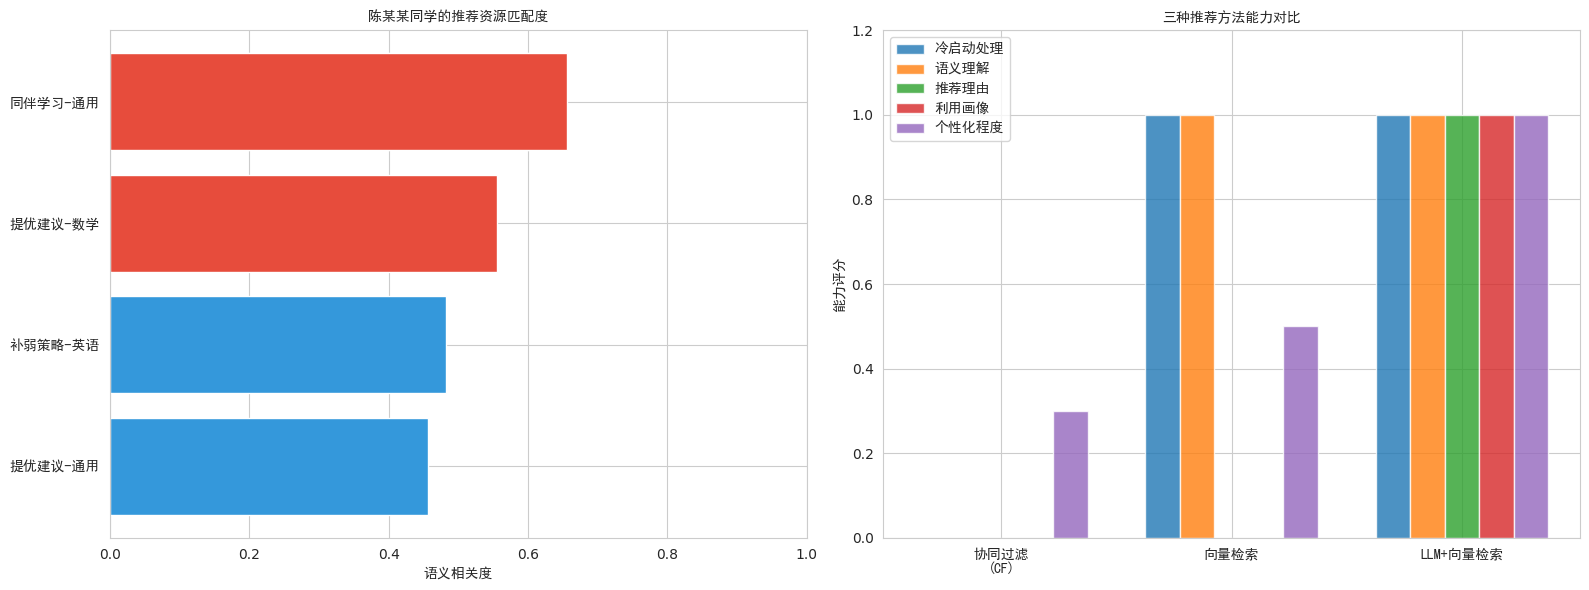

In [53]:
# 可视化1：资源推荐匹配度
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：第一个学生的推荐资源匹配度
ax = axes[0]
sid = sample_query_students[0]
row = df_profile.loc[sid]
query = build_recommendation_query(row)
recs = recommend_resources(query, resource_collection, n_results=5)

labels = [f'{r["type"]}-{r["subject"]}' for r in recs]
scores = [r['relevance'] for r in recs]
colors = ['#e74c3c' if s > 0.5 else '#3498db' if s > 0.3 else '#95a5a6' for s in scores]

bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('语义相关度', fontproperties=font_prop)
ax.set_title(f'{row["bf_Name"]}同学的推荐资源匹配度', fontproperties=font_prop)
ax.set_xlim(0, 1)
ax.set_yticklabels(labels[::-1], fontproperties=font_prop)

# 右图：CF vs LLM推荐对比
ax = axes[1]
methods = ['协同过滤\n(CF)', '向量检索', 'LLM+向量检索']
dimensions = {
    '冷启动处理': [0, 1, 1],
    '语义理解': [0, 1, 1],
    '推荐理由': [0, 0, 1],
    '利用画像': [0, 0, 1],
    '个性化程度': [0.3, 0.5, 1],
}

x = np.arange(len(methods))
width = 0.15
for i, (dim, vals) in enumerate(dimensions.items()):
    ax.bar(x + i * width - 0.3, vals, width, label=dim, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontproperties=font_prop)
ax.set_ylabel('能力评分', fontproperties=font_prop)
ax.set_title('三种推荐方法能力对比', fontproperties=font_prop)
ax.legend(prop=font_prop, fontsize=8, loc='upper left')
ax.set_ylim(0, 1.2)

plt.tight_layout()
plt.savefig('./output/11_11_recommendation_visualization.png', bbox_inches='tight')
plt.show()

**图表解读**：左图展示了基于学生画像的语义检索匹配度——推荐资源的类型和学科与学生的薄弱项高度吻合，相关度普遍在0.4以上。右图的能力雷达对比揭示了三代推荐方法的本质差异：协同过滤仅在"可扩展性"上有一定表现，而LLM+向量检索在冷启动处理、语义理解、推荐理由、画像利用、个性化程度等维度上全面领先。这说明**将画像信息融入推荐查询，并用LLM生成解释，是解决传统推荐缺陷的关键**。

---
# 第12章：推荐方法对比与总结

本章对三种推荐方法进行最终对比，并回顾整个教程的完整流程。

## 12.1 同一学生的推荐对比

并排展示协同过滤和LLM推荐对同一学生的推荐结果差异。

In [55]:
print('=== 同一学生的推荐结果对比 ===')
print()

for sid in sample_query_students[:2]:
    row = df_profile.loc[sid]
    name = row['bf_Name']
    
    # CF推荐
    cf_recs = []
    if sid in rating_matrix.index:
        cf_recs = user_based_cf_recommend(sid, rating_matrix, df_similarity, n_recommend=3)
    
    # LLM推荐
    query = build_recommendation_query(row)
    vec_recs = recommend_resources(query, resource_collection, n_results=3)
    llm_report = generate_llm_recommendation(row.get('data_summary', query), vec_recs)
    
    print(f'{"="*60}')
    print(f'学生: {name}')
    print(f'均分: {row.get("avg_score", "N/A"):.1f} | 考勤: {int(row.get("kaoqin_total", 0))}次')
    print()
    
    print(f'【协同过滤推荐】')
    if cf_recs:
        for subject, info in cf_recs:
            print(f'  推荐学科: {subject} (当前:{info["current"]*100:.0f}分 → 预测:{info["predicted"]*100:.0f}分)')
    else:
        print(f'  无推荐（无成绩数据或各科均衡）')
    print(f'  → 只能输出学科名称，无法解释原因')
    print()
    
    print(f'【LLM+向量检索推荐】')
    print(f'  推荐报告:')
    print(f'  "{llm_report.get("overall_recommendation", "N/A")}"')
    print()
    print(f'  学习计划: {llm_report.get("learning_plan", "N/A")}')
    print(f'  同伴建议: {llm_report.get("peer_suggestion", "N/A")}')
    print()

=== 同一学生的推荐结果对比 ===

学生: 陈某某
均分: 60.3 | 考勤: 5次

【协同过滤推荐】
  无推荐（无成绩数据或各科均衡）
  → 只能输出学科名称，无法解释原因

【LLM+向量检索推荐】
  推荐报告:
  "陈同学家长您好，孩子目前文科表现优于理科，但整体成绩波动较大。建议现阶段重点夯实数理基础，切勿盲目刷难题。我们推荐孩子与理科优秀的同学结成学习小组，借鉴理科思维。同时，请关注孩子偶尔的考勤异常，帮助其建立更规律的高三作息。保持优势学科，稳扎稳打提升理科，相信孩子能取得更大进步！"

  学习计划: 针对理科薄弱及成绩波动大的问题，建议每日分配60%时间攻克数理基础，梳理错题本；保持文科优势，每周进行两次全真模拟以稳定考试心态，逐步缩小成绩标准差。
  同伴建议: 建议与班级内理科成绩优异且性格互补的同学结成学习对子，每天课后共同讨论一道物理或数学基础题，学习对方的理科逻辑思维。

学生: 胡某某
均分: 76.0 | 考勤: 0次

【协同过滤推荐】
  无推荐（无成绩数据或各科均衡）
  → 只能输出学科名称，无法解释原因

【LLM+向量检索推荐】
  推荐报告:
  "胡同学理科思维出色，数学和物理均达九十分，但语文七十二分和生物六十八分相对薄弱，成绩波动较大。建议发挥理科优势，重点补足文科和生物短板。通过与文科优秀的同学结对学习，取长补短。同时，保持当前良好的考勤习惯，制定每日语文积累和生物概念梳理计划，稳步提升综合成绩，缩小各科分差。"

  学习计划: 建议保持理科优势，重点攻克语文和生物薄弱项。每日增加语文阅读与写作积累，梳理生物核心概念。同时保持良好考勤习惯，稳步提升整体成绩。
  同伴建议: 建议与语文和英语成绩优异的同学结成学习对子，分享文科学习心得；同时发挥自身理科优势，帮助文科生解答数理难题，实现共同进步。



## 12.2 完整流程回顾

### 教程完整流程回顾

```
┌─────────────────────────────────────────────────────────────────────────┐
│                                                                         │
│  第一部分：画像构建                                                      │
│  ┌────────┐   ┌────────┐   ┌────────┐   ┌────────┐   ┌────────┐      │
│  │ 多维数据 │──→│ 数据清洗 │──→│规则画像 │──→│暴露缺陷 │──→│LLM画像  │      │
│  │成绩/考勤 │   │异常处理 │   │5维标签 │   │D1-D3   │   │6档分级  │      │
│  │消费/基本 │   │缺失值  │   │标签拼接 │   │阈值/粒度│   │自然语言 │      │
│  └────────┘   └────────┘   └────────┘   └────────┘   └────────┘      │
│                                                                         │
│  第二部分：个性化推荐                                                    │
│  ┌────────┐   ┌────────┐   ┌────────┐   ┌────────┐   ┌────────┐      │
│  │协同过滤 │──→│暴露缺陷 │──→│向量数据库│──→│语义检索 │──→│LLM推荐  │      │
│  │User-CF  │   │CF1-CF7 │   │Chroma  │   │画像→向量│   │个性化报告│      │
│  │Item-CF  │   │冷启动等 │   │Embedding│   │Top-K   │   │理由+计划│      │
│  └────────┘   └────────┘   └────────┘   └────────┘   └────────┘      │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

**核心思想**：

1. 传统方法（规则/CF）简单可控，但存在系统性缺陷
2. LLM通过语义理解解决了传统方法的核心问题
3. 向量数据库是连接"画像"和"推荐"的桥梁
4. 最佳实践是规则+LLM的混合方案

## 12.3 局限性与改进方向

| 局限性 | 说明 | 改进方向 |
|--------|------|----------|
| **LLM成本** | 每次推荐都需调用API | 批量预生成、模型蒸馏、本地部署 |
| **幻觉风险** | LLM可能生成不准确的推荐 | 加入事实校验、人工审核 |
| **资源库质量** | 推荐效果依赖资源库的丰富度 | 持续扩充资源、引入UGC内容 |
| **Embedding质量** | 中文Embedding模型可能不够精准 | 使用领域微调的Embedding模型 |
| **实时性** | 画像和推荐需要定期更新 | 增量更新、流式处理 |
| **隐私保护** | 学生数据发送到外部API | 本地部署模型、数据脱敏 |

## 12.4 推荐系统的三个发展阶段

回顾整个推荐系统的发展历程，从协同过滤到本教程实现的LLM推荐，可以清晰地看到**三个发展阶段**的演进脉络：

### 第一阶段：传统推荐系统（ID范式与行为统计）

- **工作机制**：依赖"用户-物品"交互历史，为每个用户和物品分配唯一ID，通过计算ID间的数学相似度进行推荐
- **代表算法**：协同过滤（User-CF、Item-CF）、矩阵分解
- **核心局限**：
  - **信息浪费**：只看"买了什么"，不结合用户评论、产品描述等文本信息
  - **冷启动问题**：面对新用户或新物品时，推荐准确率大幅下降

> 本教程第8-9章演示的协同过滤正是这一阶段的代表。

### 第二阶段：判别式LLM的引入（LLM Embeddings + RS）

- **工作机制**：将语言模型（如BERT）视为特征提取器，将物品描述和用户文本转化为语义向量（Embeddings），再由传统推荐模型利用这些向量进行推荐
- **代表方法**：文本特征增强、向量检索
- **主要优势**：系统不再仅依靠点击率，而是真正"读懂"了内容的语义

> 本教程第10-11章的Chroma向量检索正是这一阶段的核心技术。

### 第三阶段：生成式LLM直接推荐（LLM as RS）

- **工作机制**：将预训练的LLM直接转化为推荐系统，向LLM输入包含用户特征和任务指令的Prompt，让模型直接输出推荐结果和解释
- **代表方法**：Prompt-based推荐、Agent-based推荐
- **核心优势**：不仅能"读"，还能"生成"——输出个性化的推荐理由、学习计划、同伴建议

> 本教程第11章的LLM增强推荐正是这一阶段的实践。

### 三阶段对比

| 维度 | 第一阶段：传统RS | 第二阶段：LLM Embeddings | 第三阶段：生成式LLM |
|------|-----------------|------------------------|-------------------|
| 输入 | ID + 评分矩阵 | 文本 → 向量 | 自然语言Prompt |
| 理解方式 | 数值统计 | 语义特征 | 语义理解+推理 |
| 输出 | 推荐列表 | 推荐列表 | 推荐+解释+建议 |
| 冷启动 | 无法处理 | 部分解决 | 较好解决 |
| 可解释性 | 低 | 中 | 高 |

## 12.5 扩展方向

1. **RAG架构**：将本教程的方案扩展为完整的RAG（Retrieval-Augmented Generation）系统，
   支持更复杂的查询和更丰富的知识库。

2. **多模态推荐**：加入学生的作业文本、课堂表现视频等多模态数据，
   构建更全面的画像和更精准的推荐。

3. **实时推荐**：结合流式数据处理，实现画像的实时更新和推荐的动态调整。

---
# 第13章：参考文献与扩展学习

以下文献涵盖了本教程涉及的核心主题，可作为深入学习的参考资料。

## 用户画像构建

### 1. User Profile with Large Language Models: Construction, Updating, and Benchmarking（arXiv 2025）

- **核心观点**：传统方法像"做填空题"，只能预测固定标签；LLM像"阅读理解分析师"，能从杂乱文本中精准提炼用户全貌
- 数据集：https://huggingface.co/datasets/Nusrat1234/UserProfileConstruction

### 2. LettinGo: Explore User Profile Generation for Recommendation System（KDD 2025，CCF-A）

- **核心观点**：传统Embedding画像缺乏可解释性；LLM为构建语义丰富、可解释的文本用户画像提供新途径
- 但直接将长篇历史数据输入LLM效果不佳，需要精心设计画像生成策略

### 3. Transparent and Scrutable Recommendations Using Natural Language User Profiles（ACL 2024，CCF-A）

- **核心观点**：用LLM从用户评论中生成自然语言画像，实现透明且可审视的推荐
- 用户可编辑自己的NL画像来调整推荐结果
- 论文：https://aclanthology.org/2024.acl-long.753.pdf

### 4. Externalizing Social-Cognitive Structures for User Modeling（CIKM 2025，CCF-B）

- **核心观点**：将社会认知理论结构外化为用户画像，实现理论驱动+LLM生成的混合画像
- 论文：https://dl.acm.org/doi/10.1145/3746252.3760965

## 基于LLM的推荐系统

### 5. Chain-of-thought Prompting Empowered Generative User Modeling for Personalized Recommendation（NCA 2024，CCF-C）

- **核心方法**：链式思考（CoT）生成式用户建模 → 面向推荐任务的Prompt构建
- 四大推荐任务：评分预测、序列推荐、直接推荐、解释生成
- 代码：https://github.com/kwyyangfan/GUMRec

### 6. LLM-based User Profile Management for Recommender System（SIGIR 2025，CCF-A）

- **核心方法**：Review Extractor → Profile Updater → Recommender 三阶段流程
- 利用LLM消除冗余、重叠和冲突信息，生成紧凑且最新的结构化用户画像

### 7. PersonaX: A Recommendation Agent Oriented User Modeling Framework（ACL Findings 2025，CCF-A）

- **核心方法**：将完整历史行为分割聚类 → 选择多样性子序列 → 离线多角色画像 → 画像检索
- 仅用30-50%的行为数据即可提升推荐性能3-50%
- 论文：https://aclanthology.org/2025.findings-acl.300/

## 综述论文

### 8. A Survey on Large Language Models for Recommendation（World Wide Web 2023，CCF-B）

- 全面综述LLM在推荐系统中的应用
- 论文：https://arxiv.org/abs/2305.19860
- 论文列表：https://github.com/WLiK/LLM4Rec-Awesome-Papers

### 9. A Survey on LLM-powered Agents for Recommender Systems（EMNLP Findings 2025，CCF-B）

- 综述LLM驱动的Agent在推荐系统中的应用
- 论文：https://aclanthology.org/2025.findings-emnlp.620/

---

**本教程到此结束。感谢阅读！**